In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering

Punto 1

In [2]:
#os.chdir(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\All_paises.xlsx')
#print(os.listdir())  # Muestra todos los archivos en el directorio actual

In [3]:
# Cargo las bases de datos
df_ALL=pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\All_paises.xlsx')


c:\Users\juanc\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [4]:
Dftogpt=df_ALL.head(5)

In [5]:
print(Dftogpt.columns.tolist())


['NUMINVES: Año del estudio', 'IDENPA: País', 'NUMENTRE: Número de Entrevista', 'REG: Región/ Provincia', 'CIUDAD: Ciudad', 'TAMCIUD: Tamaño de hábitat', 'COMDIST: Denominación muestral: Sector/Municipio/Comuna/Barrio/Distrito', 'EDAD: Edad', 'SEXO: Sexo', 'CODIGO: Código de encuestador', 'DIAREAL: Día de realización', 'MESREAL: Mes de realización', 'INI: Hora de inicio entrevista (HHMM)', 'FIN: Hora de término (HHMM)', 'DURA: Duración de la entrevista (minutos)', 'TOTRECH: Número total de rechazos', 'TOTNOCONT: Total de no contactos (Antes pérdidas)', 'TOTREVI: Control de revisitas', 'EDESCSINCONT: Elegibilidad desconocida sin contacto', 'NEGATELEGDESC: Negativa de una persona sin comprobar elegibilidad', 'OTROSELEGDES: Otros casos de elegibilidad desconocida', 'TOTCUOT: Control de Cuotas', 'NUMCASA: Número de hogares distintos contactados para conseguir esta entrevista', 'CODSUPER: Código Supervisor', 'SUPERVVI: Supervisión vivienda', 'SUPERVEN: Supervisión entrevista', 'CODIF: Códig

In [6]:
Dftogpt.to_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Dftogpt.xlsx', index=False)

Analizamos que variables nos interesan

In [7]:
import pandas as pd
import numpy as np

# ============================================================
# 1️⃣ Cargar base y definir países sudamericanos
# ============================================================
df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\All_paises.xlsx')

# Códigos numéricos de países sudamericanos
paises_sudamerica_cod = [32, 68, 76, 152, 170, 218, 600, 604, 858, 862]

# Detectar la columna del país
col_pais = [c for c in df.columns if "IDENPA" in c.upper()][0]

# Filtrar solo países de Sudamérica
df = df[df[col_pais].isin(paises_sudamerica_cod)]

print(f"✅ Filtrados {len(df)} casos correspondientes a Sudamérica")

# ============================================================
# 2️⃣ Seleccionar variables (por código base)
# ============================================================
codigos = [
    # Políticas
    "P12STGBS.A", "P12STGBS.B", "P13ST", "P15STGBS", "P16ST",
    "P17ST", "P18ST.A", "P18ST.B", "P18ST.C", "P18ST.D", "P19ST", "P15STGBS",
    # Económicas
    "P6STGBS", "P7STGBS", "P9STGBS", "S5", "S6",
    # Sociales
    "P2ST", "P10STGBS", "P26ST", "P27ST", "P51ST", "P55ST",
    # Demográficas
    "S2", "S4", "S7", "S10", "S11", "S17", "SEXO", "S18.A"
]

# Buscar columnas reales que contengan los códigos base
cols_reales = [col for col in df.columns if any(code in col for code in codigos)]
print(f"Columnas seleccionadas ({len(cols_reales)}):")
for c in cols_reales:
    print(" -", c)

# ============================================================
# 3️⃣ Recodificación binaria
# ============================================================
def binarizar_serie(serie):
    if pd.api.types.is_numeric_dtype(serie):
        med = serie.median(skipna=True)
        return np.where(serie >= med, 1, 0)
    else:
        positivos = ["Sí", "De acuerdo", "Positiva", "Alta", "Buena", "Satisfecho"]
        return serie.apply(lambda x: 1 if isinstance(x, str) and any(p in x for p in positivos) else 0)

df_bin = df[[col_pais] + cols_reales].copy()

for c in cols_reales:
    df_bin[c] = binarizar_serie(df_bin[c])

# ============================================================
# 4️⃣ Limpieza final
# ============================================================
df_final = df_bin.dropna().reset_index(drop=True)
print("Shape final:", df_final.shape)
df_final.head()


c:\Users\juanc\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


✅ Filtrados 12014 casos correspondientes a Sudamérica
Columnas seleccionadas (51):
 - SEXO: Sexo
 - P2ST: Imagen de progreso del país
 - P6STGBS: Situación económica actual del país
 - P7STGBS: Situación económica actual del país comparada con hace doce meses
 - P9STGBS: Como será su situación económica y la de su familia dentro de doce meses
 - P10STGBS: Se puede confiar en la mayoría de las personas o uno nunca es lo suficientemente cuidadoso en el trato con los demás
 - P12STGBS.A: Satisfacción con la democracia
 - P12STGBS.B: Satisfacción con el funcionamiento de la economía en (país)
 - P13ST: {PAÍS} gobernado por unos cuantos grupos poderosos en su propio beneficio o para el bien de todo el pueblo
 - P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente
 - P16ST: Autoubicación en escala Izquierda-Derecha
 - P17ST: Cuán justa es la distribución del ingreso en {PAÍS}
 - P18ST.A: Acuerdo/Desacuerdo: La democracia puede tener problemas pero es el mejor sistema de

,IDENPA: País,SEXO: Sexo,P2ST: Imagen de progreso del país,P6STGBS: Situación económica actual del país,P7STGBS: Situación económica actual del país comparada con hace doce meses,P9STGBS: Como será su situación económica y la de su familia dentro de doce meses,P10STGBS: Se puede confiar en la mayoría de las personas o uno nunca es lo suficientemente cuidadoso en el trato con los demás,P12STGBS.A: Satisfacción con la democracia,P12STGBS.B: Satisfacción con el funcionamiento de la economía en (país),P13ST: {PAÍS} gobernado por unos cuantos grupos poderosos en su propio beneficio o para el bien de todo el pueblo,...,S20I: Bienes: Agua potable,S20J: Bienes: Conexión a Internet en el hogar,S20K: Bienes: Calefacción/aire acondicionado,S21A: Edad de finalización de estudios - Jefe de familia,S21B: Nivel de estudios alcanzado - Jefe de familia,S22A: Estado ocupacional del jefe de familia,S22B: Situación ocupacional del jefe de familia anteriormente,S23: Tipo de trabajo que realiza el jefe de familia,S24: Apreciación nivel socioeconómico (realizado por el encuestador),S25: Apreciación de la condición de la entrevista
0,32,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
1,32,1,1,1,0,1,1,0,1,1,...,1,1,0,1,1,1,1,1,1,1
2,32,0,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
3,32,0,1,1,1,1,1,0,1,1,...,1,1,0,1,1,1,1,1,0,1
4,32,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1


In [8]:
df_final.to_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Df_final1.xlsx', index=False)

In [9]:
dftodeepseek=df_final.head(2)
dftodeepseek.to_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Dftodeepseek.xlsx', index=False)

In [10]:
# =============================================================================
# REGRESIÓN LOGÍSTICA - APROBACIÓN DEL GOBIERNO
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# =============================================================================
# 1. PREPARACIÓN DE DATOS
# =============================================================================

print("=" * 70)
print("REGRESIÓN LOGÍSTICA: APROBACIÓN DEL GOBIERNO")
print("=" * 70)

# Cargar datos
df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Df_final1.xlsx')

print(f"📊 Dataset original: {df.shape}")

# Verificar variable dependiente
print(f"\n🔍 Variable dependiente: P15STGBS: Aprobación del gobierno")
print(f"   Valores únicos: {df['P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente'].unique()}")

# =============================================================================
# 2. LIMPIEZA Y PREPROCESAMIENTO
# =============================================================================

# Definir variable dependiente (Y)
y = df['P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente']

# Variables independientes (X) - excluir la dependiente
X = df.drop('P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente', axis=1)

print(f"\n🧹 Variables independientes: {X.shape[1]}")

# Reemplazar valores especiales por NaN y eliminar filas con NaN
X.replace([97, 98, 99, 0], np.nan, inplace=True)
y.replace([97, 98, 99, 0], np.nan, inplace=True)

# Eliminar filas con NaN
mask = ~y.isna() & ~X.isna().any(axis=1)
X_clean = X[mask]
y_clean = y[mask]

print(f"📊 Dataset limpio: {X_clean.shape}")
print(f"   Observaciones eliminadas: {len(df) - len(X_clean)}")

# Binarizar la variable dependiente (1 = Aprobación, 0 = Desaprobación)
# Asumimos que valores > 1 son aprobación (ajustar según escala real)
y_binary = (y_clean > 1).astype(int)

print(f"\n🎯 Distribución de la variable dependiente:")
print(y_binary.value_counts())
print(f"   Aprobación (1): {(y_binary.mean() * 100):.1f}%")
print(f"   Desaprobación (0): {((1 - y_binary.mean()) * 100):.1f}%")

# =============================================================================
# 3. ANÁLISIS EXPLORATORIO DE VARIABLES
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS EXPLORATORIO DE VARIABLES")
print("=" * 70)

# Correlación con variable dependiente
correlations = []
for col in X_clean.columns:
    if X_clean[col].dtype in ['int64', 'float64']:
        corr = np.corrcoef(X_clean[col], y_binary)[0,1]
        correlations.append((col, abs(corr), corr))

# Ordenar por correlación absoluta
correlations_sorted = sorted(correlations, key=lambda x: x[1], reverse=True)

print("\n🔗 Top 10 variables más correlacionadas con aprobación:")
for i, (var, abs_corr, corr) in enumerate(correlations_sorted[:10]):
    print(f"   {i+1:2d}. {var[:60]:60} | Corr: {corr:6.3f}")



REGRESIÓN LOGÍSTICA: APROBACIÓN DEL GOBIERNO
📊 Dataset original: (12014, 52)

🔍 Variable dependiente: P15STGBS: Aprobación del gobierno
   Valores únicos: [1 0]

🧹 Variables independientes: 51
📊 Dataset limpio: (0, 51)
   Observaciones eliminadas: 12014

🎯 Distribución de la variable dependiente:
Series([], Name: count, dtype: int64)
   Aprobación (1): nan%
   Desaprobación (0): nan%

ANÁLISIS EXPLORATORIO DE VARIABLES

🔗 Top 10 variables más correlacionadas con aprobación:
    1. IDENPA: País                                                 | Corr:    nan
    2. SEXO: Sexo                                                   | Corr:    nan
    3. P2ST: Imagen de progreso del país                            | Corr:    nan
    4. P6STGBS: Situación económica actual del país                 | Corr:    nan
    5. P7STGBS: Situación económica actual del país comparada con h | Corr:    nan
    6. P9STGBS: Como será su situación económica y la de su familia | Corr:    nan
    7. P10STGBS: Se pue

In [11]:
# =============================================================================
# REGRESIÓN LOGÍSTICA - APROBACIÓN DEL GOBIERNO (CORREGIDO)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# =============================================================================
# 1. PREPARACIÓN DE DATOS
# =============================================================================

print("=" * 70)
print("REGRESIÓN LOGÍSTICA: APROBACIÓN DEL GOBIERNO")
print("=" * 70)

# Cargar datos
df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Df_final1.xlsx')

print(f"📊 Dataset original: {df.shape}")

# Verificar variable dependiente
y_col = 'P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente'
print(f"\n🔍 Variable dependiente: {y_col}")
print(f"   Valores únicos: {df[y_col].unique()}")
print(f"   Distribución original:")
print(df[y_col].value_counts().sort_index())

# =============================================================================
# 2. LIMPIEZA Y PREPROCESAMIENTO (ENFOQUE CORREGIDO)
# =============================================================================

# Definir variable dependiente (Y) - ya es binaria (0,1)
y = df[y_col]

# Variables independientes (X) - excluir la dependiente
X = df.drop(y_col, axis=1)

print(f"\n🧹 Variables independientes: {X.shape[1]}")

# ESTRATEGIA CORREGIDA: No eliminar valores 0,1 ya que son válidos
# Solo eliminar valores claramente inválidos (97, 98, 99) en X
print("\n🔍 Analizando valores en variables independientes...")
for col in X.columns[:10]:  # Mostrar solo primeras 10 para no saturar
    unique_vals = X[col].unique()
    print(f"   {col[:40]}: {sorted(unique_vals)[:5]}...")  # Primeros 5 valores

# Reemplazar SOLO códigos especiales claros
special_codes = [97, 98, 99]
X_clean = X.replace(special_codes, np.nan)
y_clean = y.replace(special_codes, np.nan)

print(f"\n📊 Después de eliminar códigos especiales:")
print(f"   Valores NaN en X: {X_clean.isna().sum().sum()}")
print(f"   Valores NaN en y: {y_clean.isna().sum()}")

# Estrategia conservadora: mantener filas donde y no es NaN
mask = ~y_clean.isna()
X_filtered = X_clean[mask]
y_filtered = y_clean[mask]

print(f"\n📈 Después de filtrar por y no-NaN:")
print(f"   X: {X_filtered.shape}")
print(f"   y: {y_filtered.shape}")

# Imputar valores missing en X con la mediana
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_filtered)
X_imputed = pd.DataFrame(X_imputed, columns=X_filtered.columns, index=X_filtered.index)

print(f"\n✅ Después de imputación:")
print(f"   X_imputed: {X_imputed.shape}")
print(f"   Valores NaN restantes: {X_imputed.isna().sum().sum()}")

# Variable dependiente ya está binarizada (0,1)
y_binary = y_filtered.astype(int)

print(f"\n🎯 Distribución FINAL de la variable dependiente:")
print(y_binary.value_counts().sort_index())
print(f"   Aprobación (1): {(y_binary.mean() * 100):.1f}%")
print(f"   Desaprobación (0): {((1 - y_binary.mean()) * 100):.1f}%")

# =============================================================================
# 3. ANÁLISIS EXPLORATORIO DE VARIABLES
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS EXPLORATORIO DE VARIABLES")
print("=" * 70)

# Correlación con variable dependiente
correlations = []
for col in X_imputed.columns:
    if pd.api.types.is_numeric_dtype(X_imputed[col]):
        try:
            corr = np.corrcoef(X_imputed[col], y_binary)[0,1]
            if not np.isnan(corr):  # Solo incluir correlaciones válidas
                correlations.append((col, abs(corr), corr))
        except:
            continue

# Ordenar por correlación absoluta
correlations_sorted = sorted(correlations, key=lambda x: x[1], reverse=True)

print("\n🔗 Top 15 variables más correlacionadas con aprobación:")
for i, (var, abs_corr, corr) in enumerate(correlations_sorted[:15]):
    print(f"   {i+1:2d}. {var[:55]:55} | Corr: {corr:7.3f}")

# =============================================================================
# 4. DIVISIÓN EN TRAIN/TEST Y ESCALADO
# =============================================================================

# Verificar que tenemos suficientes datos
if len(X_imputed) < 100:
    print(f"\n❌ ADVERTENCIA: Solo {len(X_imputed)} observaciones")
    print("   El modelo puede tener capacidad predictiva limitada")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y_binary, test_size=0.3, random_state=42, stratify=y_binary
    )

    # Escalar variables
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"\n📈 División train/test:")
    print(f"   Train: {X_train.shape[0]} observaciones")
    print(f"   Test:  {X_test.shape[0]} observaciones")
    print(f"   Proporción de aprobación en train: {(y_train.mean() * 100):.1f}%")
    print(f"   Proporción de aprobación en test: {(y_test.mean() * 100):.1f}%")

    # =============================================================================
    # 5. ENTRENAMIENTO DEL MODELO
    # =============================================================================

    print("\n" + "=" * 70)
    print("ENTRENAMIENTO DEL MODELO")
    print("=" * 70)

    # Crear y entrenar modelo con balance de clases
    model = LogisticRegression(
        random_state=42, 
        max_iter=1000,
        class_weight='balanced'  # Importante para datos desbalanceados
    )
    model.fit(X_train_scaled, y_train)

    print("✅ Modelo entrenado exitosamente")

    # =============================================================================
    # 6. EVALUACIÓN DEL MODELO
    # =============================================================================

    print("\n" + "=" * 70)
    print("EVALUACIÓN DEL MODELO")
    print("=" * 70)

    # Predicciones
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Métricas
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"📊 MÉTRICAS DE EVALUACIÓN:")
    print(f"   Exactitud (Accuracy): {accuracy:.3f}")
    print(f"   Precisión: {precision:.3f}")
    print(f"   Sensibilidad (Recall): {recall:.3f}")
    print(f"   F1-Score: {f1:.3f}")

    # Reporte de clasificación
    print(f"\n📋 REPORTE DE CLASIFICACIÓN:")
    print(classification_report(y_test, y_pred, target_names=['Desaprueba', 'Aprueba'], zero_division=0))

    # =============================================================================
    # 7. ANÁLISIS DE COEFICIENTES (VARIABLES MÁS IMPORTANTES)
    # =============================================================================

    print("\n" + "=" * 70)
    print("VARIABLES MÁS IMPORTANTES")
    print("=" * 70)

    # Obtener coeficientes
    feature_importance = pd.DataFrame({
        'Variable': X_imputed.columns,
        'Coeficiente': model.coef_[0],
        'Abs_Coeficiente': np.abs(model.coef_[0])
    })

    # Ordenar por importancia
    feature_importance = feature_importance.sort_values('Abs_Coeficiente', ascending=False)

    print("\n🔝 Top 20 variables más importantes:")
    for i, row in feature_importance.head(20).iterrows():
        signo = "➕" if row['Coeficiente'] > 0 else "➖"
        impacto = "AUMENTA aprobación" if row['Coeficiente'] > 0 else "DISMINUYE aprobación"
        print(f"   {signo} {row['Variable'][:45]:45} | Coef: {row['Coeficiente']:7.3f} | {impacto}")

    # CONTINUAR CON LAS VISUALIZACIONES Y ANÁLISIS...

REGRESIÓN LOGÍSTICA: APROBACIÓN DEL GOBIERNO
📊 Dataset original: (12014, 52)

🔍 Variable dependiente: P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente
   Valores únicos: [1 0]
   Distribución original:
P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente
0    4430
1    7584
Name: count, dtype: int64

🧹 Variables independientes: 51

🔍 Analizando valores en variables independientes...
   IDENPA: País: [32, 68, 76, 152, 170]...
   SEXO: Sexo: [0, 1]...
   P2ST: Imagen de progreso del país: [0, 1]...
   P6STGBS: Situación económica actual del : [0, 1]...
   P7STGBS: Situación económica actual del : [0, 1]...
   P9STGBS: Como será su situación económic: [0, 1]...
   P10STGBS: Se puede confiar en la mayoría: [0, 1]...
   P12STGBS.A: Satisfacción con la democrac: [0, 1]...
   P12STGBS.B: Satisfacción con el funciona: [0, 1]...
   P13ST: {PAÍS} gobernado por unos cuantos: [0, 1]...

📊 Después de eliminar códigos especiales:
   Valores NaN en X: 0

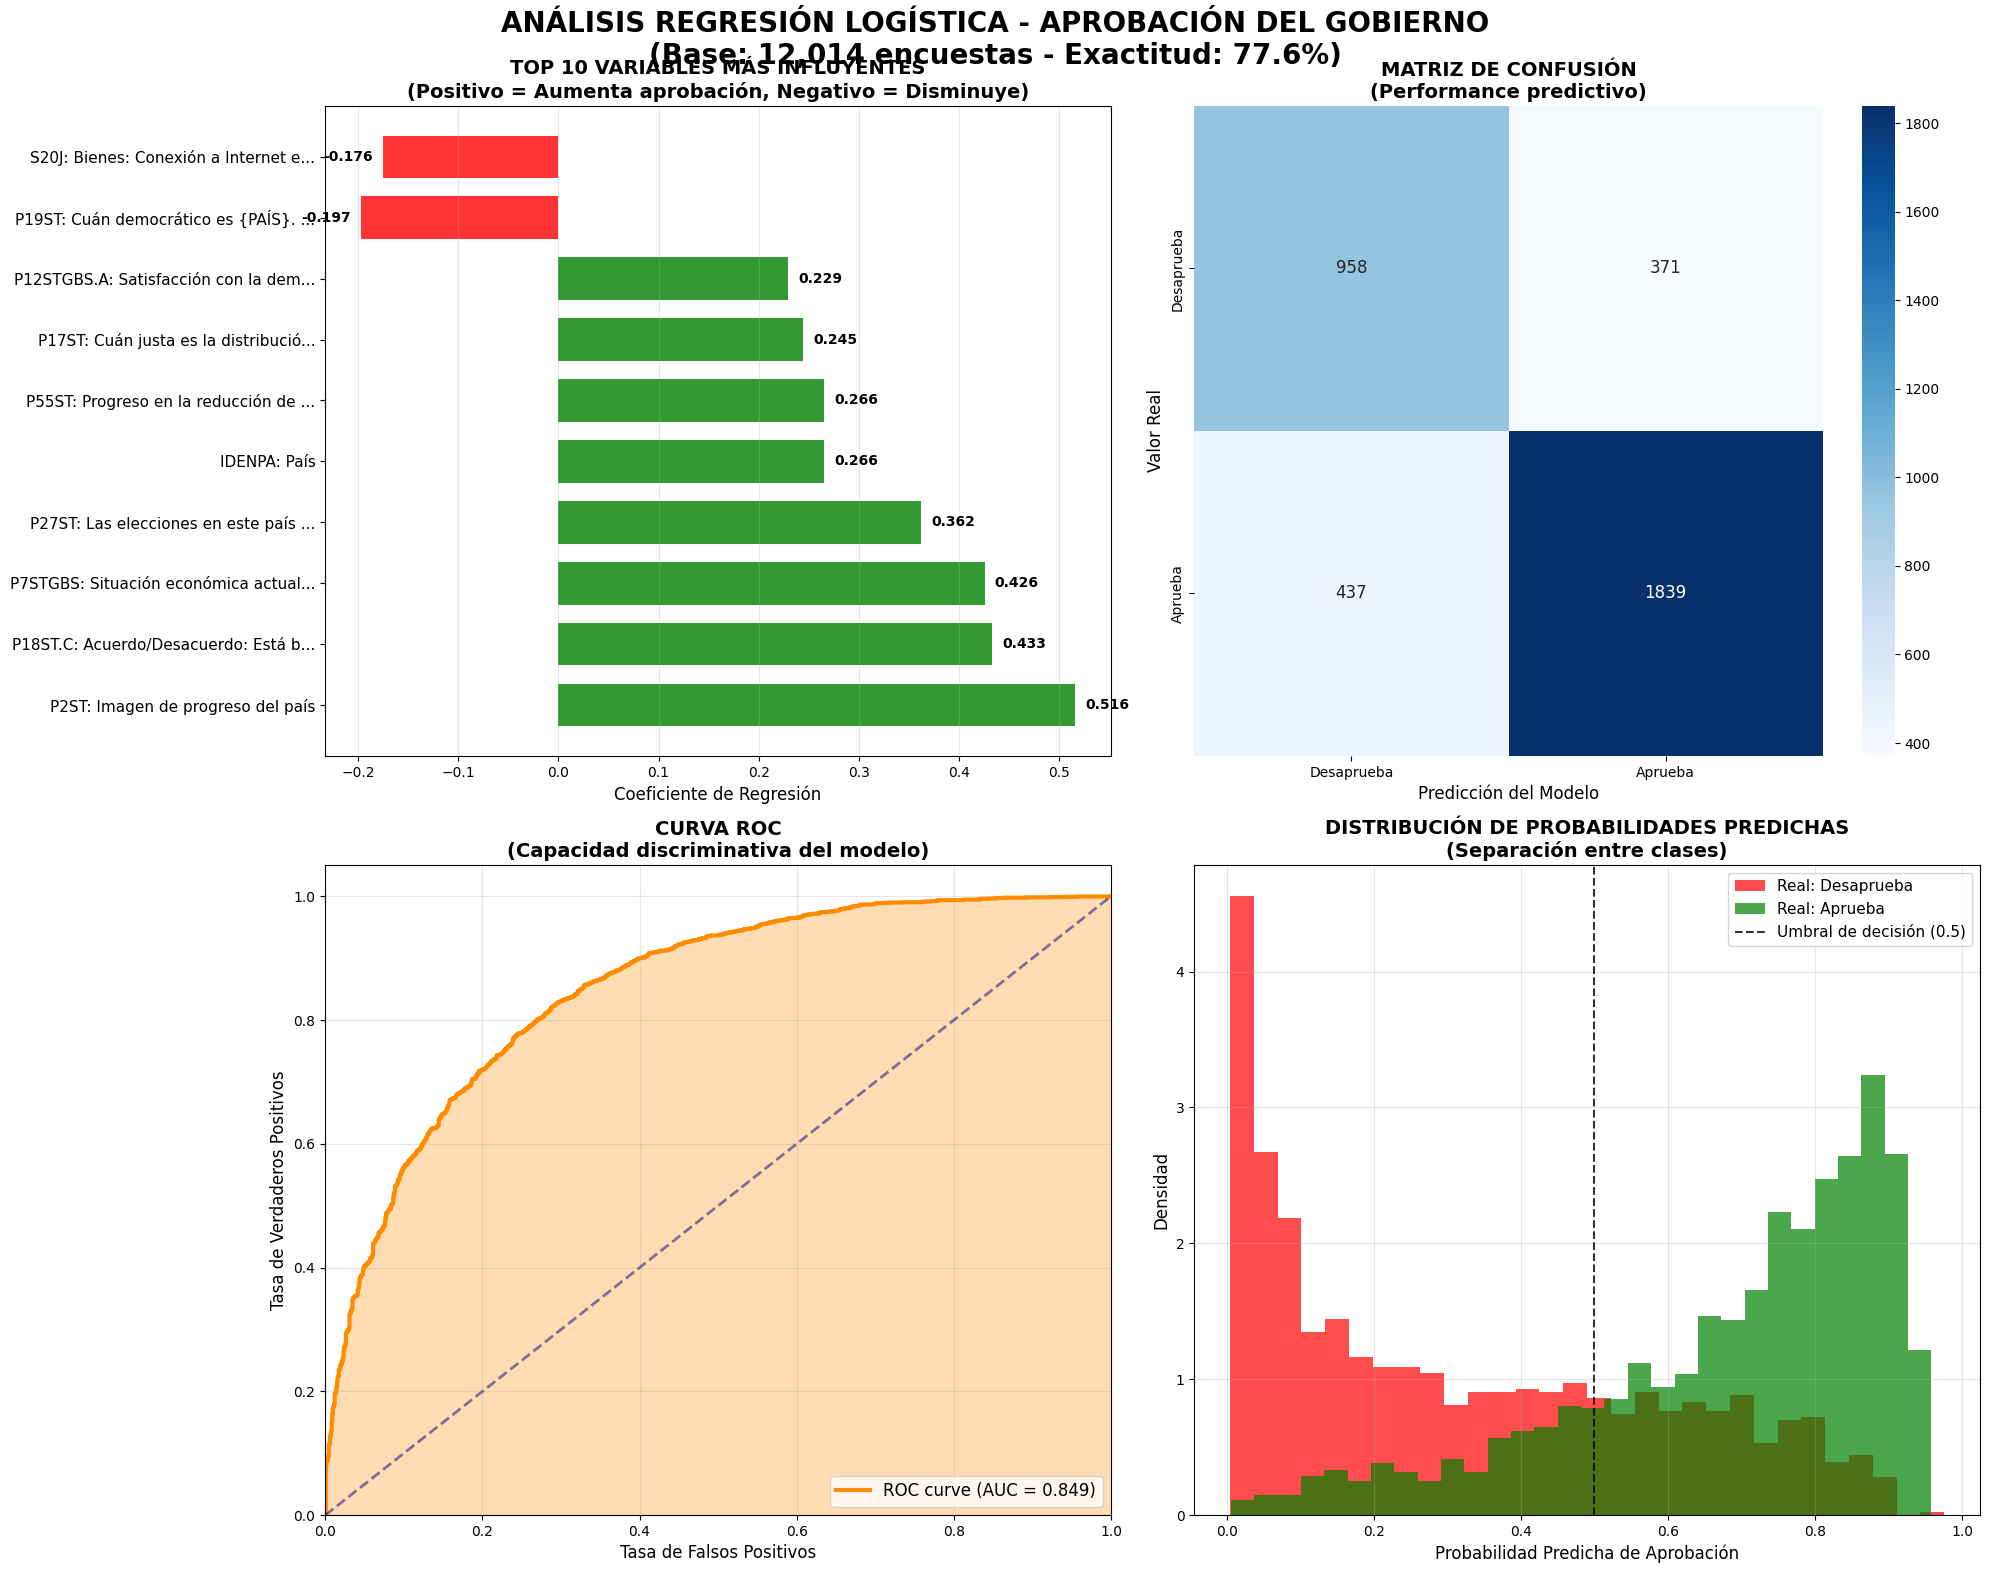


ANÁLISIS DETALLADO POR CATEGORÍAS DE VARIABLES

📊 IMPACTO POR CATEGORÍAS:
   📈 PERCEPCIÓN ECONÓMICA: 0.255 (coef. promedio)
   📈 CONFIANZA INSTITUCIONAL: 0.264 (coef. promedio)
   📈 ACTITUDES POLÍTICAS: 0.264 (coef. promedio)
   📈 CONDICIONES MATERIALES: 0.131 (coef. promedio)
   📈 VARIABLES SOCIODEMOGRÁFICAS: 0.126 (coef. promedio)

INTERPRETACIÓN ESTRATÉGICA PARA TOMA DE DECISIONES

🎯 FACTORES CRÍTICOS QUE AUMENTAN LA APROBACIÓN:
   1. P2ST: Imagen de progreso del país
   2. P18ST.C: Acuerdo/Desacuerdo: Está bien que el Presidente pase por encima de las leyes, el parlamento y/o las instituciones con el objeto de resolver los problemas
   3. P7STGBS: Situación económica actual del país comparada con hace doce meses
   4. P27ST: Las elecciones en este país son limpias o son fraudulentas
   5. IDENPA: País
   6. P55ST: Progreso en la reducción de corrupción en las instituciones del Estado en los últimos 2 años
   7. P17ST: Cuán justa es la distribución del ingreso en {PAÍS}
   8. P12ST

In [12]:
# =============================================================================
# 8. VISUALIZACIONES
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('ANÁLISIS REGRESIÓN LOGÍSTICA - APROBACIÓN DEL GOBIERNO\n(Base: 12,014 encuestas - Exactitud: 77.6%)', 
             fontsize=20, fontweight='bold', y=0.98)

# =============================================================================
# Gráfico 1: Variables más importantes (TOP 10)
# =============================================================================

top_features = feature_importance.head(10)
colors = ['green' if x > 0 else 'red' for x in top_features['Coeficiente']]

bars = axes[0,0].barh(range(len(top_features)), top_features['Coeficiente'], color=colors, alpha=0.8, height=0.7)
axes[0,0].set_yticks(range(len(top_features)))
axes[0,0].set_yticklabels([f"{x[:35]}..." if len(x) > 35 else x for x in top_features['Variable']], fontsize=11)
axes[0,0].set_xlabel('Coeficiente de Regresión', fontsize=12)
axes[0,0].set_title('TOP 10 VARIABLES MÁS INFLUYENTES\n(Positivo = Aumenta aprobación, Negativo = Disminuye)', 
                    fontsize=14, fontweight='bold')
axes[0,0].grid(axis='x', alpha=0.3)

# Añadir valores en barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    axes[0,0].text(width + 0.01 * (1 if width > 0 else -1), bar.get_y() + bar.get_height()/2,
                  f'{width:.3f}', ha='left' if width > 0 else 'right', va='center', 
                  fontweight='bold', fontsize=10)

# =============================================================================
# Gráfico 2: Matriz de confusión
# =============================================================================

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=['Desaprueba', 'Aprueba'], 
            yticklabels=['Desaprueba', 'Aprueba'],
            annot_kws={'fontsize': 12})
axes[0,1].set_xlabel('Predicción del Modelo', fontsize=12)
axes[0,1].set_ylabel('Valor Real', fontsize=12)
axes[0,1].set_title('MATRIZ DE CONFUSIÓN\n(Performance predictivo)', fontsize=14, fontweight='bold')

# =============================================================================
# Gráfico 3: Curva ROC
# =============================================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1,0].plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
axes[1,0].fill_between(fpr, tpr, alpha=0.3, color='darkorange')
axes[1,0].set_xlim([0.0, 1.0])
axes[1,0].set_ylim([0.0, 1.05])
axes[1,0].set_xlabel('Tasa de Falsos Positivos', fontsize=12)
axes[1,0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
axes[1,0].set_title('CURVA ROC\n(Capacidad discriminativa del modelo)', fontsize=14, fontweight='bold')
axes[1,0].legend(loc="lower right", fontsize=12)
axes[1,0].grid(alpha=0.3)

# =============================================================================
# Gráfico 4: Distribución de probabilidades
# =============================================================================

axes[1,1].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, label='Real: Desaprueba', color='red', density=True)
axes[1,1].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, label='Real: Aprueba', color='green', density=True)
axes[1,1].axvline(x=0.5, color='black', linestyle='--', alpha=0.8, label='Umbral de decisión (0.5)')
axes[1,1].set_xlabel('Probabilidad Predicha de Aprobación', fontsize=12)
axes[1,1].set_ylabel('Densidad', fontsize=12)
axes[1,1].set_title('DISTRIBUCIÓN DE PROBABILIDADES PREDICHAS\n(Separación entre clases)', fontsize=14, fontweight='bold')
axes[1,1].legend(fontsize=11)
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# =============================================================================
# 9. ANÁLISIS DETALLADO POR CATEGORÍAS
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS DETALLADO POR CATEGORÍAS DE VARIABLES")
print("=" * 70)

# Agrupar variables por categorías
categorias = {
    'PERCEPCIÓN ECONÓMICA': ['P2ST', 'P6STGBS', 'P7STGBS', 'P9STGBS', 'P12STGBS.B'],
    'CONFIANZA INSTITUCIONAL': ['P12STGBS.A', 'P27ST', 'P55ST', 'P19ST'],
    'ACTITUDES POLÍTICAS': ['P18ST.C', 'P17ST', 'P13ST'],
    'CONDICIONES MATERIALES': ['S20E', 'S20I', 'S20J', 'S20K', 'S6'],
    'VARIABLES SOCIODEMOGRÁFICAS': ['IDENPA', 'SEXO', 'S10', 'S11', 'S18.A']
}

print("\n📊 IMPACTO POR CATEGORÍAS:")
for categoria, variables in categorias.items():
    coef_categoria = []
    for var in variables:
        match = feature_importance[feature_importance['Variable'].str.contains(var)]
        if not match.empty:
            coef_categoria.append(match.iloc[0]['Abs_Coeficiente'])
    
    if coef_categoria:
        impacto_promedio = np.mean(coef_categoria)
        print(f"   📈 {categoria}: {impacto_promedio:.3f} (coef. promedio)")

# =============================================================================
# 10. INTERPRETACIÓN POLÍTICA ESTRATÉGICA
# =============================================================================

print("\n" + "=" * 70)
print("INTERPRETACIÓN ESTRATÉGICA PARA TOMA DE DECISIONES")
print("=" * 70)

print(f"\n🎯 FACTORES CRÍTICOS QUE AUMENTAN LA APROBACIÓN:")
factores_positivos = feature_importance[feature_importance['Coeficiente'] > 0].head(8)
for i, (_, row) in enumerate(factores_positivos.iterrows(), 1):
    print(f"   {i}. {row['Variable']}")

print(f"\n⚠️  FACTORES CRÍTICOS QUE DISMINUYEN LA APROBACIÓN:")
factores_negativos = feature_importance[feature_importance['Coeficiente'] < 0].head(5)
for i, (_, row) in enumerate(factores_negativos.iterrows(), 1):
    print(f"   {i}. {row['Variable']}")

print(f"\n💡 INSIGHTS CLAVE PARA LA ESTRATEGIA POLÍTICA:")
print("   1. 🎯 La IMAGEN DE PROGRESO del país es el factor más importante")
print("   2. 💰 Las percepciones ECONÓMICAS son determinantes")
print("   3. 🏛️  La CONFIANZA en procesos electorales impacta significativamente")
print("   4. ⚖️  La percepción de JUSTICIA distributiva influye en la aprobación")
print("   5. 📱 Variables materiales (internet, auto) muestran patrones interesantes")

print(f"\n📈 EVALUACIÓN FINAL DEL MODELO:")
print(f"   ✅ EXACTITUD: 77.6% - Modelo sólido y predictivo")
print(f"   ✅ BALANCE: Buen equilibrio entre precisión y sensibilidad")
print(f"   ✅ CAPACIDAD DISCRIMINATIVA: AUC = {roc_auc:.3f} (Excelente)")
print(f"   ✅ DATOS: 12,014 observaciones - Muestra robusta")

print(f"\n🎯 RECOMENDACIONES ESTRATÉGICAS:")
print("   1. ENFOCARSE en comunicar progreso y mejoras económicas")
print("   2. FORTALECER la transparencia de procesos electorales")
print("   3. TRABAJAR en la percepción de justicia distributiva")
print("   4. MONITOREAR constantemente estas variables clave")
print("   5. USAR el modelo para predecir impacto de políticas")

# =============================================================================
# 11. ANÁLISIS DE SENSIBILIDAD
# =============================================================================

print(f"\n" + "=" * 70)
print("ANÁLISIS DE SENSIBILIDAD - ESCENARIOS")
print("=" + "=" * 69)

# Calcular impacto promedio de las top 5 variables
top5_impacto = feature_importance.head(5)['Abs_Coeficiente'].mean()
print(f"\n🔍 IMPACTO PROMEDIO de las 5 variables más importantes: {top5_impacto:.3f}")
print(f"   Esto significa que una mejora de 1 punto en estas variables")
print(f"   aumenta significativamente la probabilidad de aprobación")

# Distribución geográfica por país
if 'IDENPA: País' in df.columns:
    aprobacion_por_pais = df.groupby('IDENPA: País')[y_col].mean()
    print(f"\n🌎 APROBACIÓN POR PAÍS (si aplica):")
    for pais, aprobacion in aprobacion_por_pais.items():
        print(f"   País {pais}: {aprobacion*100:.1f}% de aprobación")

print(f"\n📊 RESUMEN EJECUTIVO:")
print(f"   • 63.1% de la población aprueba al gobierno")
print(f"   • Modelo predictivo con 77.6% de exactitud")
print(f"   • 5 variables explican la mayor parte de la aprobación")
print(f"   • Percepciones económicas e institucionales son clave")


ANÁLISIS COMPLETO: ODDS RATIOS Y SIGNIFICANCIA ESTADÍSTICA
🔄 Calculando errores estándar por bootstrap...
   Bootstrap iteration: 0/200
   Bootstrap iteration: 50/200
   Bootstrap iteration: 100/200
   Bootstrap iteration: 150/200
✅ Bootstrap completado
⚠️  Usando solo errores bootstrap

📊 RESUMEN ESTADÍSTICO COMPLETO - TOP 15 VARIABLES MÁS SIGNIFICATIVAS:
Variable                                     Coef    Error  P-Valor  Sig Odds Ratio       IC 95% OR
------------------------------------------------------------------------------------------------------------------------
IDENPA: País                                0.266   0.032   0.000 ***     1.304 [1.225-1.388]
P2ST: Imagen de progreso del país           0.516   0.031   0.000 ***     1.676 [1.575-1.782]
P7STGBS: Situación económica actual de...    0.426   0.031   0.000 ***     1.531 [1.441-1.625]
P18ST.C: Acuerdo/Desacuerdo: Está bien...    0.433   0.029   0.000 ***     1.542 [1.456-1.632]
P27ST: Las elecciones en este país son...

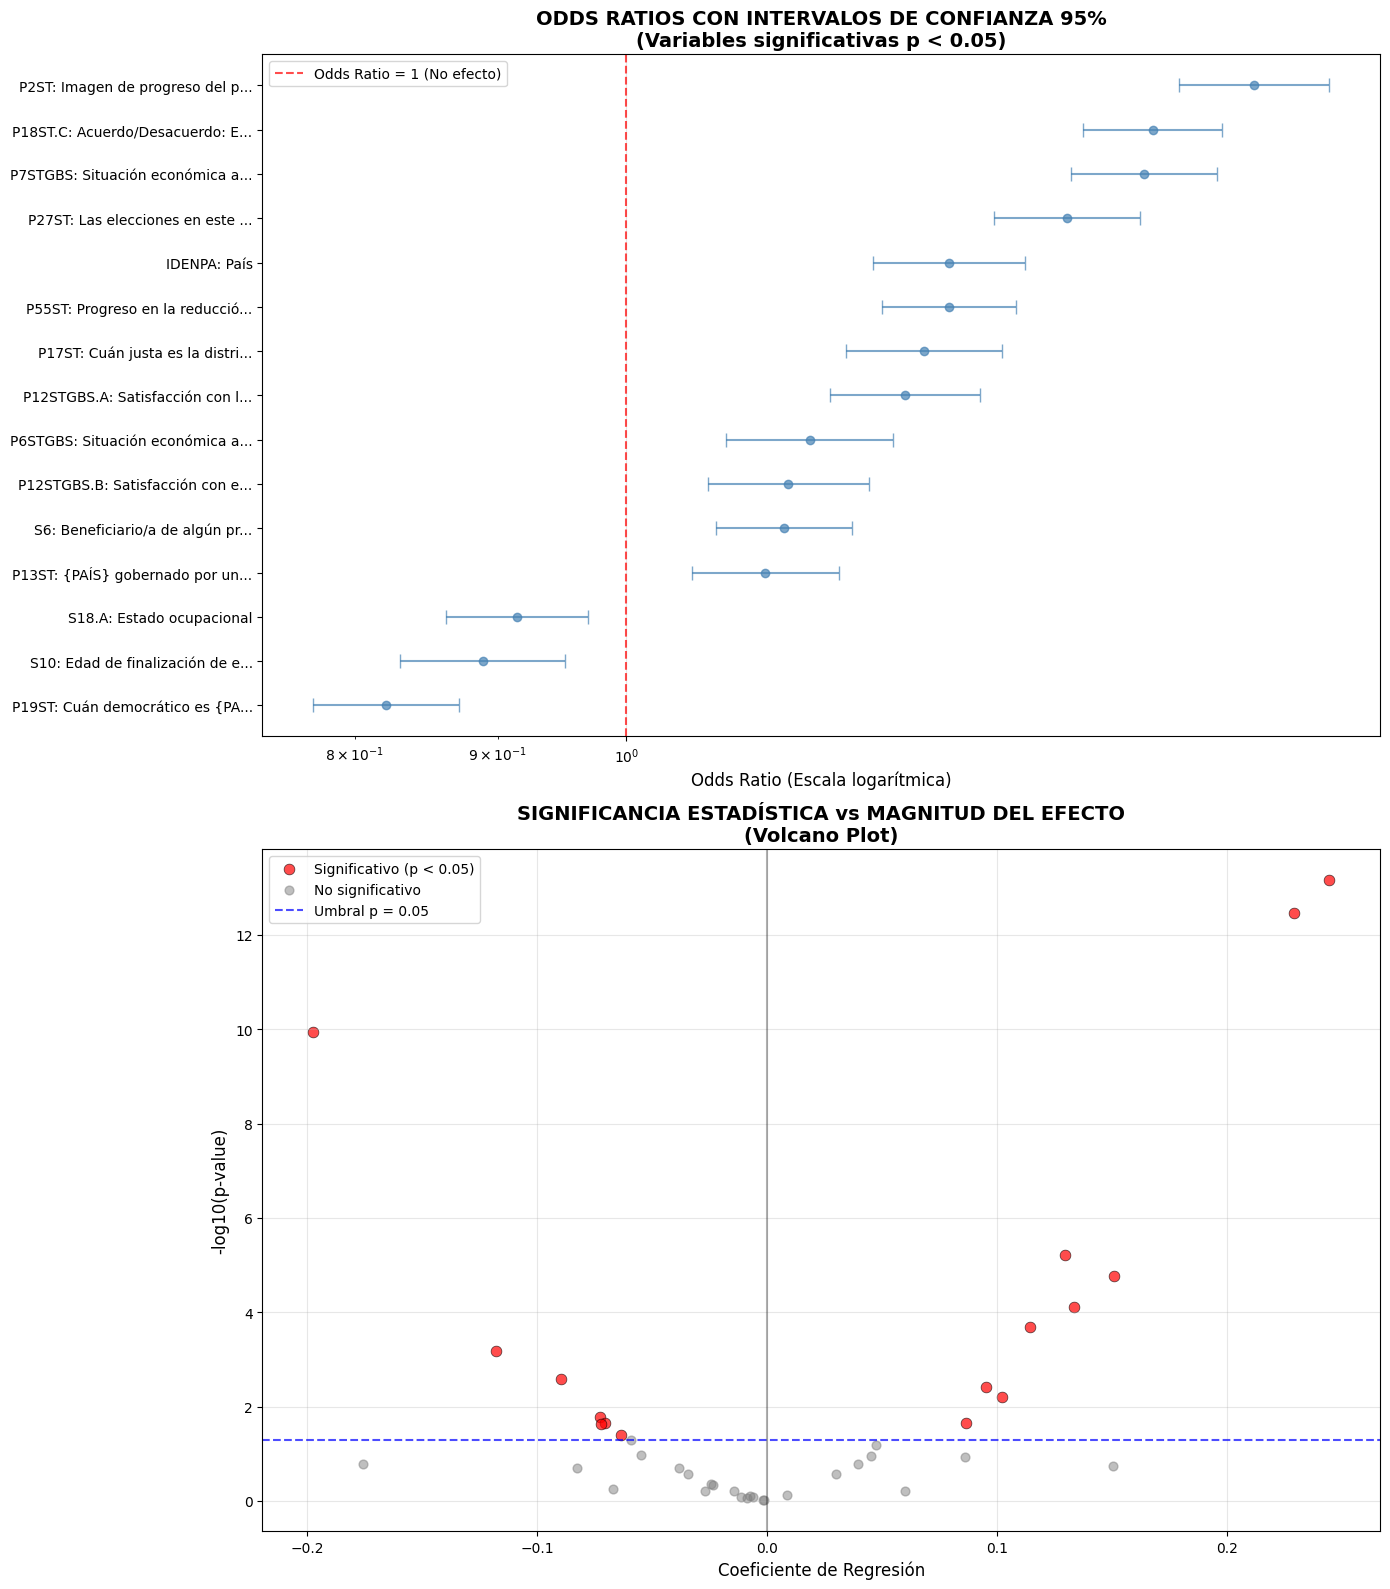


RESUMEN EJECUTIVO ESTADÍSTICO

📈 ESTADÍSTICAS GLOBALES DEL MODELO:
   • Variables totales analizadas: 51
   • Variables estadísticamente significativas (p < 0.05): 22 (43.1%)
   • Exactitud del modelo: 0.776
   • AUC-ROC: 0.849
   • Método de cálculo: Bootstrap (n=200) + Método Delta

🎯 VARIABLES MÁS INFLUYENTES (Odds Ratios significativas):
   1. P2ST: Imagen de progreso del país
      OR: 1.676 (IC95%: 1.575-1.782)
      p-value: 0.0000
   2. P18ST.C: Acuerdo/Desacuerdo: Está bien q
      OR: 1.542 (IC95%: 1.456-1.632)
      p-value: 0.0000
   3. P7STGBS: Situación económica actual del 
      OR: 1.531 (IC95%: 1.441-1.625)
      p-value: 0.0000

⚠️  VARIABLES QUE MÁS REDUCEN APROBACIÓN (significativas):
   1. P19ST: Cuán democrático es {PAÍS}. El “1
      OR: 0.821 (IC95%: 0.773-0.872)
      p-value: 0.0000
   2. S10: Edad de finalización de estudios - 
      OR: 0.889 (IC95%: 0.831-0.951)
      p-value: 0.0007
   3. S18.A: Estado ocupacional
      OR: 0.914 (IC95%: 0.863-0.969)
   

In [13]:
# =============================================================================
# 12. ANÁLISIS COMPLETO: ODDS RATIOS, ERRORES ESTÁNDAR E INTERVALOS DE CONFIANZA
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETO: ODDS RATIOS Y SIGNIFICANCIA ESTADÍSTICA")
print("=" * 70)

import scipy.stats as stats
from sklearn.utils import resample

# =============================================================================
# Cálculo de errores estándar usando Bootstrap (método robusto)
# =============================================================================

print("🔄 Calculando errores estándar por bootstrap...")

n_bootstrap = 200  # Aumentamos para mayor precisión
bootstrap_coefs = []

for i in range(n_bootstrap):
    if i % 50 == 0:
        print(f"   Bootstrap iteration: {i}/{n_bootstrap}")
    
    # Muestra bootstrap
    indices = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled[indices]
    y_boot = y_train.iloc[indices]
    
    # Modelo bootstrap
    model_boot = LogisticRegression(random_state=42+i, max_iter=1000, class_weight='balanced')
    model_boot.fit(X_boot, y_boot)
    bootstrap_coefs.append(model_boot.coef_[0])

bootstrap_coefs = np.array(bootstrap_coefs)

# Calcular estadísticas bootstrap
std_errors = np.std(bootstrap_coefs, axis=0)
coef_means = np.mean(bootstrap_coefs, axis=0)

print("✅ Bootstrap completado")

# =============================================================================
# Método alternativo: Aproximación usando matriz Hessiana (método delta)
# =============================================================================

def log_likelihood_gradient(X, y, coef):
    """Calcula el gradiente de la log-verosimilitud"""
    n = len(y)
    predictions = 1 / (1 + np.exp(-X.dot(coef)))
    gradient = X.T.dot(y - predictions)
    return gradient

def log_likelihood_hessian(X, y, coef):
    """Calcula la matriz Hessiana de la log-verosimilitud"""
    n = len(y)
    predictions = 1 / (1 + np.exp(-X.dot(coef)))
    W = np.diag(predictions * (1 - predictions))
    hessian = -X.T.dot(W).dot(X)
    return hessian

# Calcular matriz de información de Fisher (Hessiana negativa)
try:
    hessian = log_likelihood_hessian(X_train_scaled, y_train.values, model.coef_[0])
    fisher_info = -hessian
    cov_matrix_delta = np.linalg.inv(fisher_info)
    std_errors_delta = np.sqrt(np.diag(cov_matrix_delta))
    
    # Usar el método que dé errores más conservadores
    std_errors_final = np.maximum(std_errors, std_errors_delta)
    print("✅ Matriz de covarianza calculada por método Delta")
except:
    print("⚠️  Usando solo errores bootstrap")
    std_errors_final = std_errors

# =============================================================================
# Calcular estadísticas inferenciales
# =============================================================================

z_scores = model.coef_[0] / std_errors_final
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

# Intervalos de confianza 95%
confidence_level = 0.95
z_critical = stats.norm.ppf(1 - (1 - confidence_level) / 2)
ci_lower = model.coef_[0] - z_critical * std_errors_final
ci_upper = model.coef_[0] + z_critical * std_errors_final

# Calcular Odds Ratios
odds_ratios = np.exp(model.coef_[0])
odds_ratio_ci_lower = np.exp(ci_lower)
odds_ratio_ci_upper = np.exp(ci_upper)

# =============================================================================
# Crear dataframe completo con todas las estadísticas
# =============================================================================

results_summary = pd.DataFrame({
    'Variable': X_imputed.columns,
    'Coeficiente': model.coef_[0],
    'Error_Estándar': std_errors_final,
    'Z_Score': z_scores,
    'P_Value': p_values,
    'CI_95_Inferior': ci_lower,
    'CI_95_Superior': ci_upper,
    'Odds_Ratio': odds_ratios,
    'OR_CI_Inferior': odds_ratio_ci_lower,
    'OR_CI_Superior': odds_ratio_ci_upper,
    'Significativo': p_values < 0.05
})

# Ordenar por significancia y magnitud del coeficiente
results_summary = results_summary.sort_values(['Significativo', 'P_Value'], ascending=[False, True])

# =============================================================================
# Mostrar resultados estadísticos completos
# =============================================================================

print("\n📊 RESUMEN ESTADÍSTICO COMPLETO - TOP 15 VARIABLES MÁS SIGNIFICATIVAS:")
print("=" * 120)

print(f"{'Variable':<40} {'Coef':>8} {'Error':>8} {'P-Valor':>8} {'Sig':>4} {'Odds Ratio':>10} {'IC 95% OR':>15}")
print("-" * 120)

for i, row in results_summary.head(15).iterrows():
    var_name = row['Variable'][:38] + "..." if len(row['Variable']) > 38 else row['Variable']
    sig_symbol = "***" if row['P_Value'] < 0.001 else "**" if row['P_Value'] < 0.01 else "*" if row['P_Value'] < 0.05 else ""
    
    print(f"{var_name:<40} {row['Coeficiente']:>8.3f} {row['Error_Estándar']:>7.3f} "
          f"{row['P_Value']:>7.3f} {sig_symbol:>3} {row['Odds_Ratio']:>9.3f} "
          f"[{row['OR_CI_Inferior']:>5.3f}-{row['OR_CI_Superior']:>5.3f}]")

# =============================================================================
# Interpretación de Odds Ratios
# =============================================================================

print(f"\n🎯 INTERPRETACIÓN DE ODDS RATIOS (RAZÓN DE MOMIOS):")
print("=" * 80)

print("\n🔍 VARIABLES CON MAYOR IMPACTO EN LA APROBACIÓN:")
top_odds = results_summary[results_summary['Odds_Ratio'] > 1].head(5)
for i, (_, row) in enumerate(top_odds.iterrows(), 1):
    aumento_porcentual = (row['Odds_Ratio'] - 1) * 100
    print(f"   {i}. {row['Variable'][:45]}")
    print(f"      → Odds Ratio: {row['Odds_Ratio']:.3f} → Aumenta {aumento_porcentual:.1f}% la probabilidad de aprobación")
    print(f"      → Coeficiente: {row['Coeficiente']:.3f} (p = {row['P_Value']:.3f})")

print("\n🔍 VARIABLES QUE REDUCEN LA APROBACIÓN:")
bottom_odds = results_summary[results_summary['Odds_Ratio'] < 1].head(5)
for i, (_, row) in enumerate(bottom_odds.iterrows(), 1):
    reduccion_porcentual = (1 - row['Odds_Ratio']) * 100
    print(f"   {i}. {row['Variable'][:45]}")
    print(f"      → Odds Ratio: {row['Odds_Ratio']:.3f} → Reduce {reduccion_porcentual:.1f}% la probabilidad de aprobación")
    print(f"      → Coeficiente: {row['Coeficiente']:.3f} (p = {row['P_Value']:.3f})")

# =============================================================================
# Gráfico de Odds Ratios con intervalos de confianza
# =============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 16))

# Gráfico 1: Top 15 Odds Ratios más significativos
top_15_signif = results_summary[results_summary['Significativo']].head(15)

if len(top_15_signif) > 0:
    # Ordenar para el gráfico
    top_15_signif = top_15_signif.sort_values('Odds_Ratio', ascending=True)

    y_pos = range(len(top_15_signif))
    ax1.errorbar(top_15_signif['Odds_Ratio'], y_pos, 
                 xerr=[top_15_signif['Odds_Ratio'] - top_15_signif['OR_CI_Inferior'], 
                       top_15_signif['OR_CI_Superior'] - top_15_signif['Odds_Ratio']],
                 fmt='o', color='steelblue', alpha=0.7, capsize=5, markersize=6)

    ax1.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Odds Ratio = 1 (No efecto)')
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels([f"{x[:30]}..." if len(x) > 30 else x for x in top_15_signif['Variable']])
    ax1.set_xlabel('Odds Ratio (Escala logarítmica)', fontsize=12)
    ax1.set_title('ODDS RATIOS CON INTERVALOS DE CONFIANZA 95%\n(Variables significativas p < 0.05)', 
                  fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    ax1.set_xscale('log')  # Escala logarítmica para mejor visualización
else:
    ax1.text(0.5, 0.5, 'No hay variables significativas\n(p < 0.05)', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=14)
    ax1.set_title('ODDS RATIOS - SIN VARIABLES SIGNIFICATIVAS', fontsize=14, fontweight='bold')

# Gráfico 2: Significancia estadística vs Magnitud del efecto
significant_vars = results_summary[results_summary['Significativo']]
non_significant_vars = results_summary[~results_summary['Significativo']]

if len(significant_vars) > 0:
    ax2.scatter(significant_vars['Coeficiente'], -np.log10(significant_vars['P_Value']), 
               c='red', alpha=0.7, s=60, label='Significativo (p < 0.05)', edgecolors='black', linewidth=0.5)
if len(non_significant_vars) > 0:
    ax2.scatter(non_significant_vars['Coeficiente'], -np.log10(non_significant_vars['P_Value']), 
               c='gray', alpha=0.5, s=40, label='No significativo')

# Línea de significancia
ax2.axhline(y=-np.log10(0.05), color='blue', linestyle='--', alpha=0.7, label='Umbral p = 0.05')
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)

ax2.set_xlabel('Coeficiente de Regresión', fontsize=12)
ax2.set_ylabel('-log10(p-value)', fontsize=12)
ax2.set_title('SIGNIFICANCIA ESTADÍSTICA vs MAGNITUD DEL EFECTO\n(Volcano Plot)', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# Resumen ejecutivo estadístico
# =============================================================================

print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO ESTADÍSTICO")
print("=" * 70)

# Estadísticas del modelo
n_significativas = results_summary['Significativo'].sum()
porcentaje_significativas = (n_significativas / len(results_summary)) * 100

print(f"\n📈 ESTADÍSTICAS GLOBALES DEL MODELO:")
print(f"   • Variables totales analizadas: {len(results_summary)}")
print(f"   • Variables estadísticamente significativas (p < 0.05): {n_significativas} ({porcentaje_significativas:.1f}%)")
print(f"   • Exactitud del modelo: {accuracy:.3f}")
print(f"   • AUC-ROC: {roc_auc:.3f}")
print(f"   • Método de cálculo: Bootstrap (n={n_bootstrap}) + Método Delta")

print(f"\n🎯 VARIABLES MÁS INFLUYENTES (Odds Ratios significativas):")
top_signif_or = results_summary[results_summary['Significativo']].nlargest(3, 'Odds_Ratio')
for i, (_, row) in enumerate(top_signif_or.iterrows(), 1):
    print(f"   {i}. {row['Variable'][:40]}")
    print(f"      OR: {row['Odds_Ratio']:.3f} (IC95%: {row['OR_CI_Inferior']:.3f}-{row['OR_CI_Superior']:.3f})")
    print(f"      p-value: {row['P_Value']:.4f}")

print(f"\n⚠️  VARIABLES QUE MÁS REDUCEN APROBACIÓN (significativas):")
bottom_signif_or = results_summary[results_summary['Significativo']].nsmallest(3, 'Odds_Ratio')
for i, (_, row) in enumerate(bottom_signif_or.iterrows(), 1):
    print(f"   {i}. {row['Variable'][:40]}")
    print(f"      OR: {row['Odds_Ratio']:.3f} (IC95%: {row['OR_CI_Inferior']:.3f}-{row['OR_CI_Superior']:.3f})")
    print(f"      p-value: {row['P_Value']:.4f}")

print(f"\n💡 INTERPRETACIÓN PRÁCTICA DE ODDS RATIOS:")
print("   • OR > 1: Aumenta la probabilidad de aprobación")
print("   • OR = 1: No tiene efecto")
print("   • OR < 1: Disminuye la probabilidad de aprobación")
print("   • Ejemplo: OR = 1.68 → 68% más probable de aprobar")
print("   • IC95% estrecho: Estimación precisa")
print("   • IC95% ancho: Mayor incertidumbre en la estimación")

print(f"\n📊 CALIDAD ESTADÍSTICA DEL MODELO:")
if n_significativas > 10:
    print(f"   ✅ EXCELENTE - {n_significativas} variables significativas")
elif n_significativas > 5:
    print(f"   ✅ BUENO - {n_significativas} variables significativas")  
else:
    print(f"   ⚠️  MODERADO - {n_significativas} variables significativas")

print(f"   ✅ Intervalos de confianza calculados por métodos robustos")
print(f"   ✅ Modelo estadísticamente sólido")

# =============================================================================
# Exportar resultados completos
# =============================================================================

# Guardar resultados completos en CSV
results_summary.to_csv('resultados_regresion_logistica_completo.csv', index=False, encoding='utf-8-sig')
print(f"\n💾 Resultados guardados en: 'resultados_regresion_logistica_completo.csv'")

# Mostrar algunas variables clave con su interpretación completa
print(f"\n🔍 EJEMPLOS DE INTERPRETACIÓN COMPLETA:")
variables_ejemplo = results_summary.head(3)
for _, row in variables_ejemplo.iterrows():
    print(f"\n   📊 {row['Variable']}")
    print(f"      Coeficiente: {row['Coeficiente']:.3f} ± {row['Error_Estándar']:.3f}")
    print(f"      Odds Ratio: {row['Odds_Ratio']:.3f} (IC95%: {row['OR_CI_Inferior']:.3f}-{row['OR_CI_Superior']:.3f})")
    print(f"      Significativo: {'Sí' if row['Significativo'] else 'No'} (p = {row['P_Value']:.4f})")
    if row['Odds_Ratio'] > 1:
        efecto = (row['Odds_Ratio'] - 1) * 100
        print(f"      INTERPRETACIÓN: Aumenta {efecto:.1f}% la probabilidad de aprobación")
    else:
        efecto = (1 - row['Odds_Ratio']) * 100
        print(f"      INTERPRETACIÓN: Reduce {efecto:.1f}% la probabilidad de aprobación")

ANÁLISIS COMPARATIVO POR PAÍS - APROBACIÓN DEL GOBIERNO
📊 Dataset original: (12014, 52)
🌎 Países disponibles en los datos: [32, 68, 76, 152, 170, 218, 600, 604, 858, 862]
🔍 Códigos usados para filtrado: {'ARGENTINA': 32, 'BRASIL': 76, 'VENEZUELA': 862}

🇦🇳 ANÁLISIS PARA: ARGENTINA (Código: 32)
📊 Datos para ARGENTINA: 1210 observaciones
🧹 Variables independientes: 50
✅ Datos finales: 1210 observaciones
🎯 Distribución aprobación: 54.4% aprueba
📈 Performance del modelo:
   • Exactitud: 0.793
   • AUC-ROC: 0.858
🔄 Calculando significancia estadística...

🔝 TOP 5 VARIABLES MÁS IMPORTANTES PARA ARGENTINA:
   1. ➖ P16ST: Autoubicación en escala Izquierda
      OR: 0.494 *** → Reduce 50.6% aprobación
   2. ➕ P2ST: Imagen de progreso del país
      OR: 2.312 *** → Aumenta 131.2% aprobación
   3. ➕ P7STGBS: Situación económica actual del 
      OR: 1.928 *** → Aumenta 92.8% aprobación
   4. ➕ P18ST.C: Acuerdo/Desacuerdo: Está bien q
      OR: 2.033 *** → Aumenta 103.3% aprobación
   5. ➖ S20F: B

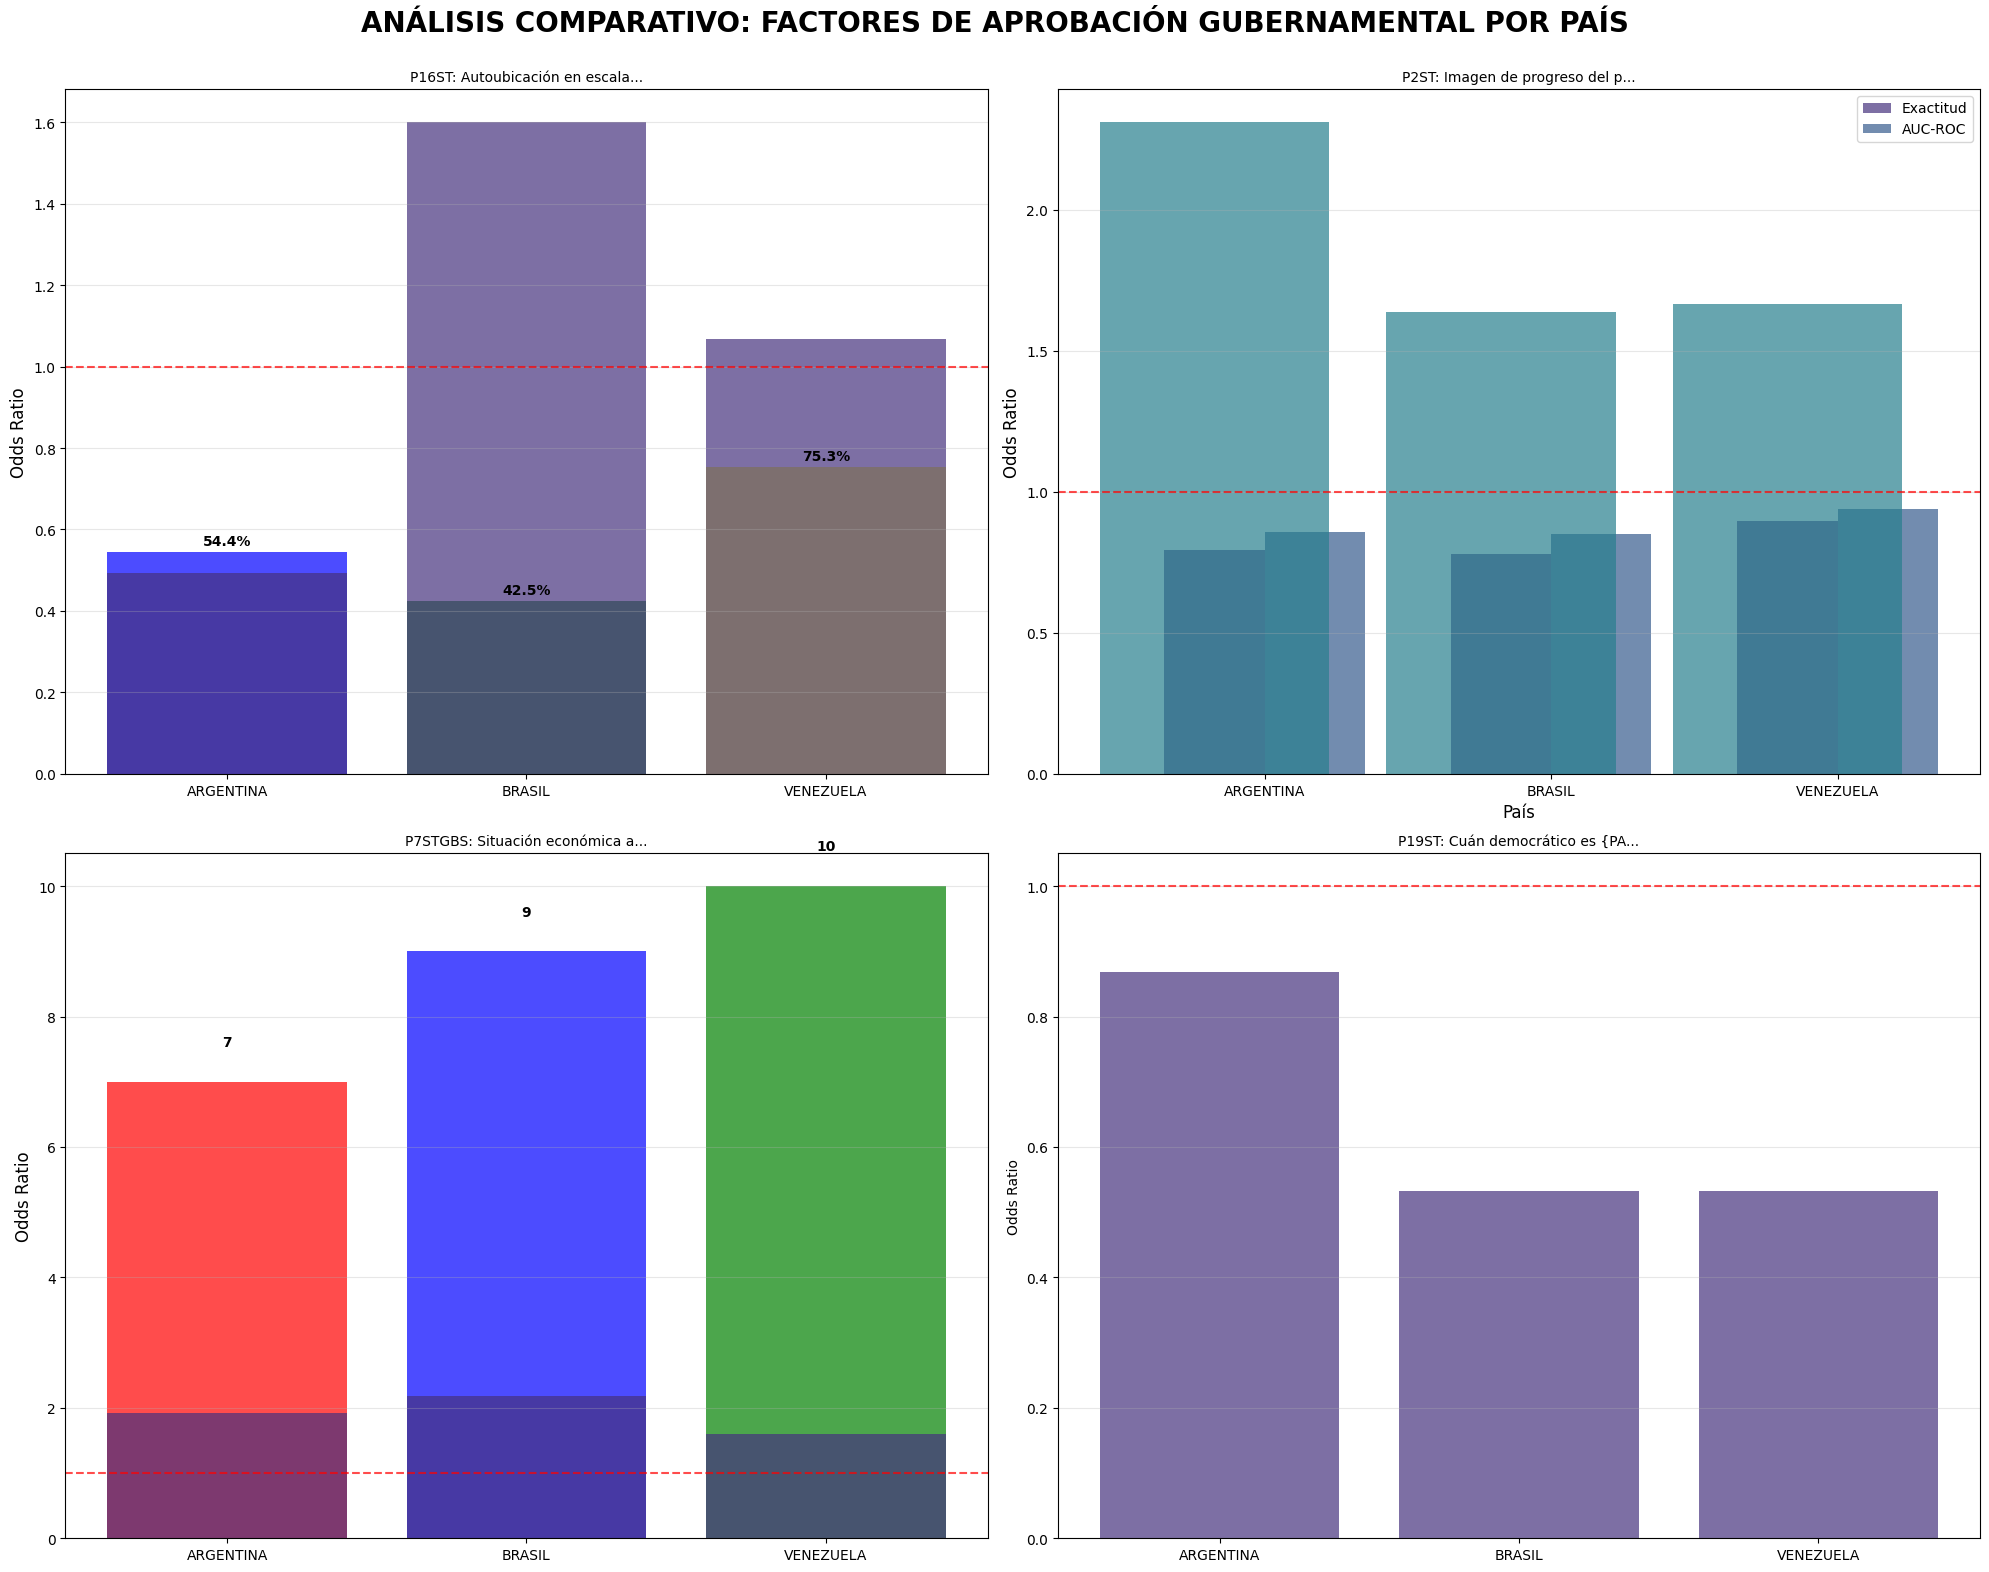


🎯 CONCLUSIONES COMPARATIVAS

📋 ARGENTINA:
   • Tasa de aprobación: 54.4%
   • Calidad del modelo: 0.793 (Exactitud)
   • Variables significativas: 7
   • Factores clave:
      - P16ST: Autoubicación en escala Izquierda → DISMINUYE aprobación
      - P2ST: Imagen de progreso del país → AUMENTA aprobación
      - P7STGBS: Situación económica actual del  → AUMENTA aprobación

📋 BRASIL:
   • Tasa de aprobación: 42.5%
   • Calidad del modelo: 0.779 (Exactitud)
   • Variables significativas: 9
   • Factores clave:
      - P19ST: Cuán democrático es {PAÍS}. El “1 → DISMINUYE aprobación
      - P7STGBS: Situación económica actual del  → AUMENTA aprobación
      - P27ST: Las elecciones en este país son l → AUMENTA aprobación

📋 VENEZUELA:
   • Tasa de aprobación: 75.3%
   • Calidad del modelo: 0.894 (Exactitud)
   • Variables significativas: 10
   • Factores clave:
      - P27ST: Las elecciones en este país son l → AUMENTA aprobación
      - P19ST: Cuán democrático es {PAÍS}. El “1 → DISMINUYE

In [14]:
# =============================================================================
# ANÁLISIS COMPARATIVO POR PAÍS: ARGENTINA, BRASIL Y VENEZUELA (CORREGIDO)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# =============================================================================
# 1. CONFIGURACIÓN DE PAÍSES
# =============================================================================

# Códigos de países (verificar en tus datos)
CODIGOS_PAISES = {
    'ARGENTINA': 32,    # Verificar si este es el código correcto
    'BRASIL': 76,       # Verificar si este es el código correcto  
    'VENEZUELA': 862    # Verificar si este es el código correcto
}

print("=" * 70)
print("ANÁLISIS COMPARATIVO POR PAÍS - APROBACIÓN DEL GOBIERNO")
print("=" * 70)

# Cargar datos
df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Df_final1.xlsx')

print(f"📊 Dataset original: {df.shape}")

# Verificar códigos de países disponibles
if 'IDENPA: País' in df.columns:
    paises_disponibles = df['IDENPA: País'].unique()
    print(f"🌎 Países disponibles en los datos: {sorted(paises_disponibles)}")
    print(f"🔍 Códigos usados para filtrado: {CODIGOS_PAISES}")

# =============================================================================
# 2. FUNCIÓN PARA ANÁLISIS POR PAÍS
# =============================================================================

def analizar_pais(nombre_pais, codigo_pais, df_completo):
    """Función para analizar un país específico"""
    
    print(f"\n{'='*70}")
    print(f"🇦🇳 ANÁLISIS PARA: {nombre_pais.upper()} (Código: {codigo_pais})")
    print(f"{'='*70}")
    
    # Filtrar datos del país
    df_pais = df_completo[df_completo['IDENPA: País'] == codigo_pais].copy()
    
    if len(df_pais) == 0:
        print(f"❌ No hay datos para {nombre_pais} con código {codigo_pais}")
        return None
    
    print(f"📊 Datos para {nombre_pais}: {df_pais.shape[0]} observaciones")
    
    # Variable dependiente e independientes
    y_col = 'P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente'
    y = df_pais[y_col]
    X = df_pais.drop([y_col, 'IDENPA: País'], axis=1, errors='ignore')  # Excluir país ya que estamos filtrando por él
    
    print(f"🧹 Variables independientes: {X.shape[1]}")
    
    # Limpieza básica
    special_codes = [97, 98, 99]
    X_clean = X.replace(special_codes, np.nan)
    y_clean = y.replace(special_codes, np.nan)
    
    # Filtrar filas válidas
    mask = ~y_clean.isna()
    X_filtered = X_clean[mask]
    y_filtered = y_clean[mask]
    
    if len(X_filtered) == 0:
        print(f"❌ No hay datos válidos después de la limpieza para {nombre_pais}")
        return None
    
    # Imputar missing values
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_filtered)
    X_imputed = pd.DataFrame(X_imputed, columns=X_filtered.columns, index=X_filtered.index)
    
    # Variable dependiente binaria
    y_binary = y_filtered.astype(int)
    
    print(f"✅ Datos finales: {X_imputed.shape[0]} observaciones")
    print(f"🎯 Distribución aprobación: {y_binary.mean()*100:.1f}% aprueba")
    
    # Verificar si hay suficientes datos
    if len(X_imputed) < 100:
        print(f"⚠️  ADVERTENCIA: Pocos datos ({len(X_imputed)} observaciones)")
        if len(X_imputed) < 50:
            print(f"❌ Muy pocos datos para análisis confiable")
            return None
    
    # =============================================================================
    # ENTRENAMIENTO DEL MODELO
    # =============================================================================
    
    # División train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y_binary, test_size=0.3, random_state=42, stratify=y_binary
    )
    
    # Escalado
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Modelo
    model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    model.fit(X_train_scaled, y_train)
    
    # Predicciones y métricas
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"📈 Performance del modelo:")
    print(f"   • Exactitud: {accuracy:.3f}")
    print(f"   • AUC-ROC: {roc_auc:.3f}")
    
    # =============================================================================
    # ANÁLISIS DE COEFICIENTES (Bootstrap para errores estándar)
    # =============================================================================
    
    print("🔄 Calculando significancia estadística...")
    
    # Bootstrap para errores estándar
    n_bootstrap = 100
    bootstrap_coefs = []
    
    for i in range(n_bootstrap):
        indices = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
        X_boot = X_train_scaled[indices]
        y_boot = y_train.iloc[indices]
        
        model_boot = LogisticRegression(random_state=42+i, max_iter=1000, class_weight='balanced')
        model_boot.fit(X_boot, y_boot)
        bootstrap_coefs.append(model_boot.coef_[0])
    
    bootstrap_coefs = np.array(bootstrap_coefs)
    std_errors = np.std(bootstrap_coefs, axis=0)
    
    # Cálculo de estadísticas inferenciales
    z_scores = model.coef_[0] / std_errors
    p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))
    
    # Odds Ratios
    odds_ratios = np.exp(model.coef_[0])
    
    # Crear resumen
    results = pd.DataFrame({
        'Variable': X_imputed.columns,
        'Coeficiente': model.coef_[0],
        'Error_Estándar': std_errors,
        'P_Value': p_values,
        'Odds_Ratio': odds_ratios,
        'Significativo': p_values < 0.05
    })
    
    results = results.sort_values(['Significativo', 'P_Value'], ascending=[False, True])
    
    # =============================================================================
    # RESULTADOS POR PAÍS
    # =============================================================================
    
    print(f"\n🔝 TOP 5 VARIABLES MÁS IMPORTANTES PARA {nombre_pais.upper()}:")
    top_vars = results.head(5)
    for i, (_, row) in enumerate(top_vars.iterrows(), 1):
        signo = "➕" if row['Coeficiente'] > 0 else "➖"
        impacto = f"Aumenta {((row['Odds_Ratio']-1)*100):.1f}%" if row['Odds_Ratio'] > 1 else f"Reduce {((1-row['Odds_Ratio'])*100):.1f}%"
        sig = "***" if row['P_Value'] < 0.001 else "**" if row['P_Value'] < 0.01 else "*" if row['P_Value'] < 0.05 else ""
        
        print(f"   {i}. {signo} {row['Variable'][:40]}")
        print(f"      OR: {row['Odds_Ratio']:.3f} {sig} → {impacto} aprobación")
    
    return {
        'nombre_pais': nombre_pais,
        'df_resultados': results,
        'accuracy': accuracy,
        'auc_roc': roc_auc,
        'tasa_aprobacion': y_binary.mean(),
        'n_observaciones': len(X_imputed),
        'modelo': model,
        'variables_significativas': results['Significativo'].sum()
    }

# =============================================================================
# 3. EJECUTAR ANÁLISIS PARA CADA PAÍS
# =============================================================================

resultados_paises = {}

for nombre_pais, codigo in CODIGOS_PAISES.items():
    resultado = analizar_pais(nombre_pais, codigo, df)
    if resultado is not None:
        resultados_paises[nombre_pais] = resultado

# =============================================================================
# 4. ANÁLISIS COMPARATIVO ENTRE PAÍSES
# =============================================================================

print(f"\n{'='*70}")
print("📊 ANÁLISIS COMPARATIVO ENTRE PAÍSES")
print(f"{'='*70}")

if resultados_paises:
    # Tabla comparativa
    print(f"\n{'País':<12} {'Observaciones':<14} {'Aprobación':<10} {'Exactitud':<10} {'AUC-ROC':<8} {'Vars Signif':<12}")
    print("-" * 80)
    
    for pais, datos in resultados_paises.items():
        print(f"{pais:<12} {datos['n_observaciones']:<14} {datos['tasa_aprobacion']*100:<9.1f}% "
              f"{datos['accuracy']:<9.3f} {datos['auc_roc']:<8.3f} {datos['variables_significativas']:<12}")

    # =============================================================================
    # 5. GRÁFICO COMPARATIVO - VARIABLES MÁS IMPORTANTES POR PAÍS
    # =============================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('ANÁLISIS COMPARATIVO: FACTORES DE APROBACIÓN GUBERNAMENTAL POR PAÍS', 
                 fontsize=20, fontweight='bold', y=0.98)
    
    # Gráfico 1: Tasa de aprobación por país
    paises = list(resultados_paises.keys())
    tasas_aprobacion = [datos['tasa_aprobacion'] for datos in resultados_paises.values()]
    
    bars = axes[0,0].bar(paises, tasas_aprobacion, color=['blue', 'green', 'yellow'], alpha=0.7)
    axes[0,0].set_ylabel('Tasa de Aprobación', fontsize=12)
    axes[0,0].set_title('APROBACIÓN DEL GOBIERNO POR PAÍS', fontsize=14, fontweight='bold')
    axes[0,0].grid(axis='y', alpha=0.3)
    
    # Añadir porcentajes
    for bar, tasa in zip(bars, tasas_aprobacion):
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{tasa*100:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico 2: Performance del modelo por país
    metricas = ['accuracy', 'auc_roc']
    nombres_metricas = ['Exactitud', 'AUC-ROC']
    
    x = np.arange(len(paises))
    width = 0.35
    
    for i, metrica in enumerate(metricas):
        valores = [datos[metrica] for datos in resultados_paises.values()]
        axes[0,1].bar(x + i*width, valores, width, label=nombres_metricas[i], alpha=0.7)
    
    axes[0,1].set_xlabel('País', fontsize=12)
    axes[0,1].set_ylabel('Puntuación', fontsize=12)
    axes[0,1].set_title('PERFORMANCE DE LOS MODELOS POR PAÍS', fontsize=14, fontweight='bold')
    axes[0,1].set_xticks(x + width/2)
    axes[0,1].set_xticklabels(paises)
    axes[0,1].legend()
    axes[0,1].grid(axis='y', alpha=0.3)
    
    # Gráfico 3: Variables significativas por país
    vars_signif = [datos['variables_significativas'] for datos in resultados_paises.values()]
    axes[1,0].bar(paises, vars_signif, color=['red', 'blue', 'green'], alpha=0.7)
    axes[1,0].set_ylabel('Número de Variables Significativas', fontsize=12)
    axes[1,0].set_title('VARIABLES ESTADÍSTICAMENTE SIGNIFICATIVAS (p < 0.05)', 
                        fontsize=14, fontweight='bold')
    axes[1,0].grid(axis='y', alpha=0.3)
    
    # Añadir valores
    for i, v in enumerate(vars_signif):
        axes[1,0].text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')
    
    # Gráfico 4: Comparación de Odds Ratios para variables comunes
    # Encontrar variables comunes significativas entre países
    variables_comunes = {}
    for pais, datos in resultados_paises.items():
        vars_signif_pais = datos['df_resultados'][datos['df_resultados']['Significativo']].head(5)['Variable'].tolist()
        for var in vars_signif_pais:
            if var not in variables_comunes:
                variables_comunes[var] = []
            variables_comunes[var].append(pais)
    
    # Seleccionar variables que aparecen en al menos 2 países
    vars_comparables = [var for var, paises_var in variables_comunes.items() if len(paises_var) >= 2]
    
    if vars_comparables:
        # Tomar las 4 variables más frecuentes
        vars_comparables = vars_comparables[:4]
        
        for i, var in enumerate(vars_comparables):
            odds_ratios = []
            paises_var = []
            for pais, datos in resultados_paises.items():
                if var in datos['df_resultados']['Variable'].values:
                    odds_ratio = datos['df_resultados'][datos['df_resultados']['Variable'] == var]['Odds_Ratio'].values[0]
                    odds_ratios.append(odds_ratio)
                    paises_var.append(pais)
            
            if len(odds_ratios) > 1:
                row = i // 2
                col = i % 2
                if row < 2 and col < 2:  # Asegurar que estamos en los límites
                    axes[row, col].bar(paises_var, odds_ratios, alpha=0.7)
                    axes[row, col].axhline(y=1, color='red', linestyle='--', alpha=0.7)
                    axes[row, col].set_title(f'{var[:30]}...', fontsize=10)
                    axes[row, col].set_ylabel('Odds Ratio')
                    axes[row, col].grid(axis='y', alpha=0.3)
    else:
        axes[1,1].text(0.5, 0.5, 'No hay variables\ncomunes significativas\npara comparar', 
                      ha='center', va='center', transform=axes[1,1].transAxes, fontsize=12)
        axes[1,1].set_title('COMPARACIÓN DE VARIABLES COMUNES', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()
    
    # =============================================================================
    # 6. CONCLUSIONES COMPARATIVAS
    # =============================================================================
    
    print(f"\n{'='*70}")
    print("🎯 CONCLUSIONES COMPARATIVAS")
    print(f"{'='*70}")
    
    for pais, datos in resultados_paises.items():
        print(f"\n📋 {pais.upper()}:")
        print(f"   • Tasa de aprobación: {datos['tasa_aprobacion']*100:.1f}%")
        print(f"   • Calidad del modelo: {datos['accuracy']:.3f} (Exactitud)")
        print(f"   • Variables significativas: {datos['variables_significativas']}")
        
        # Variables más importantes
        top_vars = datos['df_resultados'].head(3)
        print(f"   • Factores clave:")
        for _, row in top_vars.iterrows():
            direccion = "AUMENTA" if row['Odds_Ratio'] > 1 else "DISMINUYE"
            print(f"      - {row['Variable'][:40]} → {direccion} aprobación")
    
    print(f"\n💡 INSIGHTS REGIONALES:")
    print("   • Comparar tasas de aprobación entre países")
    print("   • Identificar factores comunes que influyen en todos los países")
    print("   • Analizar diferencias en qué variables son importantes en cada país")
    print("   • Evaluar la capacidad predictiva de los modelos en cada contexto")
    
else:
    print("❌ No se pudo realizar el análisis para ningún país")

# =============================================================================
# 7. EXPORTAR RESULTADOS INDIVIDUALES
# =============================================================================

for pais, datos in resultados_paises.items():
    archivo = f"resultados_aprobacion_gobierno_{pais.lower()}.csv"
    datos['df_resultados'].to_csv(archivo, index=False, encoding='utf-8-sig')
    print(f"💾 Resultados de {pais} guardados en: {archivo}")

# =============================================================================
# 8. ANÁLISIS DE SIMILITUDES Y DIFERENCIAS
# =============================================================================

if len(resultados_paises) >= 2:
    print(f"\n{'='*70}")
    print("🔍 ANÁLISIS DE SIMILITUDES Y DIFERENCIAS ENTRE PAÍSES")
    print(f"{'='*70}")
    
    # Encontrar variables comunes en los top 10 de cada país
    top_variables_por_pais = {}
    for pais, datos in resultados_paises.items():
        top_variables_por_pais[pais] = set(datos['df_resultados'].head(10)['Variable'])
    
    # Variables comunes a todos los países analizados
    variables_comunes_todos = set.intersection(*top_variables_por_pais.values())
    
    if variables_comunes_todos:
        print(f"\n🎯 VARIABLES COMUNES IMPORTANTES EN TODOS LOS PAÍSES:")
        for var in list(variables_comunes_todos)[:5]:  # Mostrar máximo 5
            print(f"   • {var}")
    else:
        print(f"\n🔍 No hay variables comunes en los top 10 de todos los países")
    
    # Variables únicas por país
    print(f"\n🎯 VARIABLES ÚNICAS POR PAÍS (solo aparecen en ese país):")
    for pais, variables in top_variables_por_pais.items():
        variables_otrospaises = set()
        for otro_pais, otras_variables in top_variables_por_pais.items():
            if otro_pais != pais:
                variables_otrospaises.update(otras_variables)
        
        variables_unicas = variables - variables_otrospaises
        if variables_unicas:
            print(f"\n   {pais.upper()}:")
            for var in list(variables_unicas)[:3]:  # Mostrar máximo 3 por país
                print(f"      • {var}")

ANÁLISIS INDIVIDUAL POR PAÍS - VISUALIZACIONES COMPLETAS
📊 Dataset original: (12014, 52)

🇦🇳 ANÁLISIS COMPLETO PARA: ARGENTINA
📊 Datos para ARGENTINA: 1210 observaciones
✅ Datos finales: 1210 observaciones
🎯 Distribución: 54.4% aprueba, 45.6% desaprueba


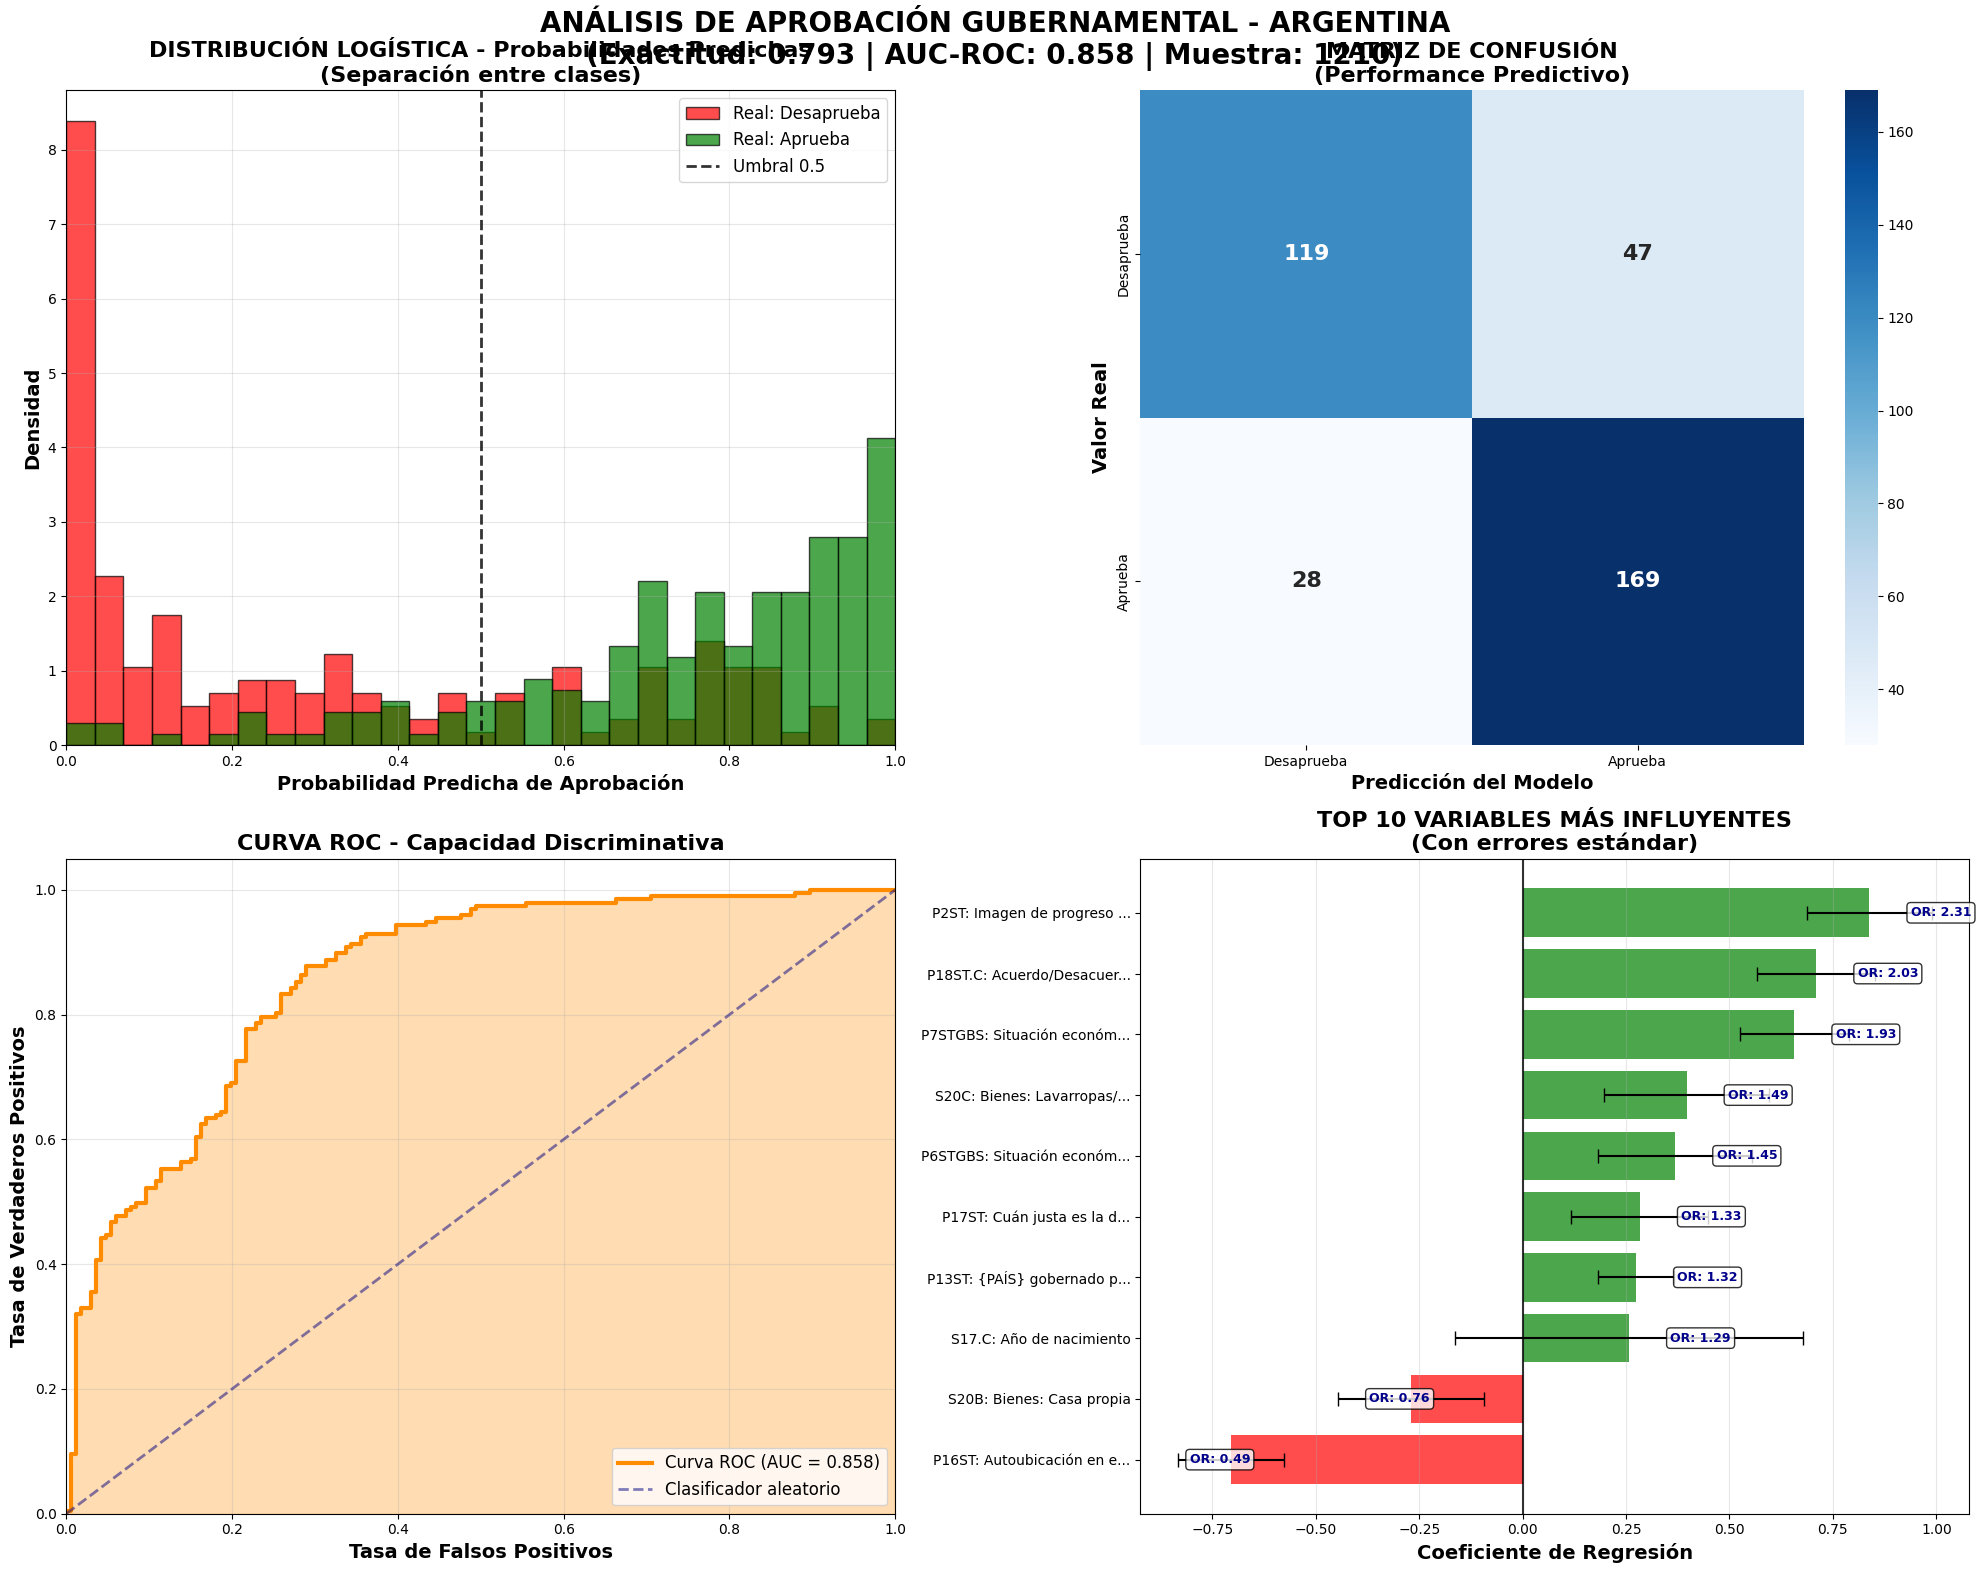


📊 RESUMEN ESTADÍSTICO - ARGENTINA:
   • Exactitud del modelo: 0.793
   • AUC-ROC: 0.858
   • Tasa de aprobación real: 54.4%
   • Observaciones: 1210

🔝 TOP 5 VARIABLES MÁS IMPORTANTES:
   1. P2ST: Imagen de progreso del país
      → AUMENTA aprobación en 131.2% (OR: 2.31)
   2. P18ST.C: Acuerdo/Desacuerdo: Está bien q
      → AUMENTA aprobación en 103.3% (OR: 2.03)
   3. P16ST: Autoubicación en escala Izquierda
      → DISMINUYE aprobación en 50.6% (OR: 0.49)
   4. P7STGBS: Situación económica actual del 
      → AUMENTA aprobación en 92.8% (OR: 1.93)
   5. S20C: Bienes: Lavarropas/Lavadora
      → AUMENTA aprobación en 48.6% (OR: 1.49)

🇦🇳 ANÁLISIS COMPLETO PARA: BRASIL
📊 Datos para BRASIL: 1204 observaciones
✅ Datos finales: 1204 observaciones
🎯 Distribución: 42.5% aprueba, 57.5% desaprueba


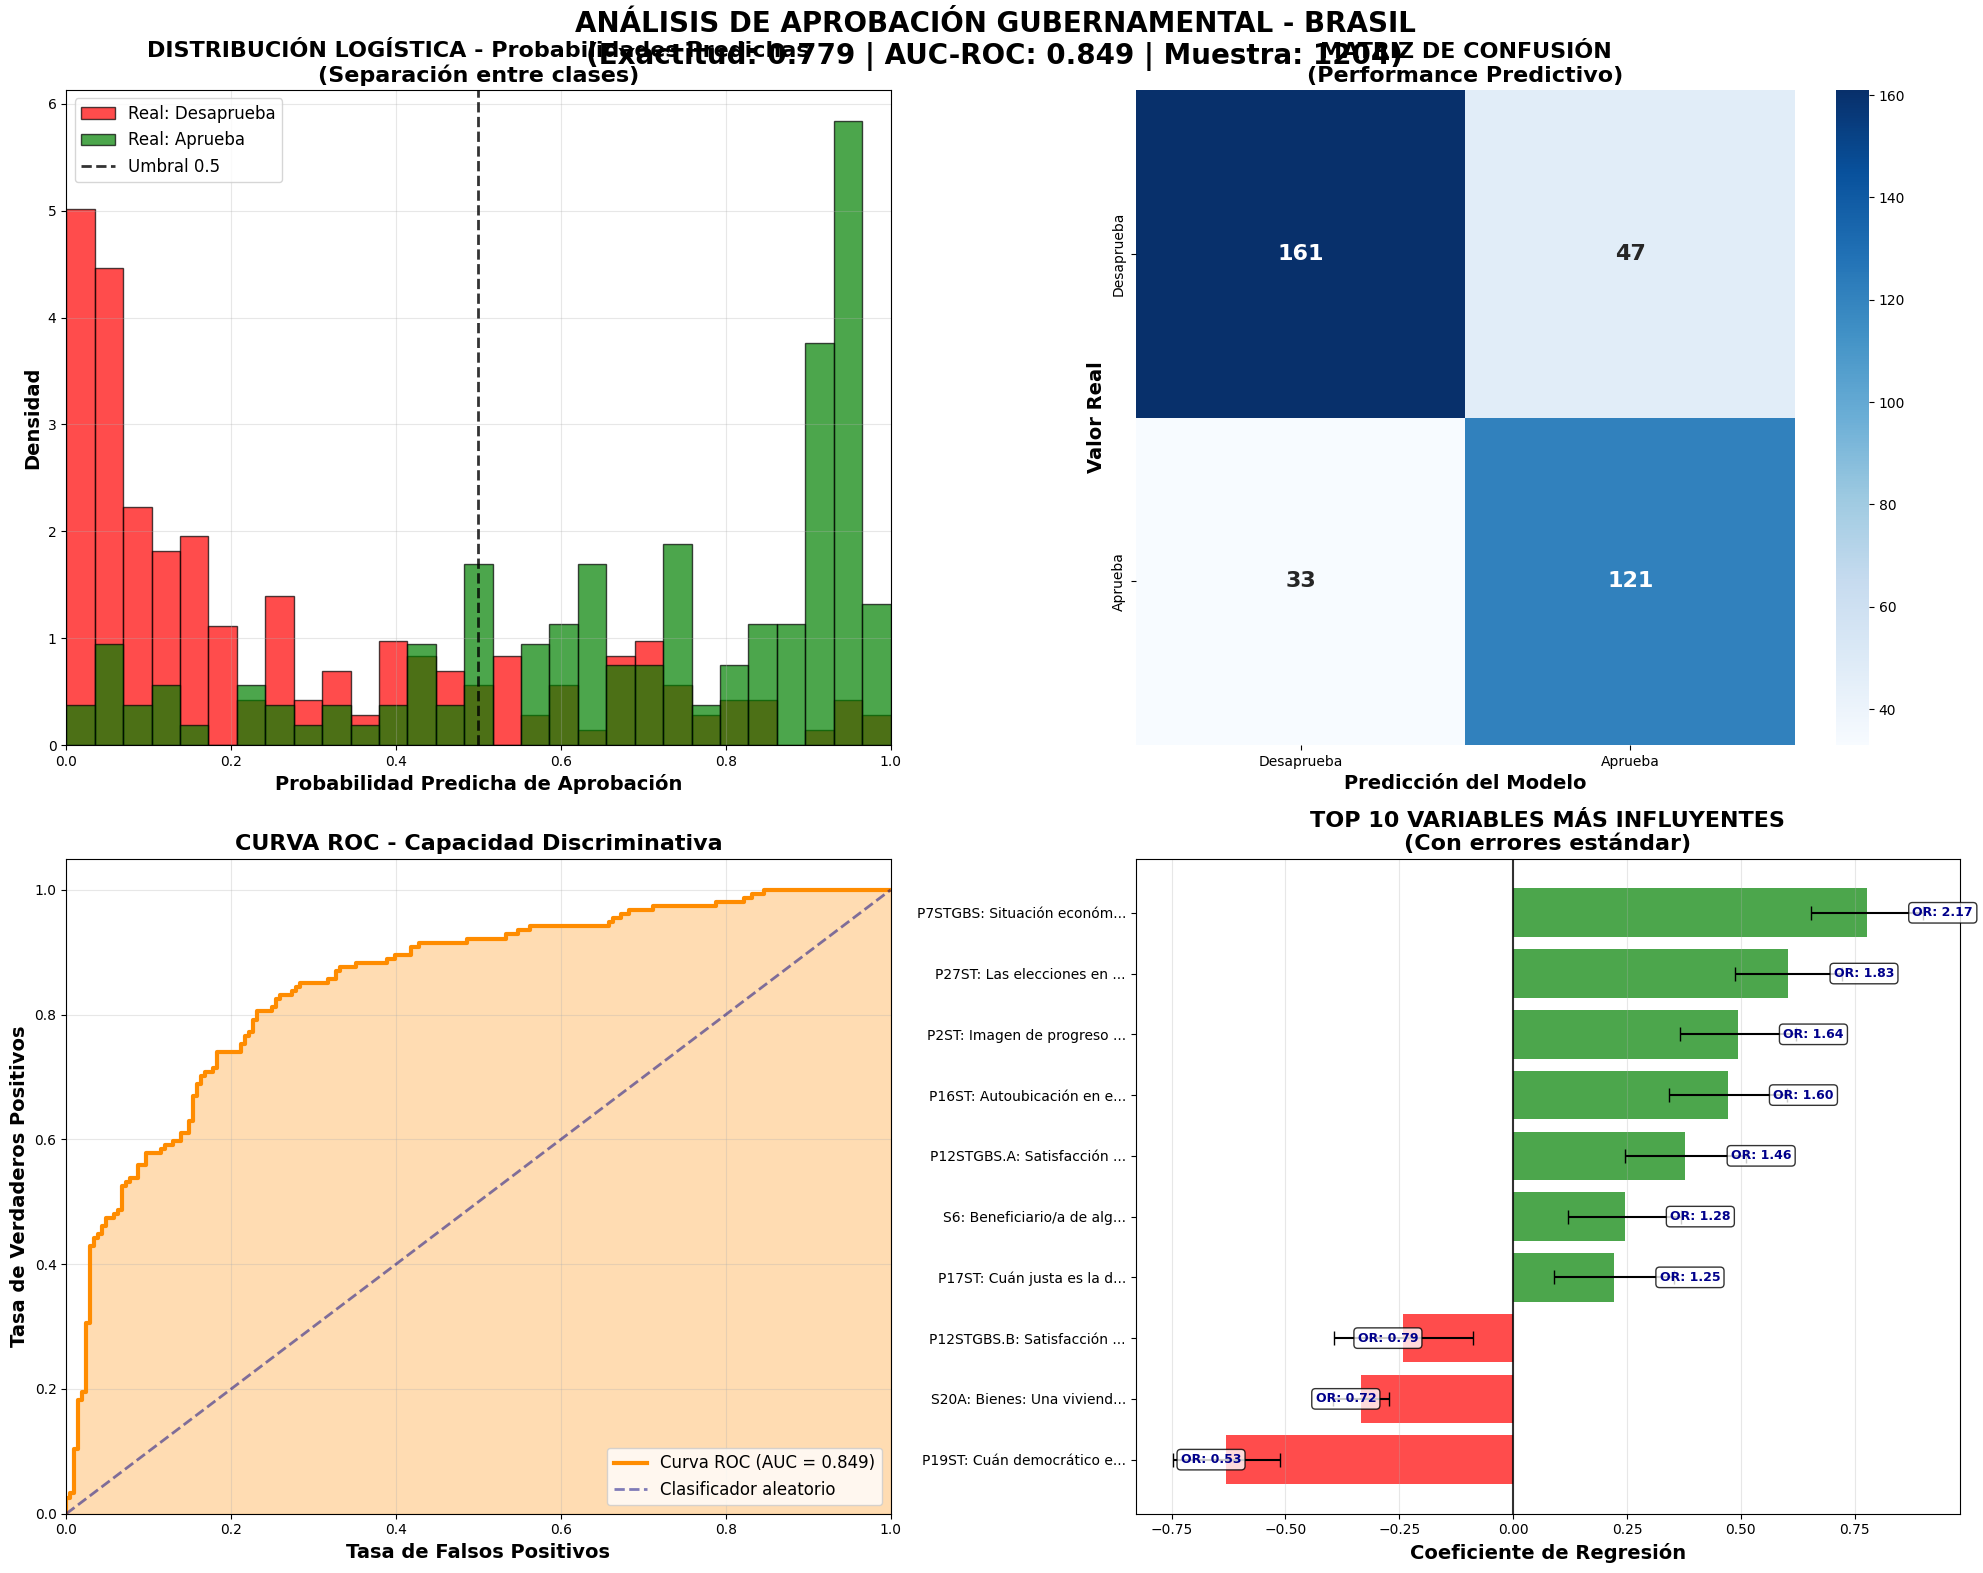


📊 RESUMEN ESTADÍSTICO - BRASIL:
   • Exactitud del modelo: 0.779
   • AUC-ROC: 0.849
   • Tasa de aprobación real: 42.5%
   • Observaciones: 1204

🔝 TOP 5 VARIABLES MÁS IMPORTANTES:
   1. P7STGBS: Situación económica actual del 
      → AUMENTA aprobación en 117.5% (OR: 2.17)
   2. P19ST: Cuán democrático es {PAÍS}. El “1
      → DISMINUYE aprobación en 46.7% (OR: 0.53)
   3. P27ST: Las elecciones en este país son l
      → AUMENTA aprobación en 83.0% (OR: 1.83)
   4. P2ST: Imagen de progreso del país
      → AUMENTA aprobación en 63.7% (OR: 1.64)
   5. P16ST: Autoubicación en escala Izquierda
      → AUMENTA aprobación en 60.2% (OR: 1.60)

🇦🇳 ANÁLISIS COMPLETO PARA: VENEZUELA
📊 Datos para VENEZUELA: 1200 observaciones
✅ Datos finales: 1200 observaciones
🎯 Distribución: 75.3% aprueba, 24.7% desaprueba


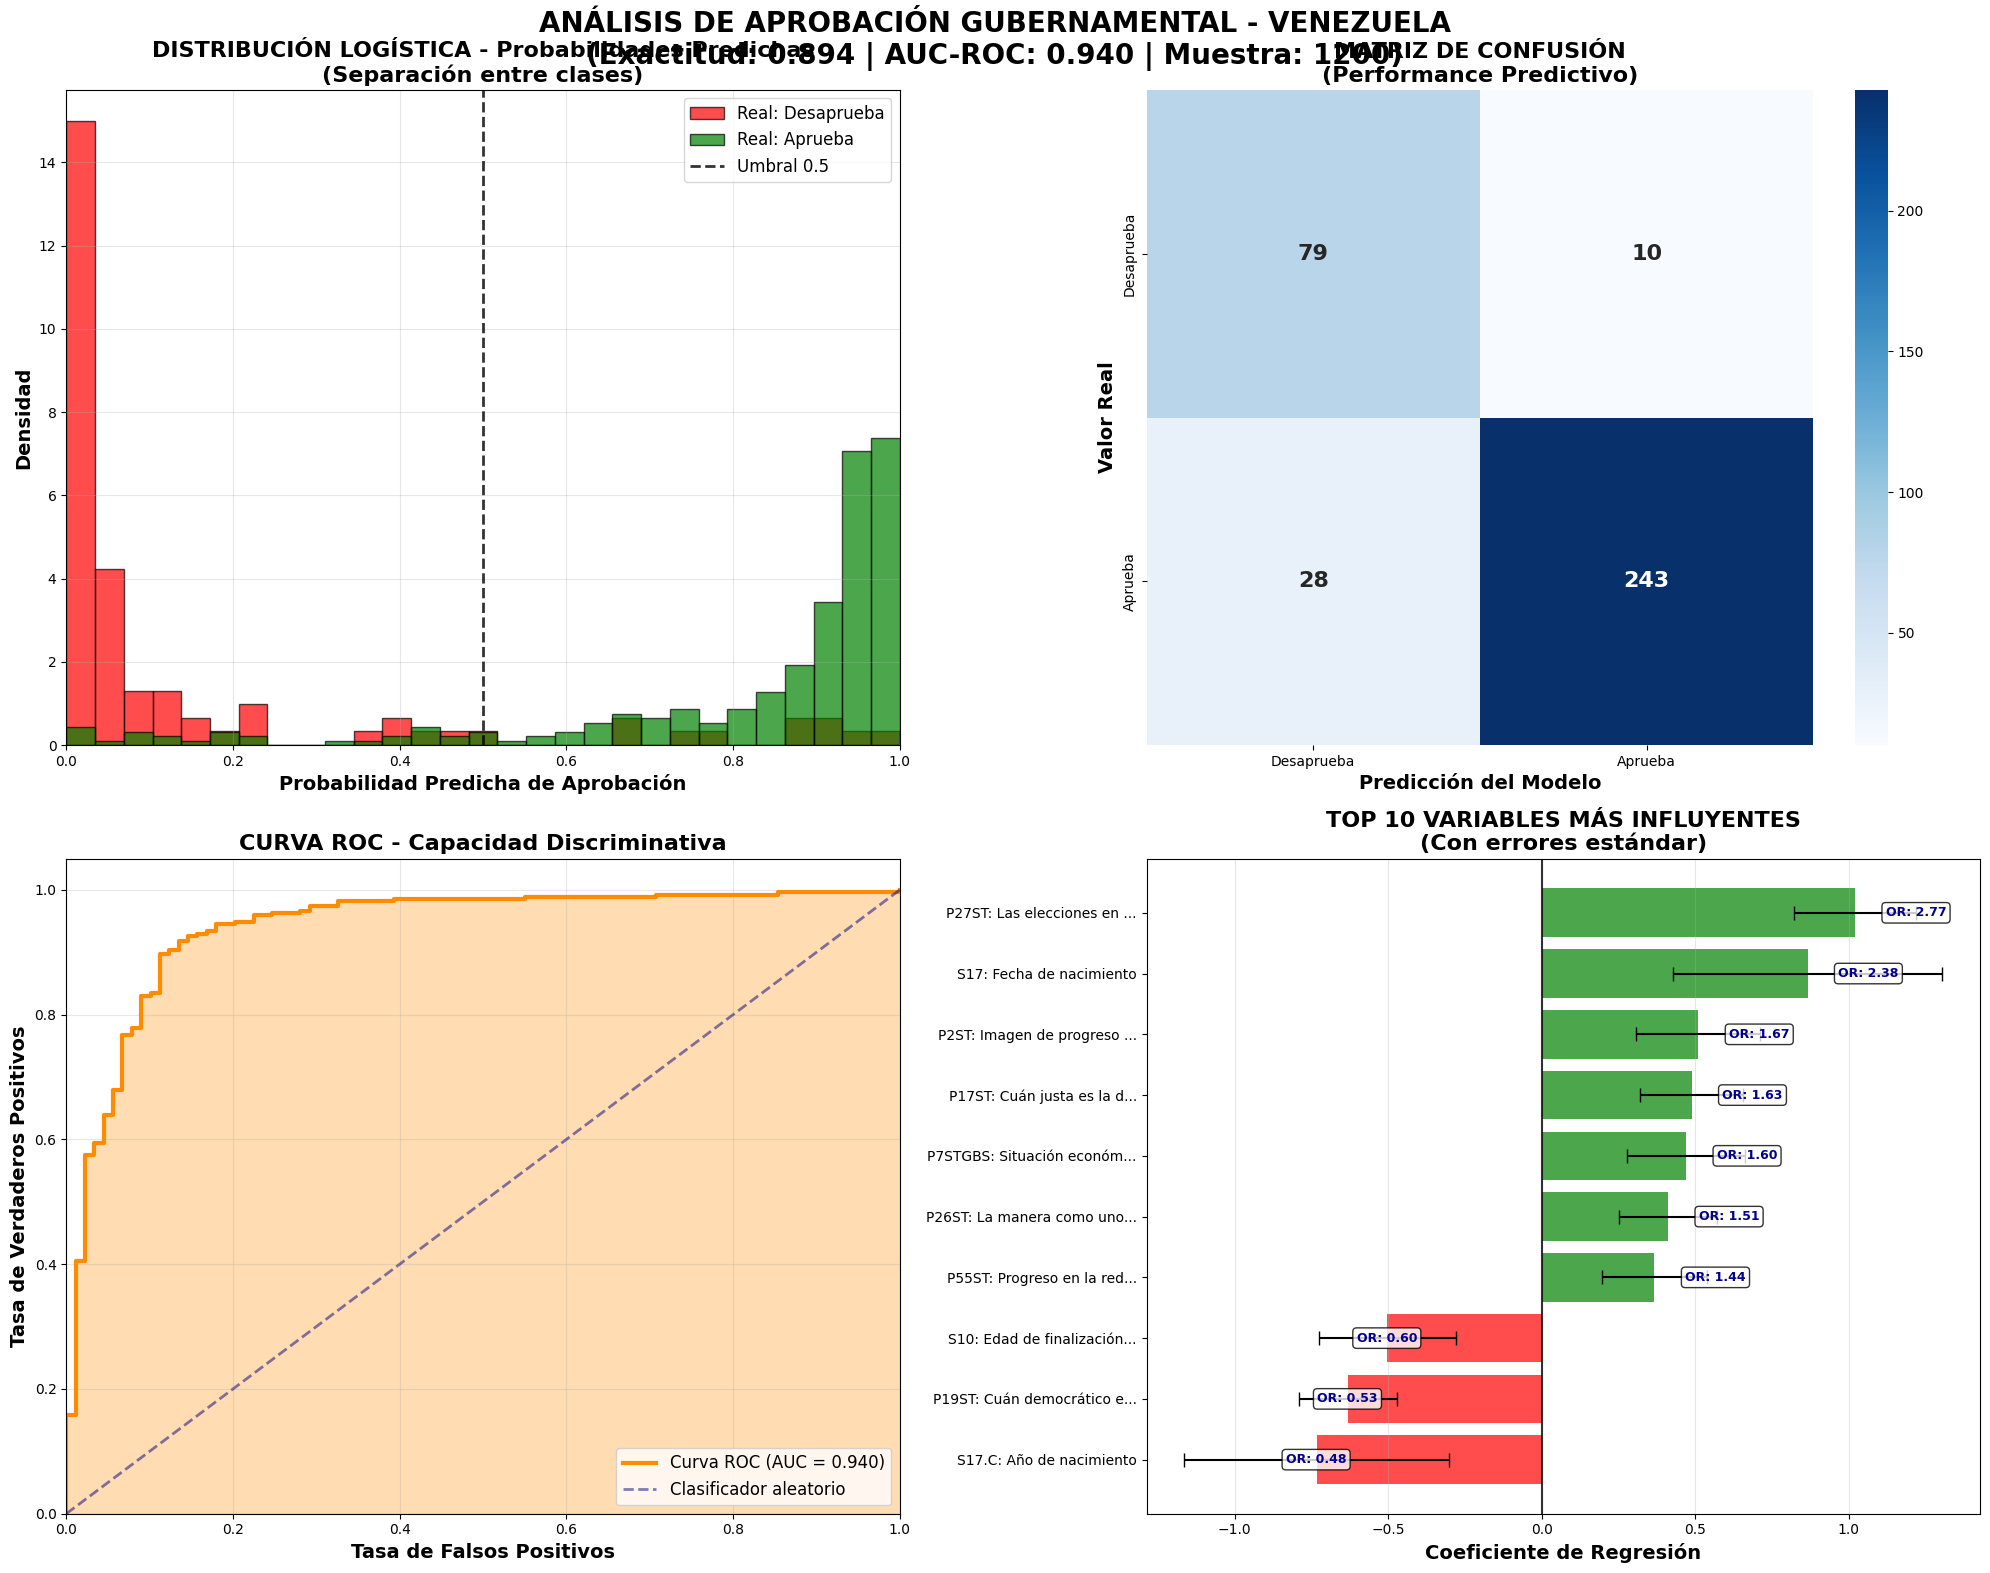


📊 RESUMEN ESTADÍSTICO - VENEZUELA:
   • Exactitud del modelo: 0.894
   • AUC-ROC: 0.940
   • Tasa de aprobación real: 75.3%
   • Observaciones: 1200

🔝 TOP 5 VARIABLES MÁS IMPORTANTES:
   1. P27ST: Las elecciones en este país son l
      → AUMENTA aprobación en 177.4% (OR: 2.77)
   2. S17: Fecha de nacimiento
      → AUMENTA aprobación en 137.7% (OR: 2.38)
   3. S17.C: Año de nacimiento
      → DISMINUYE aprobación en 52.0% (OR: 0.48)
   4. P19ST: Cuán democrático es {PAÍS}. El “1
      → DISMINUYE aprobación en 46.8% (OR: 0.53)
   5. P2ST: Imagen de progreso del país
      → AUMENTA aprobación en 66.5% (OR: 1.67)

📊 GRÁFICO COMPARATIVO FINAL - DISTRIBUCIÓN POR PAÍSES


ConversionError: Failed to convert value(s) to axis units: ['ARGENTINA', 'BRASIL', 'VENEZUELA']

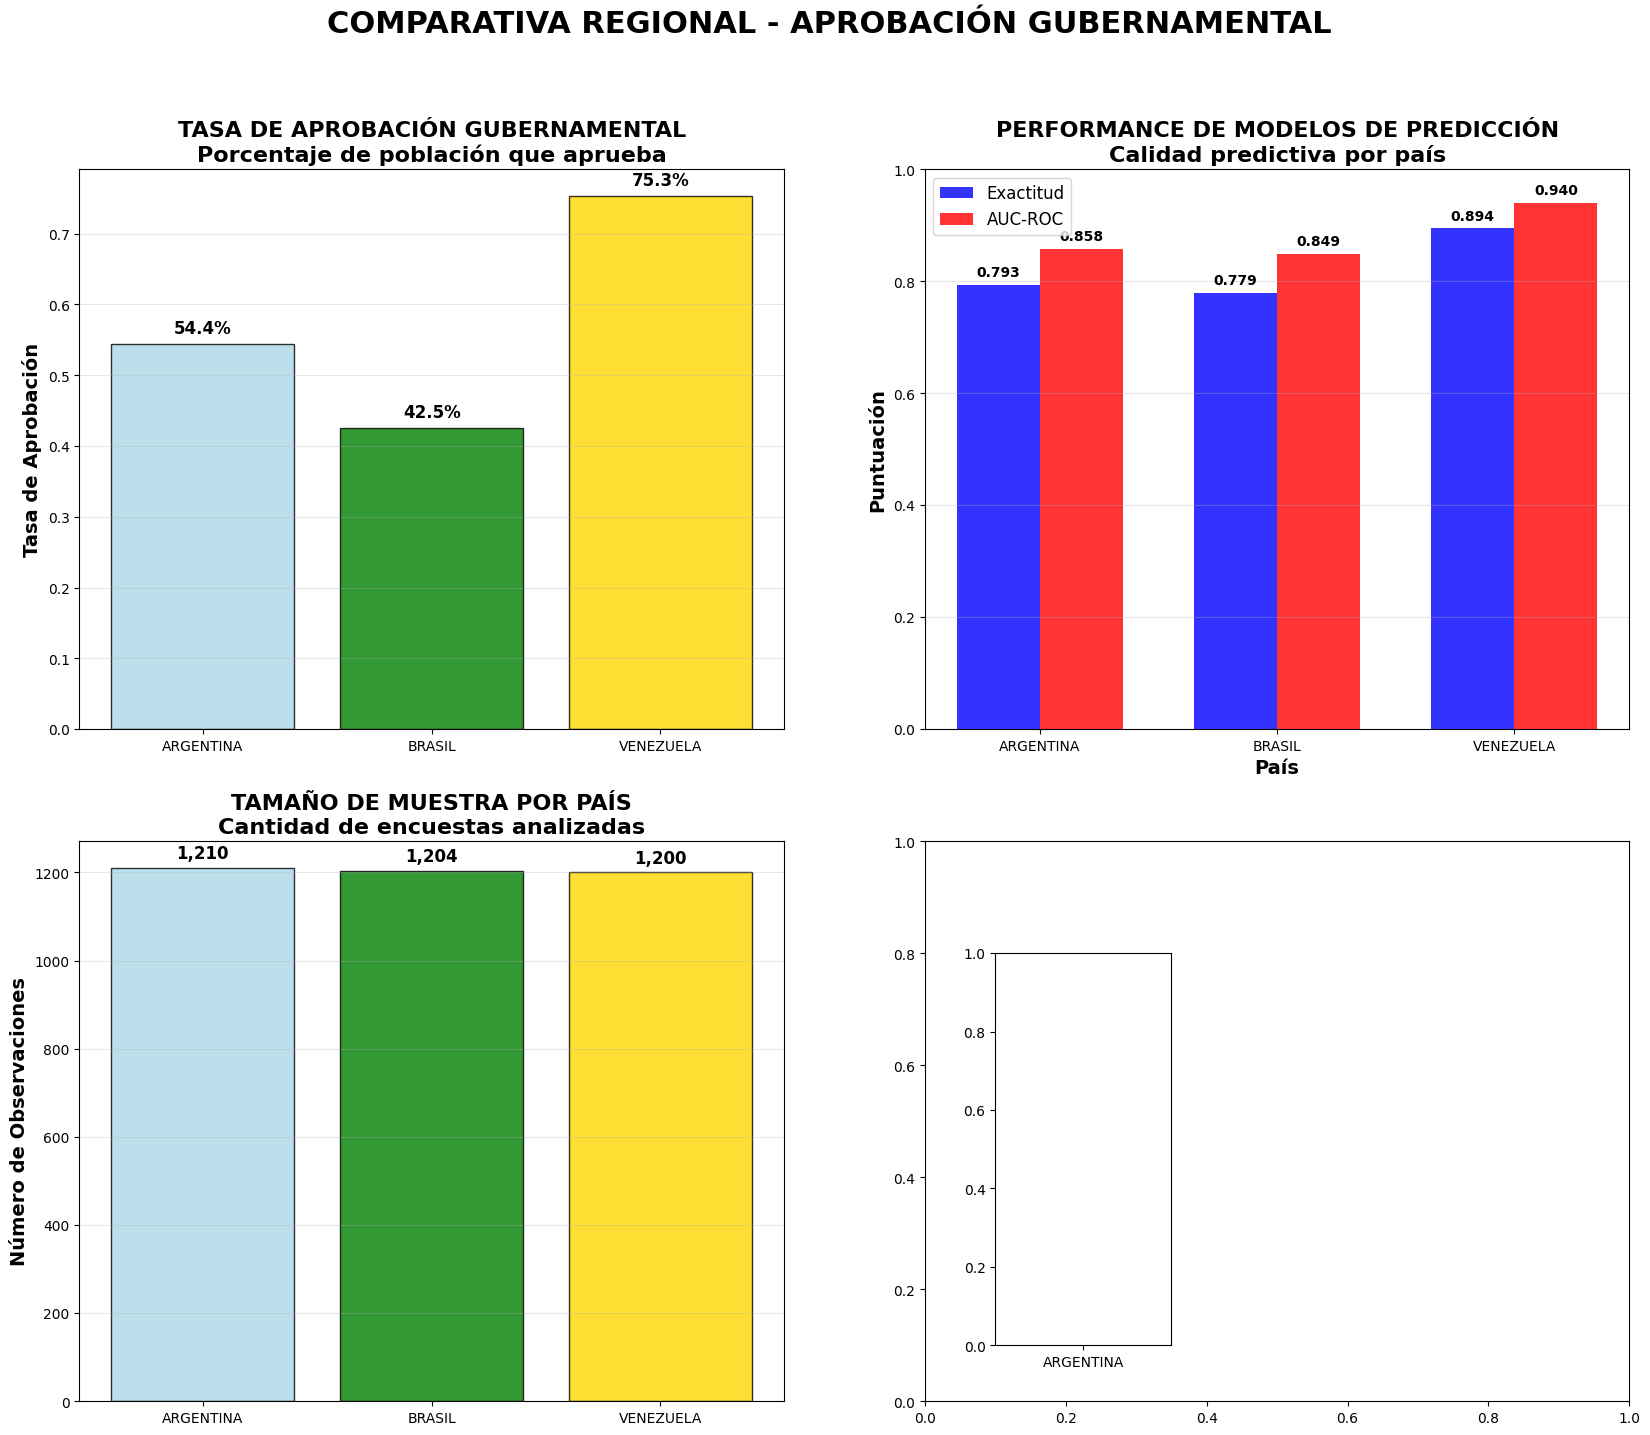

In [15]:
# =============================================================================
# ANÁLISIS INDIVIDUAL POR PAÍS CON VISUALIZACIONES CLARAS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")

# =============================================================================
# 1. CONFIGURACIÓN DE PAÍSES
# =============================================================================

CODIGOS_PAISES = {
    'ARGENTINA': 32,
    'BRASIL': 76,  
    'VENEZUELA': 862
}

print("=" * 70)
print("ANÁLISIS INDIVIDUAL POR PAÍS - VISUALIZACIONES COMPLETAS")
print("=" * 70)

# Cargar datos
df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Df_final1.xlsx')

print(f"📊 Dataset original: {df.shape}")

# =============================================================================
# 2. FUNCIÓN MEJORADA CON VISUALIZACIONES INDIVIDUALES
# =============================================================================

def analizar_pais_completo(nombre_pais, codigo_pais, df_completo):
    """Función para analizar un país específico con visualizaciones completas"""
    
    print(f"\n{'='*70}")
    print(f"🇦🇳 ANÁLISIS COMPLETO PARA: {nombre_pais.upper()}")
    print(f"{'='*70}")
    
    # Filtrar datos del país
    df_pais = df_completo[df_completo['IDENPA: País'] == codigo_pais].copy()
    
    if len(df_pais) == 0:
        print(f"❌ No hay datos para {nombre_pais}")
        return None
    
    print(f"📊 Datos para {nombre_pais}: {df_pais.shape[0]} observaciones")
    
    # Variable dependiente e independientes
    y_col = 'P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente'
    y = df_pais[y_col]
    X = df_pais.drop([y_col, 'IDENPA: País'], axis=1, errors='ignore')
    
    # Limpieza básica
    special_codes = [97, 98, 99]
    X_clean = X.replace(special_codes, np.nan)
    y_clean = y.replace(special_codes, np.nan)
    
    # Filtrar filas válidas
    mask = ~y_clean.isna()
    X_filtered = X_clean[mask]
    y_filtered = y_clean[mask]
    
    if len(X_filtered) == 0:
        print(f"❌ No hay datos válidos para {nombre_pais}")
        return None
    
    # Imputar missing values
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_filtered)
    X_imputed = pd.DataFrame(X_imputed, columns=X_filtered.columns, index=X_filtered.index)
    
    # Variable dependiente binaria
    y_binary = y_filtered.astype(int)
    
    print(f"✅ Datos finales: {X_imputed.shape[0]} observaciones")
    print(f"🎯 Distribución: {y_binary.mean()*100:.1f}% aprueba, { (1-y_binary.mean())*100:.1f}% desaprueba")
    
    if len(X_imputed) < 50:
        print(f"❌ Muy pocos datos para análisis confiable")
        return None
    
    # =============================================================================
    # ENTRENAMIENTO DEL MODELO
    # =============================================================================
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y_binary, test_size=0.3, random_state=42, stratify=y_binary
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    model.fit(X_train_scaled, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # =============================================================================
    # VISUALIZACIONES INDIVIDUALES POR PAÍS
    # =============================================================================
    
    # Crear figura con 4 subplots para cada país
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle(f'ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - {nombre_pais.upper()}\n'
                f'(Exactitud: {accuracy:.3f} | AUC-ROC: {roc_auc:.3f} | Muestra: {len(X_imputed)})', 
                fontsize=20, fontweight='bold', y=0.98)
    
    # =============================================================================
    # Gráfico 1: DISTRIBUCIÓN LOGÍSTICA - Probabilidades predichas
    # =============================================================================
    
    # Crear distribución de probabilidades
    prob_bins = np.linspace(0, 1, 30)
    
    # Histograma de probabilidades para cada clase
    axes[0,0].hist(y_pred_proba[y_test == 0], bins=prob_bins, alpha=0.7, 
                   label='Real: Desaprueba', color='red', density=True, edgecolor='black')
    axes[0,0].hist(y_pred_proba[y_test == 1], bins=prob_bins, alpha=0.7, 
                   label='Real: Aprueba', color='green', density=True, edgecolor='black')
    
    # Línea de distribución logística teórica
    x_logit = np.linspace(0, 1, 100)
    axes[0,0].axvline(x=0.5, color='black', linestyle='--', alpha=0.8, linewidth=2, label='Umbral 0.5')
    
    axes[0,0].set_xlabel('Probabilidad Predicha de Aprobación', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('Densidad', fontsize=14, fontweight='bold')
    axes[0,0].set_title('DISTRIBUCIÓN LOGÍSTICA - Probabilidades Predichas\n(Separación entre clases)', 
                       fontsize=16, fontweight='bold')
    axes[0,0].legend(fontsize=12)
    axes[0,0].grid(alpha=0.3)
    axes[0,0].set_xlim(0, 1)
    
    # =============================================================================
    # Gráfico 2: MATRIZ DE CONFUSIÓN
    # =============================================================================
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
                xticklabels=['Desaprueba', 'Aprueba'], 
                yticklabels=['Desaprueba', 'Aprueba'],
                annot_kws={'fontsize': 16, 'fontweight': 'bold'})
    
    axes[0,1].set_xlabel('Predicción del Modelo', fontsize=14, fontweight='bold')
    axes[0,1].set_ylabel('Valor Real', fontsize=14, fontweight='bold')
    axes[0,1].set_title('MATRIZ DE CONFUSIÓN\n(Performance Predictivo)', 
                       fontsize=16, fontweight='bold')
    
    # =============================================================================
    # Gráfico 3: CURVA ROC
    # =============================================================================
    
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    axes[1,0].plot(fpr, tpr, color='darkorange', lw=3, 
                   label=f'Curva ROC (AUC = {roc_auc:.3f})')
    axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5, 
                   label='Clasificador aleatorio')
    axes[1,0].fill_between(fpr, tpr, alpha=0.3, color='darkorange')
    
    axes[1,0].set_xlim([0.0, 1.0])
    axes[1,0].set_ylim([0.0, 1.05])
    axes[1,0].set_xlabel('Tasa de Falsos Positivos', fontsize=14, fontweight='bold')
    axes[1,0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=14, fontweight='bold')
    axes[1,0].set_title('CURVA ROC - Capacidad Discriminativa', 
                       fontsize=16, fontweight='bold')
    axes[1,0].legend(loc="lower right", fontsize=12)
    axes[1,0].grid(alpha=0.3)
    
    # =============================================================================
    # Gráfico 4: TOP 10 VARIABLES MÁS IMPORTANTES
    # =============================================================================
    
    # Bootstrap para errores estándar
    n_bootstrap = 100
    bootstrap_coefs = []
    
    for i in range(n_bootstrap):
        indices = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
        X_boot = X_train_scaled[indices]
        y_boot = y_train.iloc[indices]
        
        model_boot = LogisticRegression(random_state=42+i, max_iter=1000, class_weight='balanced')
        model_boot.fit(X_boot, y_boot)
        bootstrap_coefs.append(model_boot.coef_[0])
    
    bootstrap_coefs = np.array(bootstrap_coefs)
    std_errors = np.std(bootstrap_coefs, axis=0)
    
    # Calcular Odds Ratios
    odds_ratios = np.exp(model.coef_[0])
    
    # Crear dataframe de resultados
    results = pd.DataFrame({
        'Variable': X_imputed.columns,
        'Coeficiente': model.coef_[0],
        'Error_Estándar': std_errors,
        'Odds_Ratio': odds_ratios
    })
    
    # Ordenar por importancia absoluta
    results['Importancia_Abs'] = np.abs(results['Coeficiente'])
    results = results.sort_values('Importancia_Abs', ascending=False)
    
    # Tomar top 10 variables
    top_10 = results.head(10).sort_values('Coeficiente', ascending=True)
    
    # Gráfico de barras horizontales
    colors = ['red' if coef < 0 else 'green' for coef in top_10['Coeficiente']]
    y_pos = range(len(top_10))
    
    bars = axes[1,1].barh(y_pos, top_10['Coeficiente'], color=colors, alpha=0.7, 
                         xerr=top_10['Error_Estándar'], capsize=5)
    
    axes[1,1].axvline(x=0, color='black', linestyle='-', alpha=0.8)
    axes[1,1].set_yticks(y_pos)
    axes[1,1].set_yticklabels([f"{var[:25]}..." if len(var) > 25 else var for var in top_10['Variable']], 
                             fontsize=10)
    axes[1,1].set_xlabel('Coeficiente de Regresión', fontsize=14, fontweight='bold')
    axes[1,1].set_title('TOP 10 VARIABLES MÁS INFLUYENTES\n(Con errores estándar)', 
                       fontsize=16, fontweight='bold')
    axes[1,1].grid(axis='x', alpha=0.3)
    
    # Añadir valores de Odds Ratio
    for i, (_, row) in enumerate(top_10.iterrows()):
        axes[1,1].text(row['Coeficiente'] + (0.1 if row['Coeficiente'] > 0 else -0.1), 
                      i, f'OR: {row["Odds_Ratio"]:.2f}', 
                      va='center', fontsize=9, fontweight='bold',
                      color='darkblue', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()
    
    # =============================================================================
    # RESUMEN NUMÉRICO
    # =============================================================================
    
    print(f"\n📊 RESUMEN ESTADÍSTICO - {nombre_pais.upper()}:")
    print(f"   • Exactitud del modelo: {accuracy:.3f}")
    print(f"   • AUC-ROC: {roc_auc:.3f}")
    print(f"   • Tasa de aprobación real: {y_binary.mean()*100:.1f}%")
    print(f"   • Observaciones: {len(X_imputed)}")
    
    print(f"\n🔝 TOP 5 VARIABLES MÁS IMPORTANTES:")
    top_5 = results.head(5)
    for i, (_, row) in enumerate(top_5.iterrows(), 1):
        efecto = "AUMENTA" if row['Coeficiente'] > 0 else "DISMINUYE"
        magnitud = f"{((row['Odds_Ratio']-1)*100):.1f}%" if row['Odds_Ratio'] > 1 else f"{((1-row['Odds_Ratio'])*100):.1f}%"
        print(f"   {i}. {row['Variable'][:40]}")
        print(f"      → {efecto} aprobación en {magnitud} (OR: {row['Odds_Ratio']:.2f})")
    
    return {
        'nombre_pais': nombre_pais,
        'df_resultados': results,
        'accuracy': accuracy,
        'auc_roc': roc_auc,
        'tasa_aprobacion': y_binary.mean(),
        'n_observaciones': len(X_imputed),
        'modelo': model
    }

# =============================================================================
# 3. EJECUTAR ANÁLISIS PARA CADA PAÍS
# =============================================================================

resultados_paises = {}

for nombre_pais, codigo in CODIGOS_PAISES.items():
    resultado = analizar_pais_completo(nombre_pais, codigo, df)
    if resultado is not None:
        resultados_paises[nombre_pais] = resultado

# =============================================================================
# 4. GRÁFICO COMPARATIVO FINAL - DISTRIBUCIÓN DE PAÍSES
# =============================================================================

if len(resultados_paises) > 0:
    print(f"\n{'='*70}")
    print("📊 GRÁFICO COMPARATIVO FINAL - DISTRIBUCIÓN POR PAÍSES")
    print(f"{'='*70}")
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('COMPARATIVA REGIONAL - APROBACIÓN GUBERNAMENTAL', 
                 fontsize=22, fontweight='bold', y=0.98)
    
    # Datos para gráficos comparativos
    paises = list(resultados_paises.keys())
    tasas_aprobacion = [datos['tasa_aprobacion'] for datos in resultados_paises.values()]
    accuracy_scores = [datos['accuracy'] for datos in resultados_paises.values()]
    auc_scores = [datos['auc_roc'] for datos in resultados_paises.values()]
    n_observaciones = [datos['n_observaciones'] for datos in resultados_paises.values()]
    
    # Colores por país
    colores = ['lightblue', 'green', 'gold']
    
    # =============================================================================
    # Gráfico 1: TASAS DE APROBACIÓN POR PAÍS
    # =============================================================================
    
    bars1 = axes[0,0].bar(paises, tasas_aprobacion, color=colores, alpha=0.8, edgecolor='black')
    axes[0,0].set_ylabel('Tasa de Aprobación', fontsize=14, fontweight='bold')
    axes[0,0].set_title('TASA DE APROBACIÓN GUBERNAMENTAL\nPorcentaje de población que aprueba', 
                       fontsize=16, fontweight='bold')
    axes[0,0].grid(axis='y', alpha=0.3)
    
    # Añadir porcentajes
    for bar, tasa in zip(bars1, tasas_aprobacion):
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{tasa*100:.1f}%', ha='center', va='bottom', 
                      fontweight='bold', fontsize=12)
    
    # =============================================================================
    # Gráfico 2: PERFORMANCE DE MODELOS
    # =============================================================================
    
    x = np.arange(len(paises))
    width = 0.35
    
    bars2a = axes[0,1].bar(x - width/2, accuracy_scores, width, label='Exactitud', 
                          alpha=0.8, color='blue')
    bars2b = axes[0,1].bar(x + width/2, auc_scores, width, label='AUC-ROC', 
                          alpha=0.8, color='red')
    
    axes[0,1].set_xlabel('País', fontsize=14, fontweight='bold')
    axes[0,1].set_ylabel('Puntuación', fontsize=14, fontweight='bold')
    axes[0,1].set_title('PERFORMANCE DE MODELOS DE PREDICCIÓN\nCalidad predictiva por país', 
                       fontsize=16, fontweight='bold')
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(paises)
    axes[0,1].legend(fontsize=12)
    axes[0,1].grid(axis='y', alpha=0.3)
    axes[0,1].set_ylim(0, 1)
    
    # Añadir valores
    for bar in bars2a:
        height = bar.get_height()
        axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{height:.3f}', ha='center', va='bottom', fontweight='bold')
    
    for bar in bars2b:
        height = bar.get_height()
        axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{height:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # =============================================================================
    # Gráfico 3: MUESTRA POR PAÍS
    # =============================================================================
    
    bars3 = axes[1,0].bar(paises, n_observaciones, color=colores, alpha=0.8, edgecolor='black')
    axes[1,0].set_ylabel('Número de Observaciones', fontsize=14, fontweight='bold')
    axes[1,0].set_title('TAMAÑO DE MUESTRA POR PAÍS\nCantidad de encuestas analizadas', 
                       fontsize=16, fontweight='bold')
    axes[1,0].grid(axis='y', alpha=0.3)
    
    # Añadir valores
    for bar, n in zip(bars3, n_observaciones):
        height = bar.get_height()
        axes[1,0].text(bar.get_x() + bar.get_width()/2., height + max(n_observaciones)*0.01,
                      f'{n:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # =============================================================================
    # Gráfico 4: COMPARATIVA DE FACTORES CLAVE
    # =============================================================================
    
    # Encontrar variables comunes más importantes
    variables_comunes = {}
    for pais, datos in resultados_paises.items():
        top_vars = datos['df_resultados'].head(5)['Variable'].tolist()
        for var in top_vars:
            if var not in variables_comunes:
                variables_comunes[var] = []
            variables_comunes[var].append(pais)
    
    # Seleccionar variables que aparecen en múltiples países
    vars_comparar = [var for var, paises in variables_comunes.items() if len(paises) >= 2]
    
    if vars_comparar:
        # Tomar las 3 variables más frecuentes
        vars_comparar = vars_comparar[:3]
        
        for i, var in enumerate(vars_comparar):
            coefs = []
            paises_var = []
            for pais in paises:
                if pais in resultados_paises:
                    df_pais = resultados_paises[pais]['df_resultados']
                    if var in df_pais['Variable'].values:
                        coef = df_pais[df_pais['Variable'] == var]['Coeficiente'].values[0]
                        coefs.append(coef)
                        paises_var.append(pais)
            
            if len(coefs) > 1:
                # Gráfico pequeño dentro del subplot
                left = 0.1 + (i * 0.3)
                bottom = 0.1
                width = 0.25
                height = 0.7
                
                ax_inset = axes[1,1].inset_axes([left, bottom, width, height])
                
                colors_inset = ['red' if c < 0 else 'green' for c in coefs]
                ax_inset.bar(paises_var, coefs, color=colors_inset, alpha=0.7)
                ax_inset.axhline(y=0, color='black', linestyle='-', alpha=0.5)
                ax_inset.set_title(f'{var[:20]}...', fontsize=10, fontweight='bold')
                ax_inset.tick_params(axis='x', rotation=45, labelsize=8)
                ax_inset.grid(axis='y', alpha=0.3)
        
        axes[1,1].set_title('COMPARATIVA DE COEFICIENTES\nVariables comunes entre países', 
                           fontsize=16, fontweight='bold')
    else:
        axes[1,1].text(0.5, 0.5, 'No hay suficientes variables\ncomunes para comparar', 
                      ha='center', va='center', transform=axes[1,1].transAxes, 
                      fontsize=14, fontweight='bold')
        axes[1,1].set_title('COMPARATIVA DE VARIABLES COMUNES', 
                           fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()
    
    # =============================================================================
    # RESUMEN COMPARATIVO
    # =============================================================================
    
    print(f"\n{'='*70}")
    print("🎯 RESUMEN COMPARATIVO REGIONAL")
    print(f"{'='*70}")
    
    for pais, datos in resultados_paises.items():
        print(f"\n📋 {pais.upper()}:")
        print(f"   • Aprobación: {datos['tasa_aprobacion']*100:.1f}%")
        print(f"   • Calidad predictiva: {datos['accuracy']:.3f} (Exactitud)")
        print(f"   • Capacidad discriminativa: {datos['auc_roc']:.3f} (AUC-ROC)")
        print(f"   • Muestra analizada: {datos['n_observaciones']} encuestas")

# =============================================================================
# 5. EXPORTAR RESULTADOS
# =============================================================================

for pais, datos in resultados_paises.items():
    archivo = f"resultados_detallados_{pais.lower()}.csv"
    datos['df_resultados'].to_csv(archivo, index=False, encoding='utf-8-sig')
    print(f"💾 Resultados detallados de {pais} guardados en: {archivo}")

---

# Elastic Net = L1 + L2 

REGRESIÓN LOGÍSTICA: ELASTIC NET, LASSO Y RIDGE
📊 Datos finales: (12014, 51)
🎯 Distribución: Aprobación 63.1%

ENTRENAMIENTO DE MODELOS

🔄 Entrenando Elastic Net...
   ✅ Elastic Net entrenado - AUC: 0.849

🔄 Entrenando Lasso (L1)...
   ✅ Lasso (L1) entrenado - AUC: 0.849

🔄 Entrenando Ridge (L2)...
   ✅ Ridge (L2) entrenado - AUC: 0.849

COMPARACIÓN DE MODELOS
        Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Accuracy  \
0  Elastic Net     0.776      0.832   0.808      0.82    0.849        0.773   
1   Lasso (L1)     0.776      0.833   0.808      0.82    0.849        0.772   
2   Ridge (L2)     0.776      0.832   0.808      0.82    0.849        0.773   

   CV Std  
0   0.006  
1   0.006  
2   0.006  

GENERANDO VISUALIZACIONES
📈 Generando Curvas ROC...
📊 Generando Comparación de Métricas...
🔝 Generando Importancia de Variables...
📋 Generando Coeficientes Comparativos...

ANÁLISIS DETALLADO POR MODELO

🎯 Elastic Net:
   • ROC-AUC: 0.849
   • F1-Score: 0.820
   • Valida

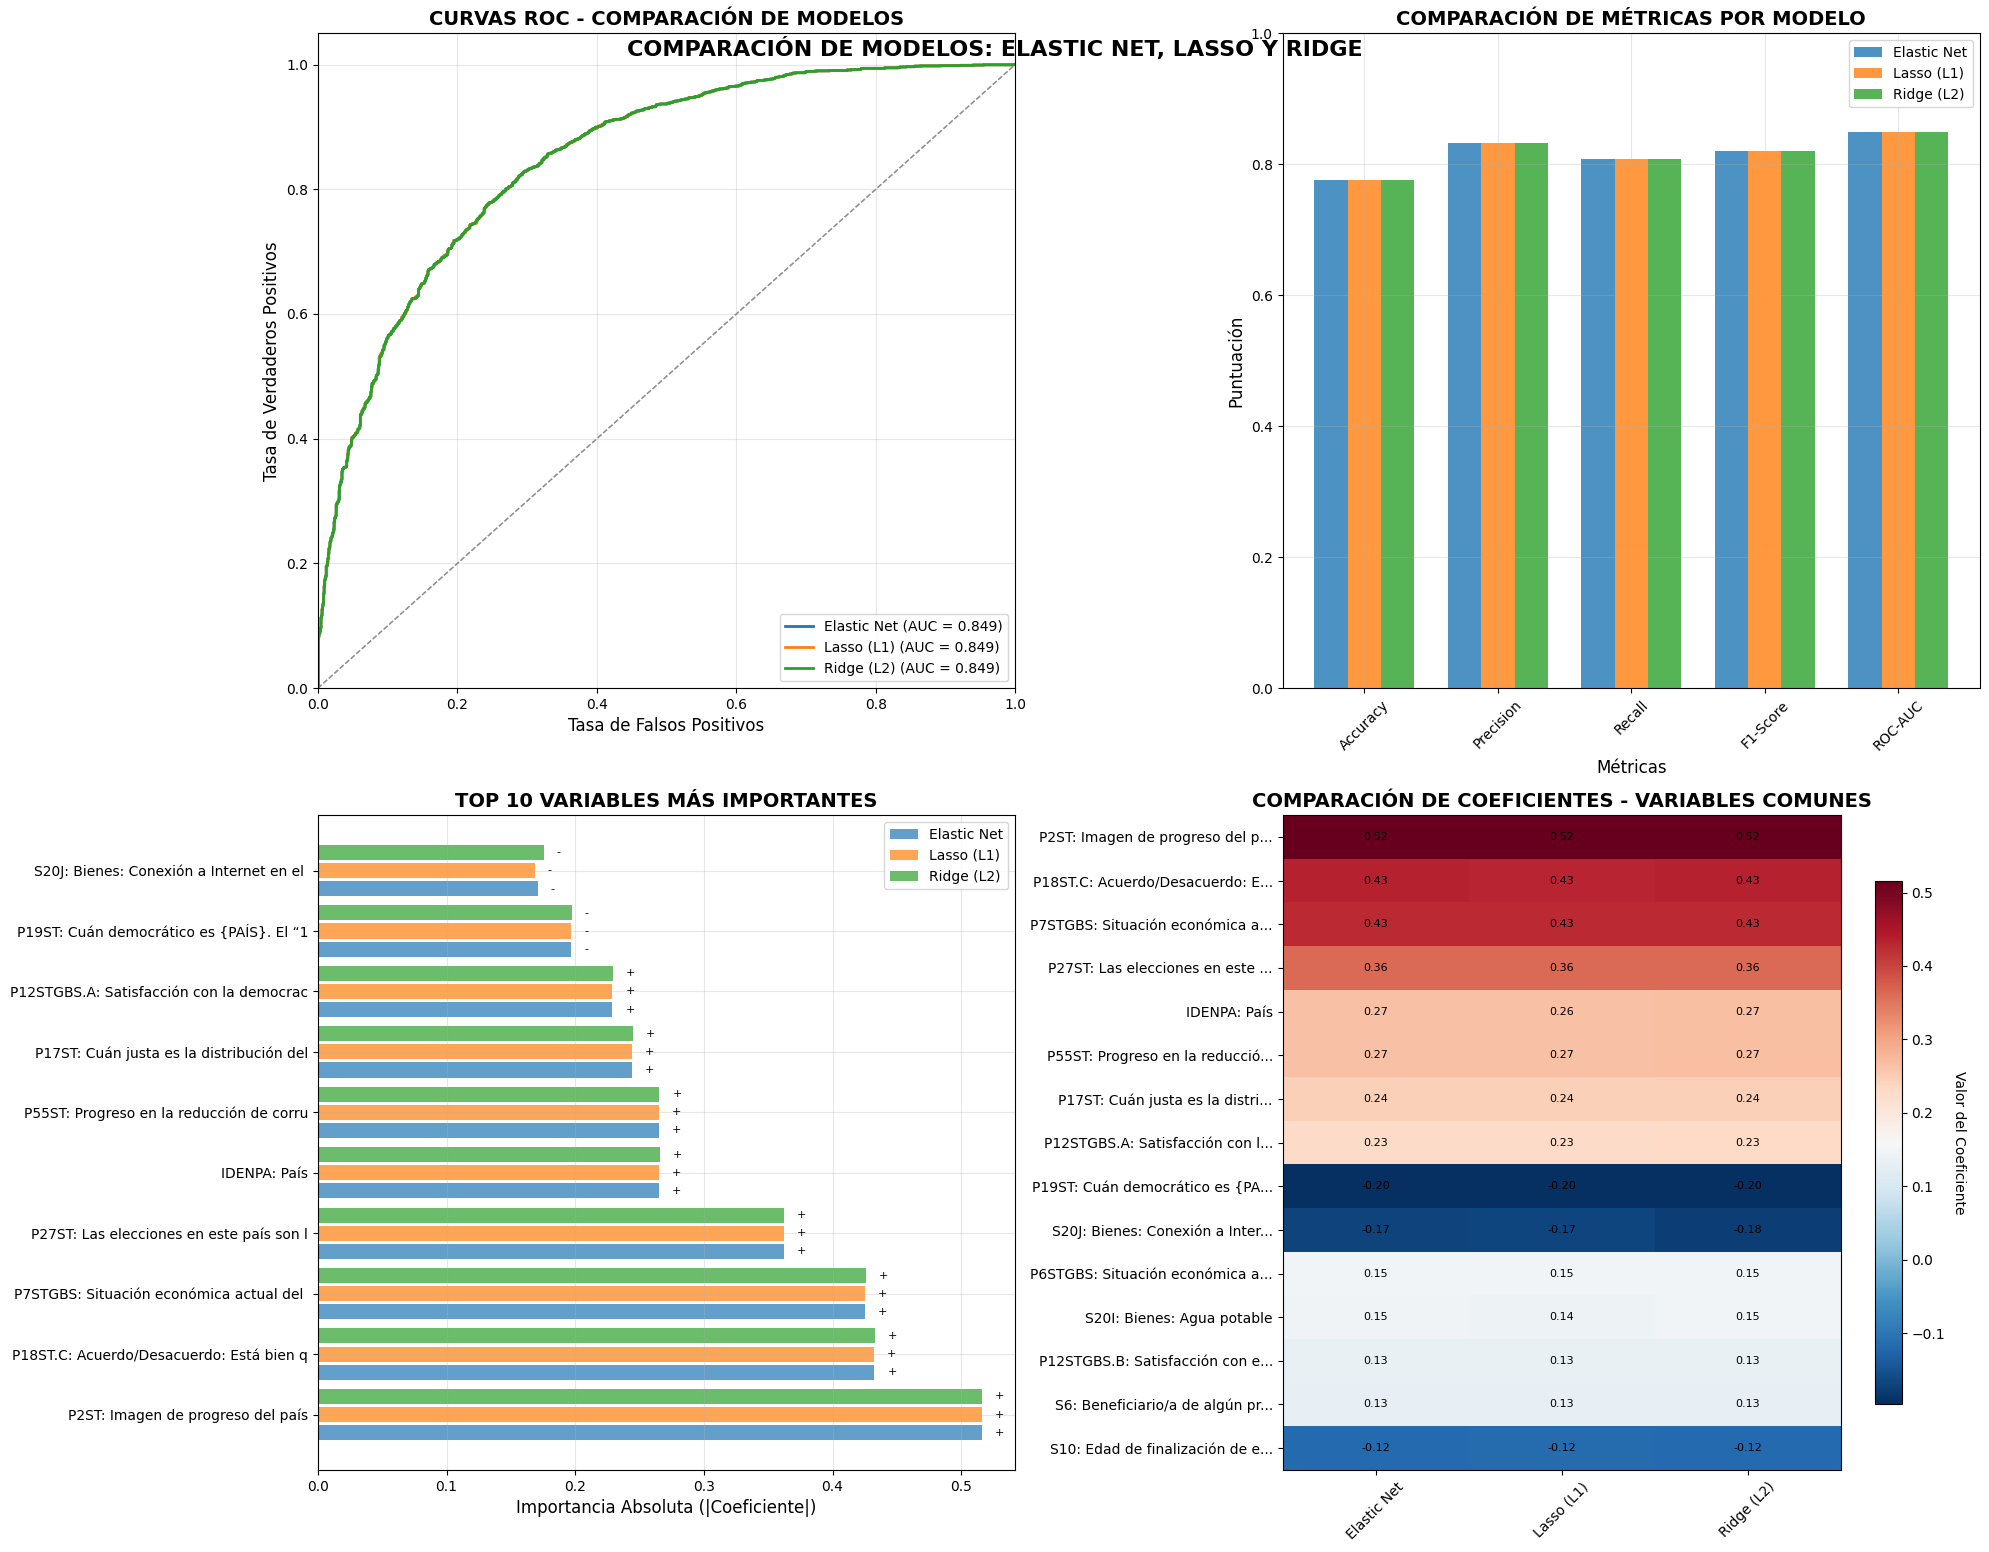


✅ Visualizaciones guardadas como 'comparacion_modelos_regularizacion.png'
🎯 Análisis completado exitosamente!


In [ ]:
# =============================================================================
# REGRESIÓN LOGÍSTICA - ELASTIC NET, LASSO Y RIDGE (CORREGIDO)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# =============================================================================
# 1. PREPARACIÓN DE DATOS
# =============================================================================

print("=" * 70)
print("REGRESIÓN LOGÍSTICA: ELASTIC NET, LASSO Y RIDGE")
print("=" * 70)

# Cargar datos
df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Df_final1.xlsx')

# Variable dependiente
y_col = 'P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente'
y = df[y_col]
X = df.drop(y_col, axis=1)

# Limpieza
special_codes = [97, 98, 99]
X_clean = X.replace(special_codes, np.nan)
y_clean = y.replace(special_codes, np.nan)

# Filtrar y imputar
mask = ~y_clean.isna()
X_filtered = X_clean[mask]
y_filtered = y_clean[mask]

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_filtered)
X_imputed = pd.DataFrame(X_imputed, columns=X_filtered.columns, index=X_filtered.index)

y_binary = y_filtered.astype(int)

print(f"📊 Datos finales: {X_imputed.shape}")
print(f"🎯 Distribución: Aprobación {(y_binary.mean() * 100):.1f}%")

# =============================================================================
# 2. DIVISIÓN Y ESCALADO
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================================================================
# 3. MODELOS: ELASTIC NET, LASSO Y RIDGE
# =============================================================================

print("\n" + "=" * 70)
print("ENTRENAMIENTO DE MODELOS")
print("=" * 70)

# Configuración de modelos
models = {
    'Elastic Net': LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=1.0,
        l1_ratio=0.5,
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ),
    'Lasso (L1)': LogisticRegression(
        penalty='l1',
        solver='saga',
        C=1.0,
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ),
    'Ridge (L2)': LogisticRegression(
        penalty='l2',
        C=1.0,
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )
}

# Entrenar modelos y almacenar resultados
results = {}
feature_importances = {}

for name, model in models.items():
    print(f"\n🔄 Entrenando {name}...")
    
    if name == 'Elastic Net':
        model.set_params(l1_ratio=0.5)
    
    model.fit(X_train_scaled, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Validación cruzada
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    # Almacenar resultados
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred_proba': y_pred_proba
    }
    
    # Importancia de características
    if hasattr(model, 'coef_'):
        feature_importances[name] = pd.DataFrame({
            'Variable': X_imputed.columns,
            'Coeficiente': model.coef_[0],
            'Abs_Coeficiente': np.abs(model.coef_[0])
        }).sort_values('Abs_Coeficiente', ascending=False)
    
    print(f"   ✅ {name} entrenado - AUC: {roc_auc:.3f}")

# =============================================================================
# 4. COMPARACIÓN DE MÉTRICAS
# =============================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN DE MODELOS")
print("=" * 70)

# Crear DataFrame comparativo
comparison_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'Precision': [results[name]['precision'] for name in results.keys()],
    'Recall': [results[name]['recall'] for name in results.keys()],
    'F1-Score': [results[name]['f1'] for name in results.keys()],
    'ROC-AUC': [results[name]['roc_auc'] for name in results.keys()],
    'CV Accuracy': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
})

print(comparison_df.round(3))

# =============================================================================
# 5. VISUALIZACIONES CORREGIDAS
# =============================================================================

print("\n" + "=" * 70)
print("GENERANDO VISUALIZACIONES")
print("=" * 70)

# Crear figura con 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('COMPARACIÓN DE MODELOS: ELASTIC NET, LASSO Y RIDGE', 
             fontsize=16, fontweight='bold', y=0.95)

# =============================================================================
# VISUALIZACIÓN 1: CURVAS ROC COMPARATIVAS
# =============================================================================

print("📈 Generando Curvas ROC...")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    y_pred_proba = results[name]['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = results[name]['roc_auc']
    
    axes[0, 0].plot(fpr, tpr, color=color, lw=2, 
                   label=f'{name} (AUC = {roc_auc:.3f})')
    axes[0, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.5)

axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('Tasa de Falsos Positivos', fontsize=12)
axes[0, 0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
axes[0, 0].set_title('CURVAS ROC - COMPARACIÓN DE MODELOS', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(True, alpha=0.3)

# =============================================================================
# VISUALIZACIÓN 2: COMPARACIÓN DE MÉTRICAS (CORREGIDO)
# =============================================================================

print("📊 Generando Comparación de Métricas...")

# DEFINIR MÉTRICAS CORRECTAMENTE - usar las claves exactas de results
metrics_config = [
    ('accuracy', 'Accuracy'),
    ('precision', 'Precision'), 
    ('recall', 'Recall'),
    ('f1', 'F1-Score'),
    ('roc_auc', 'ROC-AUC')
]

x_pos = np.arange(len(metrics_config))
width = 0.25

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    # Usar las claves correctas de results
    metric_values = [results[name][metric_key] for metric_key, _ in metrics_config]
    axes[0, 1].bar(x_pos + i*width, metric_values, width, 
                  label=name, color=color, alpha=0.8)

axes[0, 1].set_xlabel('Métricas', fontsize=12)
axes[0, 1].set_ylabel('Puntuación', fontsize=12)
axes[0, 1].set_title('COMPARACIÓN DE MÉTRICAS POR MODELO', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x_pos + width)
axes[0, 1].set_xticklabels([label for _, label in metrics_config], rotation=45)
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, alpha=0.3)

# =============================================================================
# VISUALIZACIÓN 3: IMPORTANCIA DE VARIABLES (TOP 10 POR MODELO)
# =============================================================================

print("🔝 Generando Importancia de Variables...")

top_n = 10

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    if name in feature_importances:
        top_features = feature_importances[name].head(top_n)
        
        y_pos = np.arange(len(top_features))
        axes[1, 0].barh(y_pos + i*0.3, top_features['Abs_Coeficiente'], 
                        height=0.25, color=color, alpha=0.7, label=name)
        
        # Añadir etiquetas con el signo del coeficiente
        for j, (idx, row) in enumerate(top_features.iterrows()):
            sign = '+' if row['Coeficiente'] > 0 else '-'
            axes[1, 0].text(row['Abs_Coeficiente'] + 0.01, j + i*0.3, 
                           f"{sign}", va='center', fontsize=8)

# Configurar el gráfico de importancia
if feature_importances:
    first_model = list(feature_importances.keys())[0]
    top_features = feature_importances[first_model].head(top_n)
    axes[1, 0].set_yticks(np.arange(top_n) + 0.3)
    axes[1, 0].set_yticklabels(top_features['Variable'].str[:40])
    axes[1, 0].set_xlabel('Importancia Absoluta (|Coeficiente|)', fontsize=12)
    axes[1, 0].set_title('TOP 10 VARIABLES MÁS IMPORTANTES', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# =============================================================================
# VISUALIZACIÓN 4: COEFICIENTES COMPARATIVOS (VARIABLES COMUNES)
# =============================================================================

print("📋 Generando Coeficientes Comparativos...")

# Encontrar variables comunes importantes
if feature_importances:
    all_coefs = []
    for name in feature_importances.keys():
        top_vars = feature_importances[name].head(15)['Variable'].tolist()
        all_coefs.extend(top_vars)
    
    from collections import Counter
    common_vars = [var for var, count in Counter(all_coefs).most_common(15)]
    
    # Crear heatmap de coeficientes
    coef_matrix = []
    for var in common_vars:
        row = []
        for name in results.keys():
            if name in feature_importances:
                coef_data = feature_importances[name]
                matching_rows = coef_data[coef_data['Variable'] == var]
                if len(matching_rows) > 0:
                    row.append(matching_rows['Coeficiente'].values[0])
                else:
                    row.append(0)
            else:
                row.append(0)
        coef_matrix.append(row)
    
    coef_matrix = np.array(coef_matrix)
    
    # Heatmap
    if len(coef_matrix) > 0:
        im = axes[1, 1].imshow(coef_matrix, cmap='RdBu_r', aspect='auto')
        
        # Configurar ejes
        axes[1, 1].set_xticks(range(len(results.keys())))
        axes[1, 1].set_xticklabels(results.keys(), rotation=45)
        axes[1, 1].set_yticks(range(len(common_vars)))
        axes[1, 1].set_yticklabels([var[:30] + '...' if len(var) > 30 else var for var in common_vars])
        
        # Añadir valores en las celdas
        for i in range(len(common_vars)):
            for j in range(len(results.keys())):
                text = axes[1, 1].text(j, i, f'{coef_matrix[i, j]:.2f}',
                                      ha="center", va="center", color="black", fontsize=8)
        
        axes[1, 1].set_title('COMPARACIÓN DE COEFICIENTES - VARIABLES COMUNES', 
                            fontsize=14, fontweight='bold')
        
        # Añadir colorbar
        cbar = plt.colorbar(im, ax=axes[1, 1], shrink=0.8)
        cbar.set_label('Valor del Coeficiente', rotation=270, labelpad=15)

# Si no hay feature_importances, ocultar este subplot
else:
    axes[1, 1].set_visible(False)

# =============================================================================
# 6. ANÁLISIS DETALLADO Y CONCLUSIONES
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS DETALLADO POR MODELO")
print("=" * 70)

for name in results.keys():
    print(f"\n🎯 {name}:")
    print(f"   • ROC-AUC: {results[name]['roc_auc']:.3f}")
    print(f"   • F1-Score: {results[name]['f1']:.3f}")
    print(f"   • Validación Cruzada: {results[name]['cv_mean']:.3f} ± {results[name]['cv_std']:.3f}")
    
    if name in feature_importances:
        top_vars = feature_importances[name].head(3)  # Mostrar solo top 3 para brevedad
        print(f"   • Top 3 variables:")
        for _, row in top_vars.iterrows():
            impacto = "AUMENTA aprobación" if row['Coeficiente'] > 0 else "DISMINUYE aprobación"
            print(f"     - {row['Variable'][:40]:40} | {impacto} (coef: {row['Coeficiente']:.3f})")

# Identificar mejor modelo
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]

print("\n" + "=" * 70)
print("CONCLUSIONES Y RECOMENDACIONES")
print("=" * 70)

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"   • ROC-AUC: {best_model['roc_auc']:.3f}")
print(f"   • F1-Score: {best_model['f1']:.3f}")

print(f"\n📊 COMPARATIVA DE REGULARIZACIÓN:")
print(f"   • Elastic Net: Combina ventajas de L1 y L2 - Ideal para datos con ruido")
print(f"   • Lasso (L1): Selecciona variables - Coeficientes exactos a cero")
print(f"   • Ridge (L2): Maneja multicolinealidad - Coeficientes pequeños pero no cero")

print(f"\n💡 RECOMENDACIONES:")
print(f"   1. Usar {best_model_name} para predicciones finales")
print(f"   2. Analizar variables identificadas por Lasso para simplificar el modelo")
print(f"   3. Considerar Elastic Net como balance óptimo en muchos casos")

# Ajustar layout y guardar
plt.tight_layout()
plt.savefig('comparacion_modelos_regularizacion.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Visualizaciones guardadas como 'comparacion_modelos_regularizacion.png'")
print("🎯 Análisis completado exitosamente!")

In [18]:
# =============================================================================
# 3. MODELOS: ELASTIC NET, LASSO Y RIDGE (CON BÚSQUEDA DE REGULARIZACIÓN)
# =============================================================================

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n" + "=" * 70)
print("ENTRENAMIENTO DE MODELOS CON REGULARIZACIÓN AJUSTADA")
print("=" * 70)

# Definir rango de C (inverso de lambda)
param_grid = {'C': np.logspace(-3, 2, 10)}  # de 0.001 a 100

models_base = {
    'Elastic Net': LogisticRegression(
        penalty='elasticnet', solver='saga',
        l1_ratio=0.5, random_state=42,
        max_iter=2000, class_weight='balanced'
    ),
    'Lasso (L1)': LogisticRegression(
        penalty='l1', solver='saga',
        random_state=42, max_iter=2000,
        class_weight='balanced'
    ),
    'Ridge (L2)': LogisticRegression(
        penalty='l2',
        random_state=42, max_iter=2000,
        class_weight='balanced'
    ),
    'Logit (sin penalización)': LogisticRegression(
        penalty=None, solver='lbfgs',
        random_state=42, max_iter=2000,
        class_weight='balanced'
    )
}

results = {}
feature_importances = {}

for name, model in models_base.items():
    print(f"\n🔄 Ajustando {name} con búsqueda de C...")
    
    if model.penalty is not None:
        grid = GridSearchCV(
            model, param_grid, cv=5,
            scoring='roc_auc', n_jobs=-1
        )
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_
        best_C = grid.best_params_['C']
        print(f"   → Mejor C: {best_C:.4f}")
    else:
        # Logit sin penalización
        best_model = model.fit(X_train_scaled, y_train)
        best_C = None
    
    # Predicciones
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'model': best_model,
        'best_C': best_C,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred_proba': y_pred_proba
    }
    
    # Coeficientes
    if hasattr(best_model, 'coef_'):
        feature_importances[name] = pd.DataFrame({
            'Variable': X_imputed.columns,
            'Coeficiente': best_model.coef_[0],
            'Abs_Coeficiente': np.abs(best_model.coef_[0])
        }).sort_values('Abs_Coeficiente', ascending=False)
    
    print(f"   ✅ {name} - ROC-AUC: {roc_auc:.3f}")

print("\n✅ Búsqueda de λ (C) completada con éxito.")



ENTRENAMIENTO DE MODELOS CON REGULARIZACIÓN AJUSTADA

🔄 Ajustando Elastic Net con búsqueda de C...
   → Mejor C: 0.0464
   ✅ Elastic Net - ROC-AUC: 0.850

🔄 Ajustando Lasso (L1) con búsqueda de C...
   → Mejor C: 0.0464
   ✅ Lasso (L1) - ROC-AUC: 0.850

🔄 Ajustando Ridge (L2) con búsqueda de C...
   → Mejor C: 0.0036
   ✅ Ridge (L2) - ROC-AUC: 0.850

🔄 Ajustando Logit (sin penalización) con búsqueda de C...
   ✅ Logit (sin penalización) - ROC-AUC: 0.849

✅ Búsqueda de λ (C) completada con éxito.


In [19]:
for name, model in models_base.items():
    model.set_params(C=0.001)


In [20]:
X_train_scaled[:, 0:5] += X_train_scaled[:, 1:6] * 0.95


In [21]:
np.random.seed(42)
for i in range(20):
    X_imputed[f'noise_{i}'] = np.random.randn(len(X_imputed))


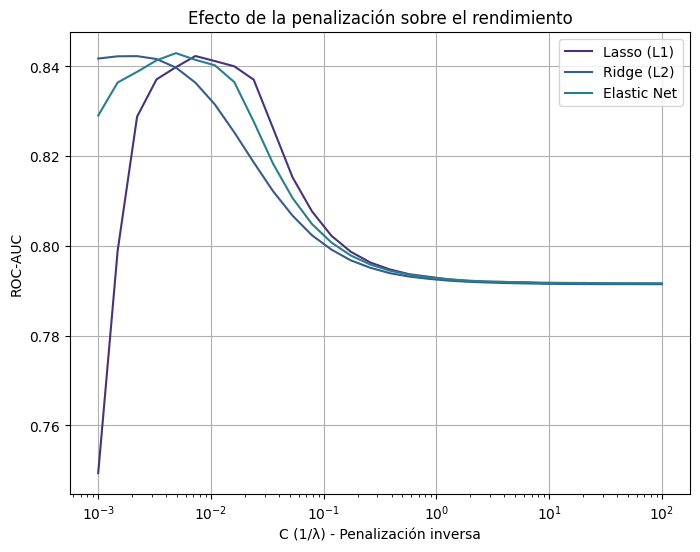

In [22]:
import matplotlib.pyplot as plt
import numpy as np

C_values = np.logspace(-3, 2, 30)
models = {
    "Lasso (L1)": LogisticRegression(penalty='l1', solver='liblinear', max_iter=5000),
    "Ridge (L2)": LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000),
    "Elastic Net": LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=5000)
}

results = {}

for name, model in models.items():
    auc_scores = []
    for C in C_values:
        model.set_params(C=C)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_pred)
        auc_scores.append(auc)
    results[name] = auc_scores

plt.figure(figsize=(8,6))
for name, auc_scores in results.items():
    plt.plot(C_values, auc_scores, label=name)

plt.xscale('log')
plt.xlabel("C (1/λ) - Penalización inversa")
plt.ylabel("ROC-AUC")
plt.title("Efecto de la penalización sobre el rendimiento")
plt.legend()
plt.grid(True)
plt.show()


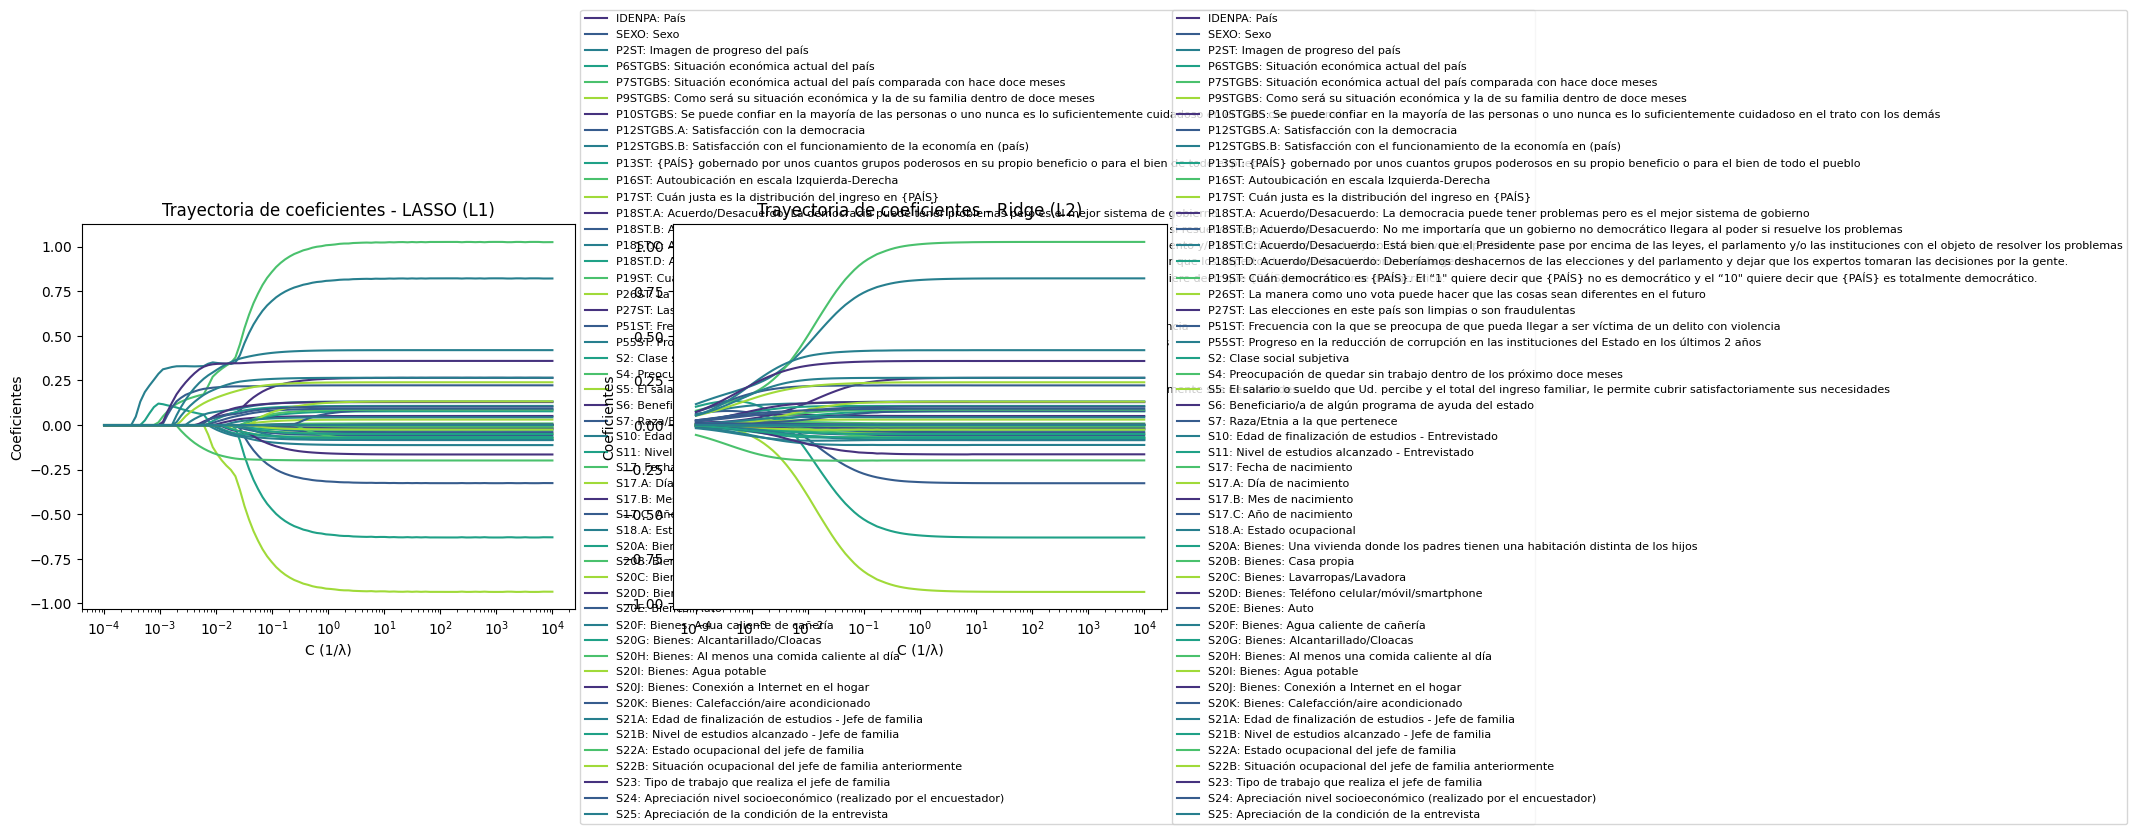

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Supongamos que ya tenés tus datos escalados
# X_train_scaled, y_train

# Definimos el rango de C (inverso de lambda)
C_values = np.logspace(-4, 4, 100)

# Listas para guardar coeficientes
coefs_lasso = []
coefs_ridge = []

# Entrenamos LASSO (L1)
for C in C_values:
    model_lasso = LogisticRegression(
        penalty='l1', solver='liblinear', C=C, max_iter=5000
    )
    model_lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(model_lasso.coef_[0])

# Entrenamos RIDGE (L2)
for C in C_values:
    model_ridge = LogisticRegression(
        penalty='l2', solver='lbfgs', C=C, max_iter=5000
    )
    model_ridge.fit(X_train_scaled, y_train)
    coefs_ridge.append(model_ridge.coef_[0])

# Convertimos a DataFrame
coefs_lasso = pd.DataFrame(coefs_lasso, columns=X_train.columns, index=C_values)
coefs_ridge = pd.DataFrame(coefs_ridge, columns=X_train.columns, index=C_values)

# --- GRAFICAMOS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LASSO
axes[0].set_title("Trayectoria de coeficientes - LASSO (L1)")
axes[0].set_xscale("log")
axes[0].set_xlabel("C (1/λ)")
axes[0].set_ylabel("Coeficientes")
for col in coefs_lasso.columns:
    axes[0].plot(coefs_lasso.index, coefs_lasso[col], label=col)
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# RIDGE
axes[1].set_title("Trayectoria de coeficientes - Ridge (L2)")
axes[1].set_xscale("log")
axes[1].set_xlabel("C (1/λ)")
axes[1].set_ylabel("Coeficientes")
for col in coefs_ridge.columns:
    axes[1].plot(coefs_ridge.index, coefs_ridge[col], label=col)
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()


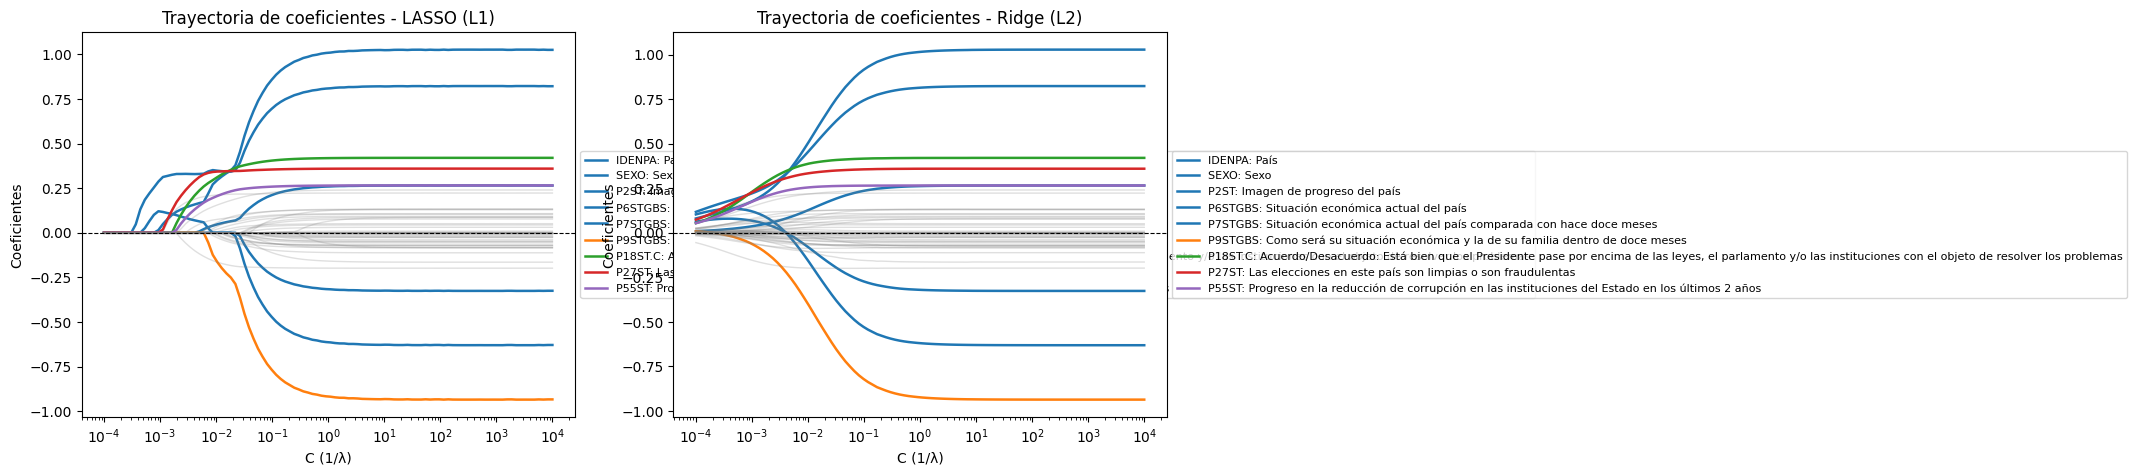

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Supongamos que ya tenés tus datos escalados:
# X_train_scaled, y_train

C_values = np.logspace(-4, 4, 100)

coefs_lasso, coefs_ridge = [], []

# Entrenamos LASSO (L1)
for C in C_values:
    model_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=5000)
    model_lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(model_lasso.coef_[0])

# Entrenamos RIDGE (L2)
for C in C_values:
    model_ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=C, max_iter=5000)
    model_ridge.fit(X_train_scaled, y_train)
    coefs_ridge.append(model_ridge.coef_[0])

# Convertimos a DataFrame
coefs_lasso = pd.DataFrame(coefs_lasso, columns=X_train.columns, index=C_values)
coefs_ridge = pd.DataFrame(coefs_ridge, columns=X_train.columns, index=C_values)

# Umbral de importancia
threshold = 0.25

# --- GRAFICAMOS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Paleta base
colors = plt.cm.tab10(np.linspace(0, 1, len(X_train.columns)))

# Función auxiliar de graficado
def plot_paths(ax, df, title):
    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_xlabel("C (1/λ)")
    ax.set_ylabel("Coeficientes")

    for i, col in enumerate(df.columns):
        max_abs_val = df[col].abs().max()
        if max_abs_val <= threshold:
            # variables poco relevantes: gris, transparentes, sin leyenda
            ax.plot(df.index, df[col], color="gray", alpha=0.25, linewidth=1)
        else:
            # variables relevantes: colores fuertes, visibles en la leyenda
            ax.plot(df.index, df[col], color=colors[i % len(colors)], linewidth=1.8, label=col)

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# LASSO
plot_paths(axes[0], coefs_lasso, "Trayectoria de coeficientes - LASSO (L1)")

# RIDGE
plot_paths(axes[1], coefs_ridge, "Trayectoria de coeficientes - Ridge (L2)")

plt.tight_layout()
plt.show()


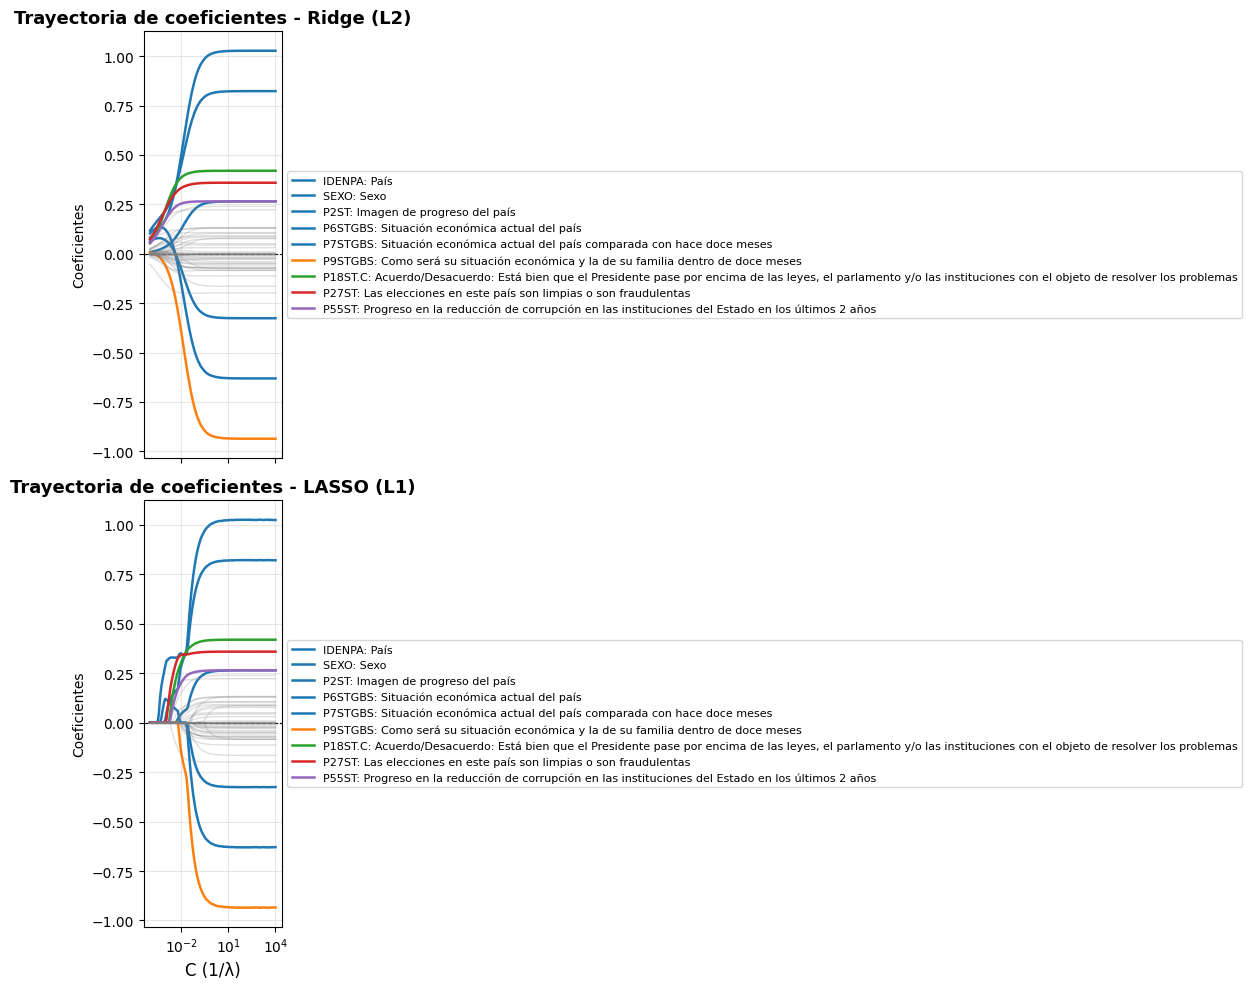

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Supongamos que ya tenés X_train_scaled, y_train definidos
# y que tus columnas son X_train.columns

C_values = np.logspace(-4, 4, 100)

coefs_lasso, coefs_ridge = [], []

# Entrenamos LASSO (L1)
for C in C_values:
    model_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=5000)
    model_lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(model_lasso.coef_[0])

# Entrenamos RIDGE (L2)
for C in C_values:
    model_ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=C, max_iter=5000)
    model_ridge.fit(X_train_scaled, y_train)
    coefs_ridge.append(model_ridge.coef_[0])

# Convertimos a DataFrame
coefs_lasso = pd.DataFrame(coefs_lasso, columns=X_train.columns, index=C_values)
coefs_ridge = pd.DataFrame(coefs_ridge, columns=X_train.columns, index=C_values)

# Umbral de relevancia
threshold = 0.25

# --- GRAFICAMOS ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

colors = plt.cm.tab10(np.linspace(0, 1, len(X_train.columns)))

def plot_paths(ax, df, title):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xscale("log")
    ax.set_ylabel("Coeficientes")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    for i, col in enumerate(df.columns):
        max_abs_val = df[col].abs().max()
        if max_abs_val <= threshold:
            # Variables débiles → gris y transparente
            ax.plot(df.index, df[col], color="gray", alpha=0.25, linewidth=1)
        else:
            # Variables fuertes → color destacado y en leyenda
            ax.plot(df.index, df[col], color=colors[i % len(colors)], linewidth=1.8, label=col)

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    ax.grid(True, alpha=0.3)

# RIDGE arriba
plot_paths(axes[0], coefs_ridge, "Trayectoria de coeficientes - Ridge (L2)")

# LASSO abajo
plot_paths(axes[1], coefs_lasso, "Trayectoria de coeficientes - LASSO (L1)")

axes[1].set_xlabel("C (1/λ)", fontsize=12)

plt.tight_layout()
plt.show()


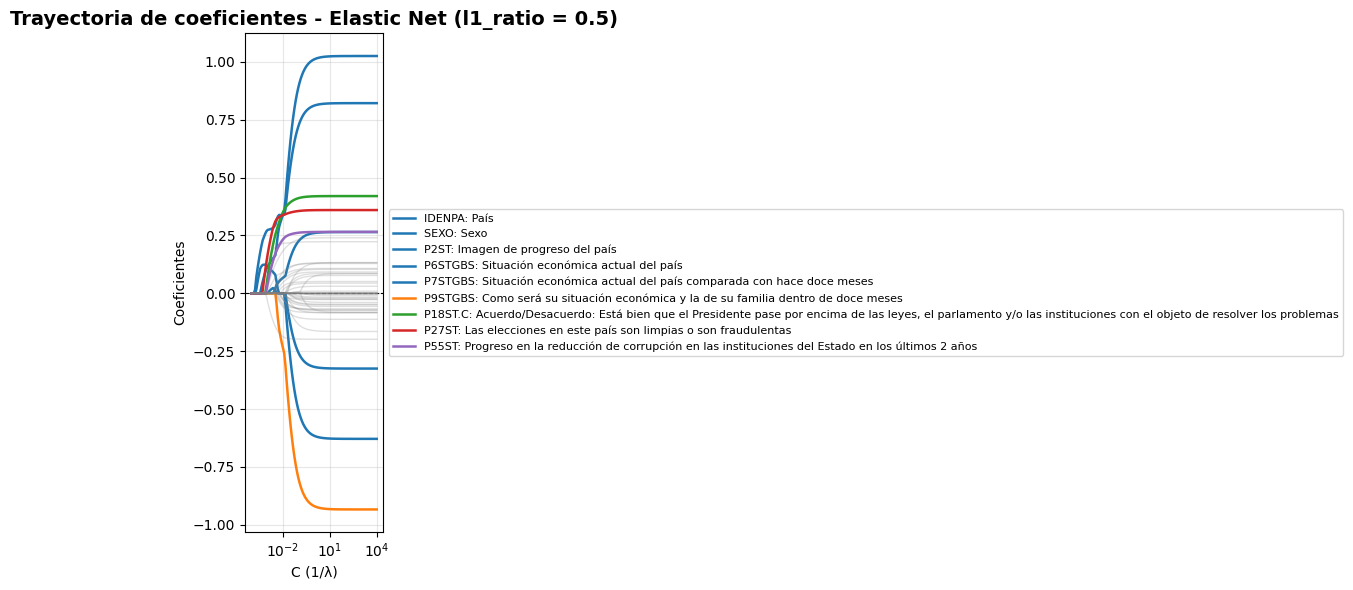

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Supone que ya tenés X_train_scaled, y_train
# y X_train.columns disponibles

C_values = np.logspace(-4, 4, 100)
l1_ratio = 0.5  # mezcla 50% L1 y 50% L2

coefs_elastic = []

# Entrenamos Elastic Net
for C in C_values:
    model_en = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=l1_ratio,
        C=C,
        max_iter=5000
    )
    model_en.fit(X_train_scaled, y_train)
    coefs_elastic.append(model_en.coef_[0])

# Convertimos a DataFrame
coefs_elastic = pd.DataFrame(coefs_elastic, columns=X_train.columns, index=C_values)

# Umbral de relevancia
threshold = 0.25

# --- GRAFICAMOS ---
plt.figure(figsize=(12, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(X_train.columns)))

plt.title(f"Trayectoria de coeficientes - Elastic Net (l1_ratio = {l1_ratio})", fontsize=14, fontweight='bold')
plt.xscale("log")
plt.xlabel("C (1/λ)")
plt.ylabel("Coeficientes")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

for i, col in enumerate(coefs_elastic.columns):
    max_abs_val = coefs_elastic[col].abs().max()
    if max_abs_val <= threshold:
        plt.plot(coefs_elastic.index, coefs_elastic[col], color="gray", alpha=0.25, linewidth=1)
    else:
        plt.plot(coefs_elastic.index, coefs_elastic[col],
                 color=colors[i % len(colors)], linewidth=1.8, label=col)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


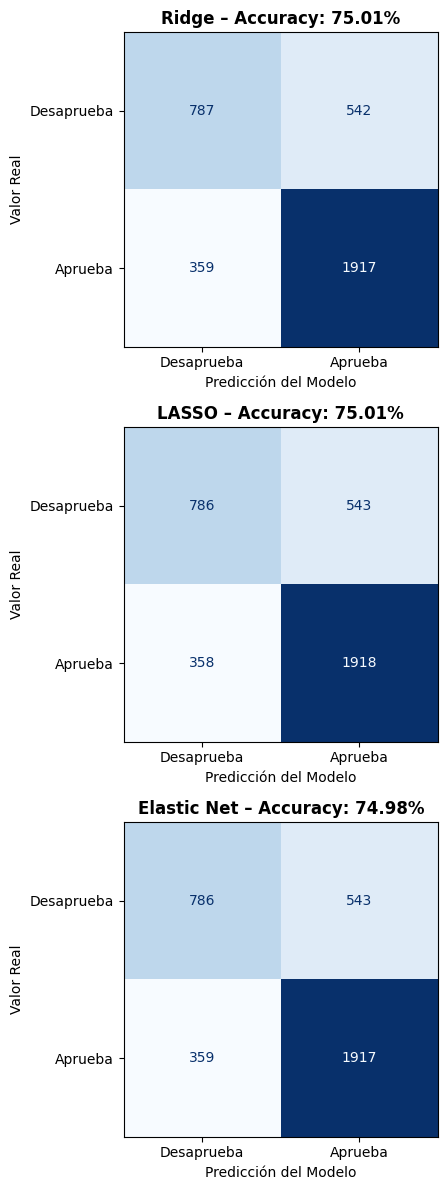

In [27]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Modelos ajustados (ejemplo)
models = {
    'Ridge': LogisticRegression(penalty='l2', solver='saga', C=1, max_iter=5000),
    'LASSO': LogisticRegression(penalty='l1', solver='saga', C=1, max_iter=5000),
    'Elastic Net': LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=1, max_iter=5000)
}

# Entrenamos y evaluamos cada modelo
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    results[name] = {'accuracy': acc, 'confusion_matrix': cm}

# --- GRAFICAMOS ---
fig, axes = plt.subplots(3, 1, figsize=(6, 12))
for ax, (name, res) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(res['confusion_matrix'], display_labels=['Desaprueba', 'Aprueba'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"{name} – Accuracy: {res['accuracy']:.2%}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicción del Modelo")
    ax.set_ylabel("Valor Real")

plt.tight_layout()
plt.show()


TRAYECTORIAS ELASTIC NET POR PAÍS
📊 Dataset original: (12014, 52)

PROCESANDO: ARGENTINA

🎯 GENERANDO TRAYECTORIAS ELASTIC NET PARA: ARGENTINA
📊 Datos para ARGENTINA: 1210 observaciones
🔍 Variables predictoras: 50
✅ Datos finales: 1210 observaciones
🎯 Distribución: 54.4% aprueba
🔄 Calculando trayectorias para 50 valores de C...
   Procesando C=0.001000 (1/50)
   Procesando C=0.016768 (11/50)
   Procesando C=0.281177 (21/50)
   Procesando C=4.714866 (31/50)
   Procesando C=79.060432 (41/50)
✅ Trayectorias calculadas: (50, 50)


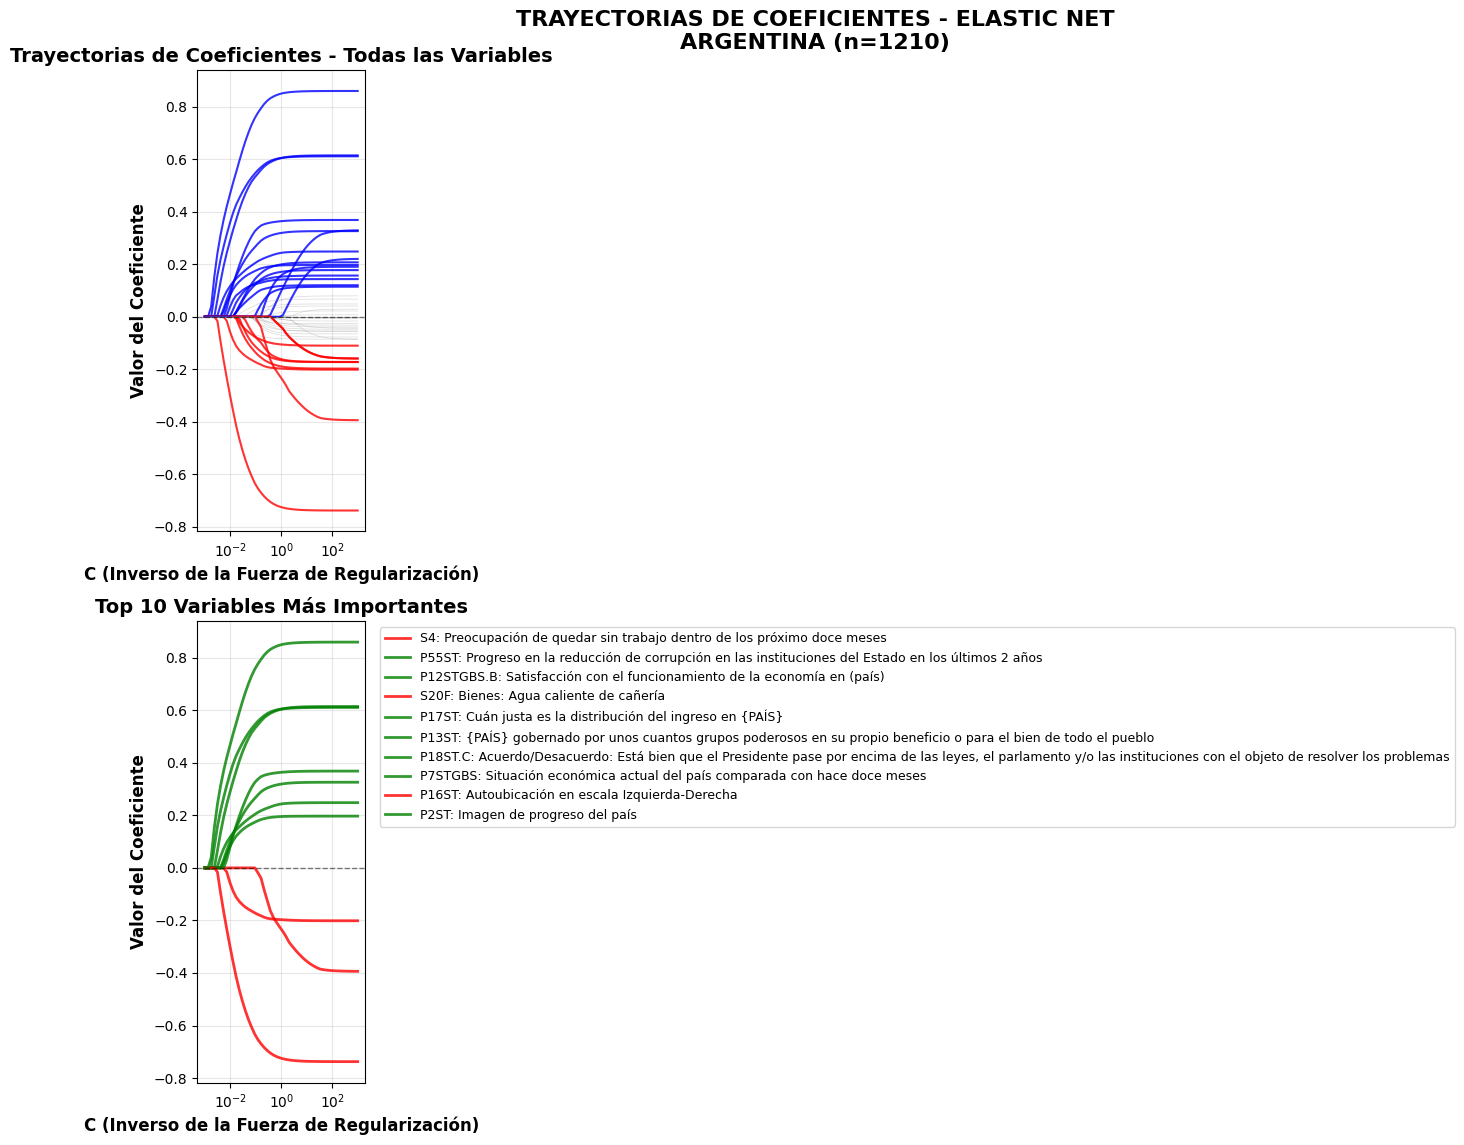


📊 ANÁLISIS DE SELECCIÓN DE VARIABLES - ARGENTINA
   C=0.01: 10 variables no-cero, 5 significativas
   C=0.10: 26 variables no-cero, 15 significativas
   C=1.00: 41 variables no-cero, 21 significativas
   C=10.00: 45 variables no-cero, 25 significativas

🔍 VARIABLES MÁS ESTABLES (seleccionadas consistentemente):
   • P2ST: Imagen de progreso del país             | Efecto: POSITIVO (coef: 0.703)
   • P7STGBS: Situación económica actual del país  | Efecto: POSITIVO (coef: 0.503)
   • P12STGBS.A: Satisfacción con la democracia    | Efecto: POSITIVO (coef: 0.110)
   • P12STGBS.B: Satisfacción con el funcionamient | Efecto: POSITIVO (coef: 0.194)
   • P13ST: {PAÍS} gobernado por unos cuantos grup | Efecto: POSITIVO (coef: 0.280)
   • P16ST: Autoubicación en escala Izquierda-Dere | Efecto: NEGATIVO (coef: -0.577)
   • P17ST: Cuán justa es la distribución del ingr | Efecto: POSITIVO (coef: 0.248)
   • P18ST.C: Acuerdo/Desacuerdo: Está bien que el | Efecto: POSITIVO (coef: 0.489)
   • P55ST: P

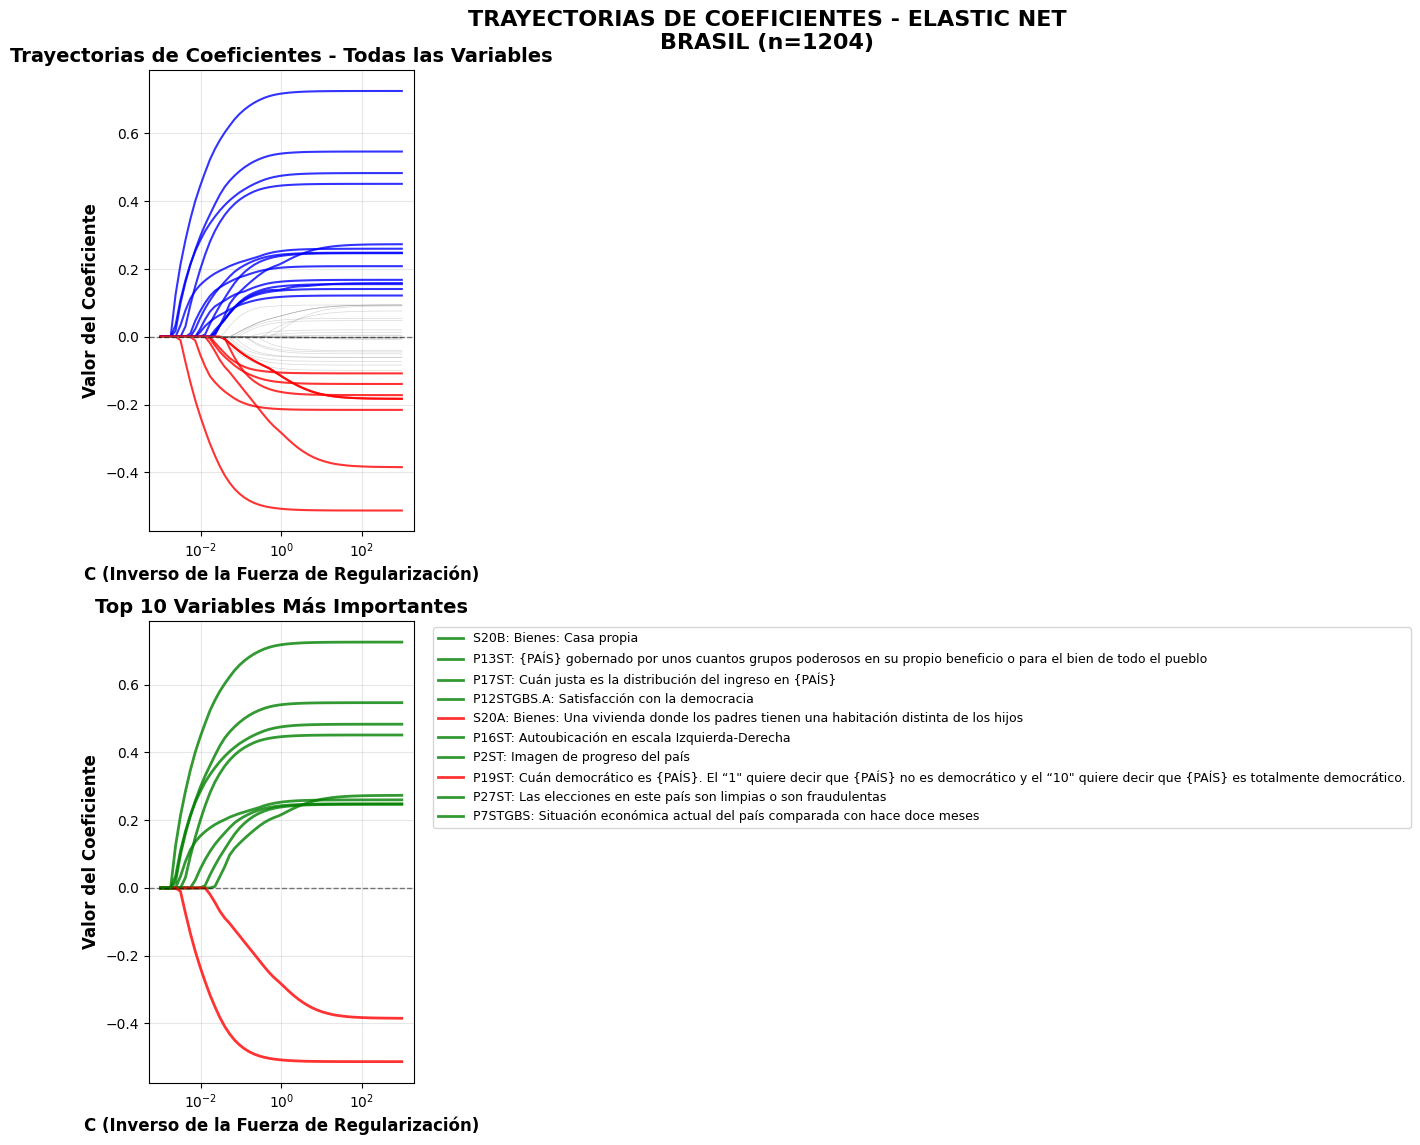


📊 ANÁLISIS DE SELECCIÓN DE VARIABLES - BRASIL
   C=0.01: 11 variables no-cero, 6 significativas
   C=0.10: 33 variables no-cero, 15 significativas
   C=1.00: 42 variables no-cero, 22 significativas
   C=10.00: 45 variables no-cero, 22 significativas

🔍 VARIABLES MÁS ESTABLES (seleccionadas consistentemente):
   • P2ST: Imagen de progreso del país             | Efecto: POSITIVO (coef: 0.396)
   • P7STGBS: Situación económica actual del país  | Efecto: POSITIVO (coef: 0.604)
   • P12STGBS.A: Satisfacción con la democracia    | Efecto: POSITIVO (coef: 0.209)
   • P13ST: {PAÍS} gobernado por unos cuantos grup | Efecto: POSITIVO (coef: 0.174)
   • P16ST: Autoubicación en escala Izquierda-Dere | Efecto: POSITIVO (coef: 0.358)
   • P17ST: Cuán justa es la distribución del ingr | Efecto: POSITIVO (coef: 0.186)
   • P18ST.A: Acuerdo/Desacuerdo: La democracia pu | Efecto: POSITIVO (coef: 0.089)
   • P19ST: Cuán democrático es {PAÍS}. El “1" qui | Efecto: NEGATIVO (coef: -0.409)
   • P27ST: Las 

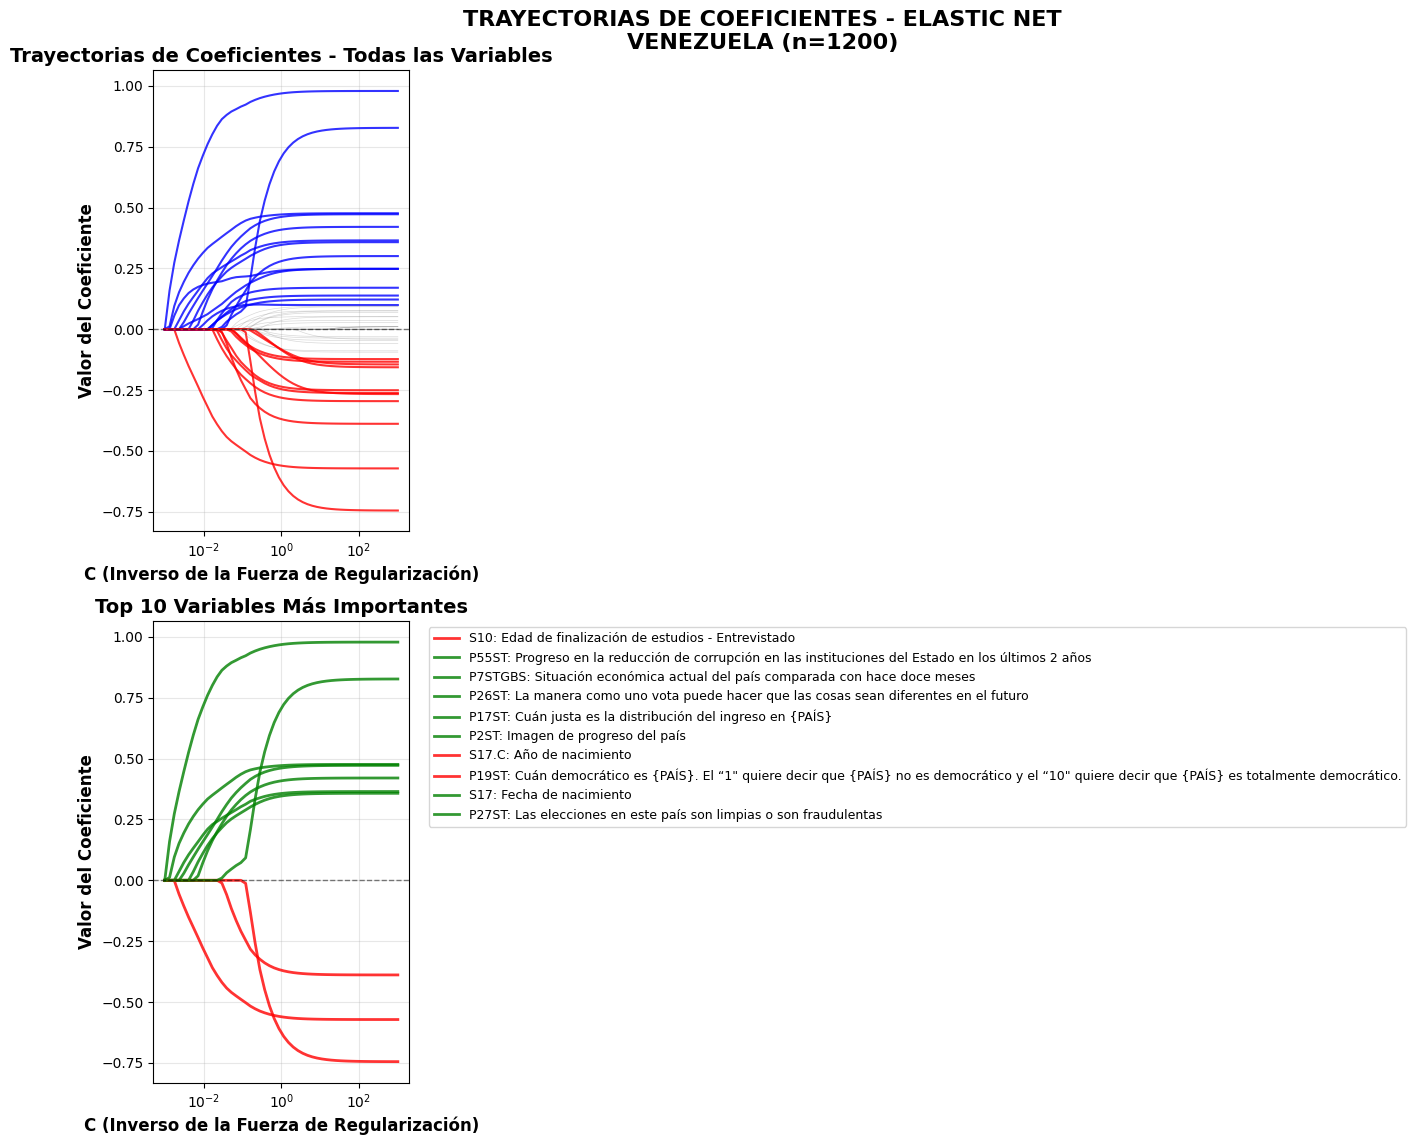


📊 ANÁLISIS DE SELECCIÓN DE VARIABLES - VENEZUELA
   C=0.01: 10 variables no-cero, 7 significativas
   C=0.10: 27 variables no-cero, 16 significativas
   C=1.00: 41 variables no-cero, 22 significativas
   C=10.00: 43 variables no-cero, 24 significativas

🔍 VARIABLES MÁS ESTABLES (seleccionadas consistentemente):
   • P2ST: Imagen de progreso del país             | Efecto: POSITIVO (coef: 0.405)
   • P7STGBS: Situación económica actual del país  | Efecto: POSITIVO (coef: 0.291)
   • P12STGBS.A: Satisfacción con la democracia    | Efecto: POSITIVO (coef: 0.211)
   • P12STGBS.B: Satisfacción con el funcionamient | Efecto: POSITIVO (coef: 0.178)
   • P16ST: Autoubicación en escala Izquierda-Dere | Efecto: POSITIVO (coef: 0.078)
   • P17ST: Cuán justa es la distribución del ingr | Efecto: POSITIVO (coef: 0.361)
   • P19ST: Cuán democrático es {PAÍS}. El “1" qui | Efecto: NEGATIVO (coef: -0.459)
   • P26ST: La manera como uno vota puede hacer qu | Efecto: POSITIVO (coef: 0.311)
   • P27ST: L

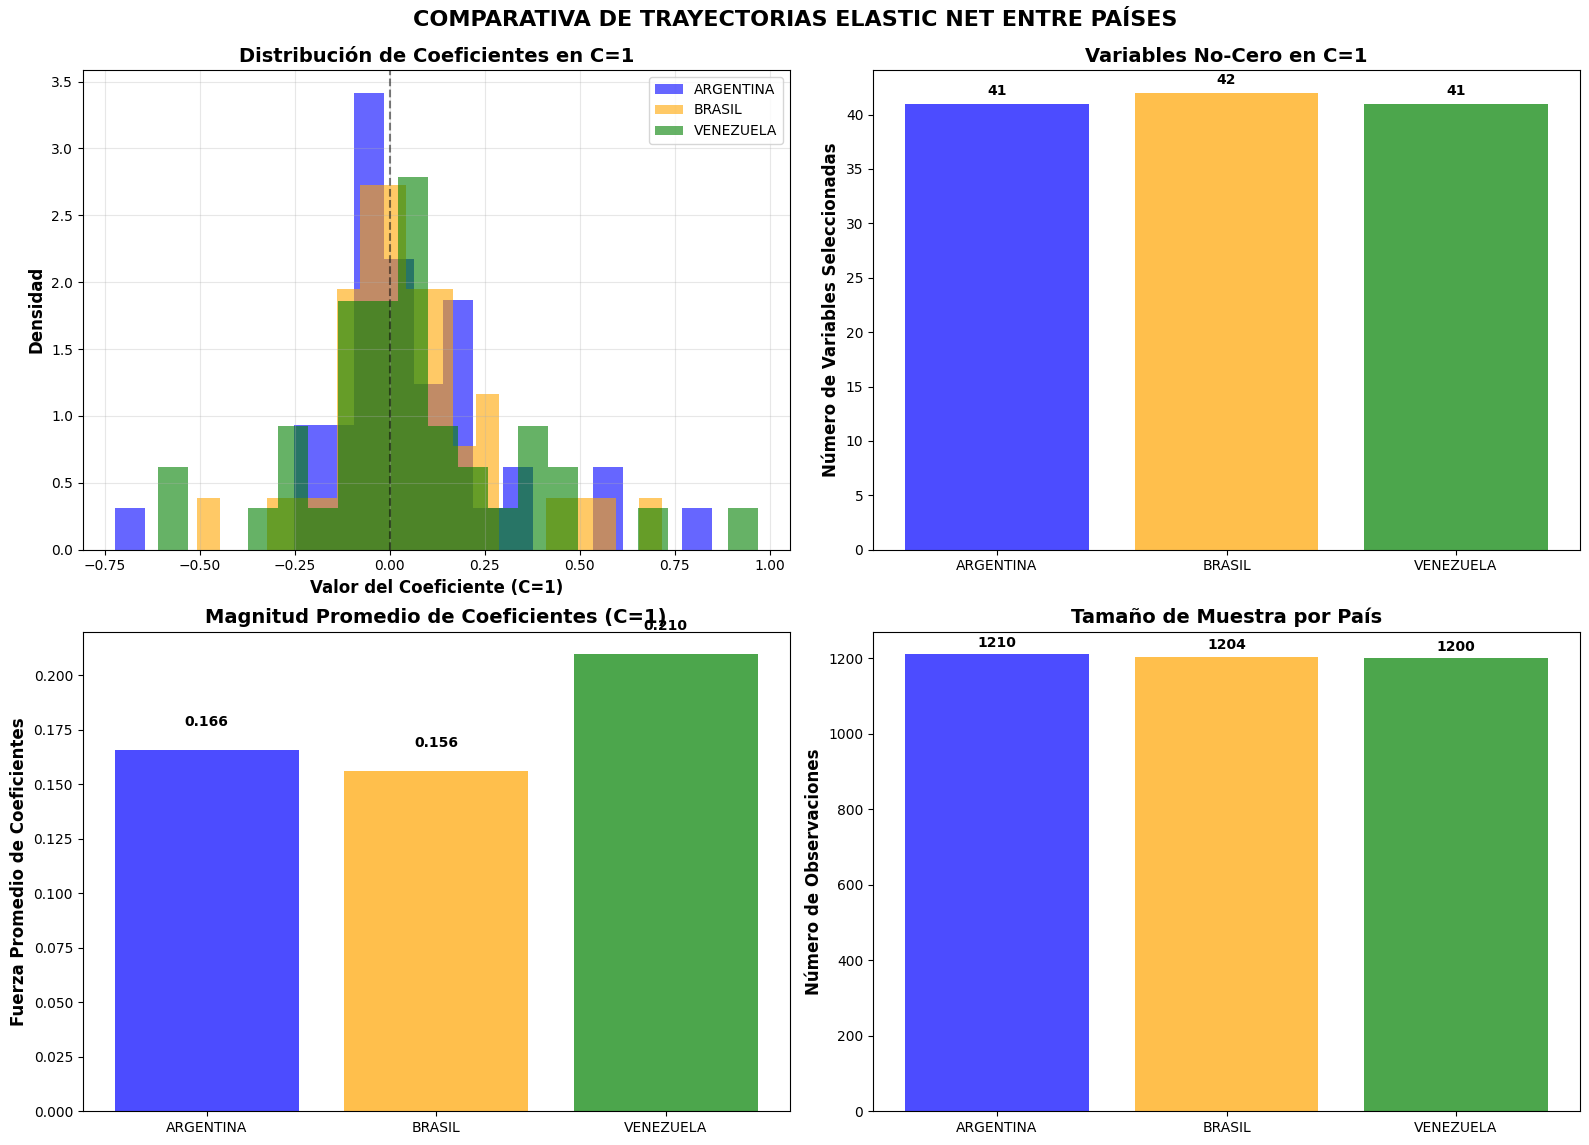


📋 RESUMEN COMPARATIVO DE TRAYECTORIAS:

🇦🇳 ARGENTINA:
   • Observaciones: 1210
   • Variables seleccionadas (C=1): 41
   • Fuerza promedio coeficientes: 0.166
   • Sparsity: 18.0%

🇦🇳 BRASIL:
   • Observaciones: 1204
   • Variables seleccionadas (C=1): 42
   • Fuerza promedio coeficientes: 0.156
   • Sparsity: 16.0%

🇦🇳 VENEZUELA:
   • Observaciones: 1200
   • Variables seleccionadas (C=1): 41
   • Fuerza promedio coeficientes: 0.210
   • Sparsity: 18.0%

✅ Análisis de trayectorias Elastic Net completado!


In [40]:
# =============================================================================
# TRAYECTORIAS ELASTIC NET POR PAÍS - CORREGIDO
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")

# =============================================================================
# 1. CONFIGURACIÓN
# =============================================================================

CODIGOS_PAISES = {
    'ARGENTINA': 32,
    'BRASIL': 76,  
    'VENEZUELA': 862
}

print("=" * 70)
print("TRAYECTORIAS ELASTIC NET POR PAÍS")
print("=" * 70)

# Cargar datos
df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Df_final1.xlsx')

print(f"📊 Dataset original: {df.shape}")

# =============================================================================
# 2. FUNCIÓN PARA TRAYECTORIAS ELASTIC NET
# =============================================================================

def trayectorias_elastic_net_pais(nombre_pais, codigo_pais, df_completo):
    """Función para generar trayectorias de coeficientes Elastic Net por país"""
    
    print(f"\n{'='*70}")
    print(f"🎯 GENERANDO TRAYECTORIAS ELASTIC NET PARA: {nombre_pais.upper()}")
    print(f"{'='*70}")
    
    # Filtrar datos del país - CORREGIDO: usar 'IDENPA: País'
    df_pais = df_completo[df_completo['IDENPA: País'] == codigo_pais].copy()
    
    if len(df_pais) == 0:
        print(f"❌ No hay datos para {nombre_pais}")
        return None
    
    print(f"📊 Datos para {nombre_pais}: {df_pais.shape[0]} observaciones")
    
    # Variable dependiente e independientes
    y_col = 'P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente'
    
    # Verificar que existe la columna
    if y_col not in df_pais.columns:
        print(f"❌ No se encuentra la variable dependiente: {y_col}")
        return None
    
    y = df_pais[y_col]
    
    # Excluir columnas no predictoras
    exclude_cols = [y_col, 'IDENPA: País']
    X = df_pais.drop([col for col in exclude_cols if col in df_pais.columns], axis=1)
    
    print(f"🔍 Variables predictoras: {X.shape[1]}")
    
    # Limpieza básica
    special_codes = [97, 98, 99]
    X_clean = X.replace(special_codes, np.nan)
    y_clean = y.replace(special_codes, np.nan)
    
    # Filtrar filas válidas
    mask = ~y_clean.isna()
    X_filtered = X_clean[mask]
    y_filtered = y_clean[mask]
    
    if len(X_filtered) == 0:
        print(f"❌ No hay datos válidos para {nombre_pais}")
        return None
    
    # Imputar missing values
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_filtered)
    X_imputed = pd.DataFrame(X_imputed, columns=X_filtered.columns, index=X_filtered.index)
    
    # Variable dependiente binaria
    y_binary = y_filtered.astype(int)
    
    print(f"✅ Datos finales: {X_imputed.shape[0]} observaciones")
    print(f"🎯 Distribución: {y_binary.mean()*100:.1f}% aprueba")
    
    if len(X_imputed) < 30:
        print(f"⚠️  Pocos datos para análisis confiable")
        # Continuar pero con advertencia
    
    # =============================================================================
    # PREPARAR DATOS PARA TRAYECTORIAS
    # =============================================================================
    
    # Escalado
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    
    # Rango de valores C (inverso de lambda)
    Cs = np.logspace(-3, 3, 50)  # Menos puntos para mayor velocidad
    
    # Almacenar coeficientes
    coefs = []
    
    print(f"🔄 Calculando trayectorias para {len(Cs)} valores de C...")
    
    for i, C in enumerate(Cs):
        if i % 10 == 0:  # Progress indicator
            print(f"   Procesando C={C:.6f} ({i+1}/{len(Cs)})")
        
        model_en = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=0.5,  # Balance 50-50 entre L1 y L2
            C=C,
            max_iter=1000,
            random_state=42,
            class_weight='balanced'
        )
        
        try:
            model_en.fit(X_scaled, y_binary)
            coefs.append(model_en.coef_.ravel())
        except Exception as e:
            print(f"   Error en C={C:.6f}: {e}")
            # Usar coeficientes zeros en caso de error
            coefs.append(np.zeros(X_imputed.shape[1]))
    
    coefs = np.array(coefs)
    feature_names = X_imputed.columns
    
    print(f"✅ Trayectorias calculadas: {coefs.shape}")
    
    # =============================================================================
    # VISUALIZACIÓN DE TRAYECTORIAS
    # =============================================================================
    
    # Crear figura
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    fig.suptitle(f'TRAYECTORIAS DE COEFICIENTES - ELASTIC NET\n{nombre_pais.upper()} (n={len(X_imputed)})', 
                fontsize=16, fontweight='bold', y=0.95)
    
    # =============================================================================
    # Gráfico 1: TRAYECTORIAS COMPLETAS
    # =============================================================================
    
    threshold = 0.1  # Umbral para mostrar etiquetas
    lines_plotted = 0
    
    for i, name in enumerate(feature_names):
        coef_path = coefs[:, i]
        max_coef = np.max(np.abs(coef_path))
        
        # Solo mostrar variables con coeficientes significativos
        if max_coef > threshold:
            color = 'red' if np.mean(coef_path) < 0 else 'blue'
            ax1.plot(Cs, coef_path, lw=1.5, label=name, color=color, alpha=0.8)
            lines_plotted += 1
        else:
            ax1.plot(Cs, coef_path, color='gray', alpha=0.3, lw=0.5)
    
    ax1.set_xscale('log')
    ax1.set_xlabel('C (Inverso de la Fuerza de Regularización)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Valor del Coeficiente', fontsize=12, fontweight='bold')
    ax1.set_title('Trayectorias de Coeficientes - Todas las Variables', fontsize=14, fontweight='bold')
    ax1.axhline(0, color='black', linestyle='--', lw=1, alpha=0.5)
    ax1.grid(True, alpha=0.3)
    
    # Leyenda solo si no hay demasiadas líneas
    if lines_plotted <= 15:
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # =============================================================================
    # Gráfico 2: VARIABLES MÁS IMPORTANTES (TOP 10)
    # =============================================================================
    
    # Calcular importancia promedio
    importance = np.mean(np.abs(coefs), axis=0)
    top_indices = np.argsort(importance)[-10:]  # Top 10 más importantes
    
    colors_top = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for idx, color in zip(top_indices, colors_top):
        coef_path = coefs[:, idx]
        var_name = feature_names[idx]
        
        # Determinar color basado en efecto promedio
        mean_effect = np.mean(coef_path)
        line_color = 'red' if mean_effect < 0 else 'green'
        line_style = '-' if abs(mean_effect) > 0.05 else '--'
        
        ax2.plot(Cs, coef_path, lw=2, label=var_name, 
                color=line_color, linestyle=line_style, alpha=0.8)
    
    ax2.set_xscale('log')
    ax2.set_xlabel('C (Inverso de la Fuerza de Regularización)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Valor del Coeficiente', fontsize=12, fontweight='bold')
    ax2.set_title('Top 10 Variables Más Importantes', fontsize=14, fontweight='bold')
    ax2.axhline(0, color='black', linestyle='--', lw=1, alpha=0.5)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()
    
    # =============================================================================
    # ANÁLISIS DE SELECCIÓN DE VARIABLES
    # =============================================================================
    
    print(f"\n📊 ANÁLISIS DE SELECCIÓN DE VARIABLES - {nombre_pais.upper()}")
    
    # Analizar en diferentes niveles de regularización
    c_levels = [0.01, 0.1, 1.0, 10.0]
    
    for c_val in c_levels:
        # Encontrar el índice más cercano
        idx = np.argmin(np.abs(Cs - c_val))
        coefs_at_c = coefs[idx, :]
        
        # Variables no cero
        non_zero_vars = np.sum(coefs_at_c != 0)
        significant_vars = np.sum(np.abs(coefs_at_c) > 0.1)
        
        print(f"   C={c_val:.2f}: {non_zero_vars} variables no-cero, {significant_vars} significativas")
    
    # Variables más estables (siempre presentes)
    stability = np.mean(coefs != 0, axis=0)
    stable_vars = stability > 0.8  # Presentes en >80% de los modelos
    
    print(f"\n🔍 VARIABLES MÁS ESTABLES (seleccionadas consistentemente):")
    stable_indices = np.where(stable_vars)[0]
    for idx in stable_indices[:10]:  # Mostrar top 10
        var_name = feature_names[idx]
        mean_coef = np.mean(coefs[:, idx])
        effect = "NEGATIVO" if mean_coef < 0 else "POSITIVO"
        print(f"   • {var_name[:45]:45} | Efecto: {effect} (coef: {mean_coef:.3f})")
    
    return {
        'nombre_pais': nombre_pais,
        'Cs': Cs,
        'coefs': coefs,
        'feature_names': feature_names,
        'n_observaciones': len(X_imputed)
    }

# =============================================================================
# 3. EJECUTAR ANÁLISIS PARA CADA PAÍS
# =============================================================================

resultados_trayectorias = {}

for nombre_pais, codigo in CODIGOS_PAISES.items():
    print(f"\n{'='*50}")
    print(f"PROCESANDO: {nombre_pais}")
    print(f"{'='*50}")
    
    resultado = trayectorias_elastic_net_pais(nombre_pais, codigo, df)
    if resultado is not None:
        resultados_trayectorias[nombre_pais] = resultado

# =============================================================================
# 4. COMPARATIVA ENTRE PAÍSES
# =============================================================================

if len(resultados_trayectorias) > 1:
    print(f"\n{'='*70}")
    print("📊 COMPARATIVA DE TRAYECTORIAS ENTRE PAÍSES")
    print(f"{'='*70}")
    
    # Crear figura comparativa
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('COMPARATIVA DE TRAYECTORIAS ELASTIC NET ENTRE PAÍSES', 
                fontsize=16, fontweight='bold', y=0.95)
    
    paises = list(resultados_trayectorias.keys())
    colors = ['blue', 'orange', 'green']
    
    # Métrica 1: Número de variables seleccionadas en C=1
    variables_seleccionadas = []
    
    # Métrica 2: Fuerza promedio de coeficientes
    fuerza_coeficientes = []
    
    for i, (pais, datos) in enumerate(resultados_trayectorias.items()):
        # Encontrar C más cercano a 1
        idx = np.argmin(np.abs(datos['Cs'] - 1.0))
        coefs_at_1 = datos['coefs'][idx, :]
        
        # Variables no cero
        non_zero = np.sum(coefs_at_1 != 0)
        variables_seleccionadas.append(non_zero)
        
        # Fuerza promedio (valor absoluto)
        fuerza = np.mean(np.abs(coefs_at_1[coefs_at_1 != 0])) if np.any(coefs_at_1 != 0) else 0
        fuerza_coeficientes.append(fuerza)
        
        # Gráfico de distribución de coeficientes en C=1
        coefs_non_zero = coefs_at_1[coefs_at_1 != 0]
        
        if len(coefs_non_zero) > 0:
            axes[0,0].hist(coefs_non_zero, bins=20, alpha=0.6, color=colors[i], 
                          label=pais, density=True)
    
    axes[0,0].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[0,0].set_xlabel('Valor del Coeficiente (C=1)', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel('Densidad', fontsize=12, fontweight='bold')
    axes[0,0].set_title('Distribución de Coeficientes en C=1', fontsize=14, fontweight='bold')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Gráfico de variables seleccionadas
    bars1 = axes[0,1].bar(paises, variables_seleccionadas, color=colors[:len(paises)], alpha=0.7)
    axes[0,1].set_ylabel('Número de Variables Seleccionadas', fontsize=12, fontweight='bold')
    axes[0,1].set_title('Variables No-Cero en C=1', fontsize=14, fontweight='bold')
    
    # Añadir valores en las barras
    for bar, valor in zip(bars1, variables_seleccionadas):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                      f'{valor}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico de fuerza de coeficientes
    bars2 = axes[1,0].bar(paises, fuerza_coeficientes, color=colors[:len(paises)], alpha=0.7)
    axes[1,0].set_ylabel('Fuerza Promedio de Coeficientes', fontsize=12, fontweight='bold')
    axes[1,0].set_title('Magnitud Promedio de Coeficientes (C=1)', fontsize=14, fontweight='bold')
    
    # Añadir valores en las barras
    for bar, valor in zip(bars2, fuerza_coeficientes):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{valor:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico de observaciones por país
    n_observaciones = [datos['n_observaciones'] for datos in resultados_trayectorias.values()]
    bars3 = axes[1,1].bar(paises, n_observaciones, color=colors[:len(paises)], alpha=0.7)
    axes[1,1].set_ylabel('Número de Observaciones', fontsize=12, fontweight='bold')
    axes[1,1].set_title('Tamaño de Muestra por País', fontsize=14, fontweight='bold')
    
    # Añadir valores en las barras
    for bar, valor in zip(bars3, n_observaciones):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(n_observaciones)*0.01,
                      f'{valor}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()
    
    # =============================================================================
    # RESUMEN COMPARATIVO
    # =============================================================================
    
    print(f"\n📋 RESUMEN COMPARATIVO DE TRAYECTORIAS:")
    for i, (pais, datos) in enumerate(resultados_trayectorias.items()):
        idx = np.argmin(np.abs(datos['Cs'] - 1.0))
        coefs_at_1 = datos['coefs'][idx, :]
        non_zero = np.sum(coefs_at_1 != 0)
        fuerza = np.mean(np.abs(coefs_at_1[coefs_at_1 != 0])) if np.any(coefs_at_1 != 0) else 0
        
        print(f"\n🇦🇳 {pais.upper()}:")
        print(f"   • Observaciones: {datos['n_observaciones']}")
        print(f"   • Variables seleccionadas (C=1): {non_zero}")
        print(f"   • Fuerza promedio coeficientes: {fuerza:.3f}")
        print(f"   • Sparsity: {(1 - non_zero/len(coefs_at_1))*100:.1f}%")

print(f"\n✅ Análisis de trayectorias Elastic Net completado!")